# Análisis Exploratorio de Datos - Accidentes de Tráfico en Madrid

## 1. Introducción

En este notebook se analiza el registro de accidentes de tráfico de la ciudad de Madrid utilizando los datos abiertos publicados por el Ayuntamiento, en el que se incluyen los siniestros de tráfico ocurridos en la ciudad (registrados a lo largo de 2024). El dataset utilizado integra los incidentes consignados por la Policía Municipal en los que ha habido víctimas y/o daños al patrimonio. El objetivo de este EDA es responder a dos preguntas principales:

- ¿En qué franja horaria se producen accidentes con mayor gravedad?
- ¿Qué condiciones concretas pueden influir en una alta lesividad?

Antes de comenzar con las primeras fases del análisis, importamos las librerías que vamos a necesitar y ajustamos el tamaño de los gráficos que mostraremos más adelante:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Me interesa ver cómo funciona y qué puedo hacer con GeoPandas, así que la importo también para usarla más adelante
import geopandas as gpd

plt.rcParams["figure.figsize"] = (16,9)

## 2. Descripción de los datos

Lo primero que vamos a hacer es cargar los datos:

In [2]:
db = pd.read_csv("300228-2-accidentes-trafico-detalle-csv.csv", sep=';')

A continuación examinamos el dataset a nivel general: número de filas y columnas, encabezados, tipos de datos de las columnas, nombres de las columnas,...:

In [3]:
db.shape

(49340, 19)

In [4]:
db.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,Conductor,De 55 a 59 años,Hombre,2.0,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,N,NaN
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,Conductor,De 55 a 59 años,Mujer,14.0,Sin asistencia sanitaria,444913.0,4481427.0,N,NaN
2,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,Conductor,De 25 a 29 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,440123.0,4475170.0,N,NaN
3,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,Conductor,De 35 a 39 años,Hombre,14.0,Sin asistencia sanitaria,440123.0,4475170.0,N,NaN
4,2023S040310,18/02/2024,10:40:00,GTA. RUIZ JIMENEZ / CALL. SAN BERNARDO,3,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,Conductor,De 25 a 29 años,Hombre,NaN,NaN,440137.0,4475721.0,N,NaN


In [5]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49340 entries, 0 to 49339
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_expediente        49340 non-null  object 
 1   fecha                 49340 non-null  object 
 2   hora                  49340 non-null  object 
 3   localizacion          49340 non-null  object 
 4   numero                49340 non-null  object 
 5   cod_distrito          49340 non-null  int64  
 6   distrito              49340 non-null  object 
 7   tipo_accidente        49335 non-null  object 
 8   estado_meteorológico  43424 non-null  object 
 9   tipo_vehiculo         48946 non-null  object 
 10  tipo_persona          49340 non-null  object 
 11  rango_edad            49340 non-null  object 
 12  sexo                  49340 non-null  object 
 13  cod_lesividad         27344 non-null  float64
 14  lesividad             27344 non-null  object 
 15  coordenada_x_utm   

In [6]:
db.columns

Index(['num_expediente', 'fecha', 'hora', 'localizacion', 'numero',
       'cod_distrito', 'distrito', 'tipo_accidente', 'estado_meteorológico',
       'tipo_vehiculo', 'tipo_persona', 'rango_edad', 'sexo', 'cod_lesividad',
       'lesividad', 'coordenada_x_utm', 'coordenada_y_utm', 'positiva_alcohol',
       'positiva_droga'],
      dtype='object')

Observamos que se trata de un dataset con 49340 registros y 19 variables, de las que la mayoría son tipo 'object', tratándose éstas de cadenas de texto. Encontramos entre ellas las columnas de fecha y hora, que tendremos que procesar para que puedan ser de utilidad para el análisis. Las variables numéricas que nos encontramos son tipo 'float' en su mayoría, si bien entre ellas se encuentran las coordenadas UTM del lugar del accidente, que también necesitarán de un procesamiento para su uso posterior. En el caso concreto de 'cod_distrito', aunque aparece como 'int64', se trata de una variable categórica que nos indica las etiquetas de los diferentes distritos del municipio de Madrid, información reiterativa con la de la columna 'distrito'.

Con respecto a los valores faltantes, observamos en esta primera aproximación al dataset que la variable que más valores faltantes o nulos posee es 'positiva_droga', con sólo 203 registros válidos de los 49340 de los que consta el dataset. Según la descripción proporcionada por la Policía Municipal, dicha variable puede ser NULL o 1, pero lo cierto es que los nulos pueden deberse a dos situaciones distintas: a que el test se haya realizado y su resultado haya sido negativo o a que no ha realizado ninguna prueba de drogas, por lo que no podríamos conocer por ejemplo el porcentaje de positivos real o en qué tipo de accidentes o personas se han dado porque no sabemos en cuántas personas se realizó la prueba y salió negativa. 

Por otra parte, a priori también 'cod_lesividad' y 'lesividad' (que, de forma análoga a las variables 'cod_distrito' y 'distrito', parecen contener una información redundante, ya que cada 'cod_lesividad' se corresponde con una categoría de 'lesividad') muestran un número de valores faltantes considerable, aunque en la descripción de los datos del dataset de que disponemos encontramos que el valor faltante se corresponde con la etiqueta 'Sin asistencia sanitaria', por lo que deberemos imputar esos nulos con la etiqueta que consta en la documentación.

Por último, la variable 'estado_meteorológico' también presenta un porcentaje importante de nulos, por lo que no se plantea la eliminación de los mismos ya que supondría una reducción importante de la información disponible para el análisis, sino que realizaremos una imputación que desarrollaremos más adelante.

## 3. Limpieza y preparación de los datos

En primer lugar, vamos a **normalizar los nombres de las variables**, eliminando la tilde de 'estado_meteorológico' y los espacios (si los hubiera):

In [7]:
# Lo que estamos haciendo aquí específicamente es cambiar el nombre de la columna 'estado_meteorológico' a 'estado meteorologico', que me ha parecido la forma más sencilla de hacerlo, porque se trata 
# de una sola columna
db.rename(columns={'estado_meteorológico': 'estado_meteorologico'}, inplace=True)

In [8]:
# Para eliminar posibles espacios de las columnas vamos a utilizar .replace() y una list comprehension para iterar sobre cada elemento de la lista de nombres de columnas, por si hubiera espacios dobles
# o internos. Podríamos usar también strip(), pero esta función sólo eliminaría espacios situados al principio y al final:
db.columns = [col.replace(' ','') for col in db.columns]

Tal y como observamos en el punto anterior, existen algunas variables útiles para el análisis que queremos realizar que requieren de un **preprocesamiento** para poder emplearlas, como es el caso de 'fecha'y 'hora':

In [9]:
# Convertimos los datos de la columa 'fecha' que originalmente son strings a Timestamp para poder operar correctamente con las fechas:
db['fecha'] = pd.to_datetime(db['fecha'], dayfirst=True)
# Ahora hacemos lo mismo con 'hora', pero nos quedamos únicamente con el número de la hora creando la columna 'hora_numero', para poder crear una columna con franjas horarias y responder a una de las 
# preguntas de negocio planteadas:
db['hora_numero'] = pd.to_datetime(db['hora'], format='%H:%M:%S').dt.hour


A continuación vamos a crear una nueva columna 'franja_horaria' aplicando la función asignar_franja_horaria, creada a tal efecto. Esta función contempla 5 franjas horarias: de 7 incluido a 12 (Mañana),
de 12 incluido a 16 (Mediodía), de 16 incluido a 20 (Tarde), de 20 incluido a 23 incluido (Noche) y de 0 a 6 (Madrugada)

In [10]:
def asignar_franja_horaria(hora_numero):
    if 7 <= hora_numero < 12:
        return 'Mañana'
    elif 12 <= hora_numero < 16:
        return 'Mediodía'
    elif 16 <= hora_numero < 20:
        return 'Tarde'
    elif 20 <= hora_numero <= 23:
        return 'Noche'
    else:
        return 'Madrugada' # sería de 0 a 6
db['franja_horaria'] = db['hora_numero'].apply(asignar_franja_horaria)

Vamos a ver que todo haya funcionado correctamente:

In [11]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49340 entries, 0 to 49339
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   num_expediente        49340 non-null  object        
 1   fecha                 49340 non-null  datetime64[ns]
 2   hora                  49340 non-null  object        
 3   localizacion          49340 non-null  object        
 4   numero                49340 non-null  object        
 5   cod_distrito          49340 non-null  int64         
 6   distrito              49340 non-null  object        
 7   tipo_accidente        49335 non-null  object        
 8   estado_meteorologico  43424 non-null  object        
 9   tipo_vehiculo         48946 non-null  object        
 10  tipo_persona          49340 non-null  object        
 11  rango_edad            49340 non-null  object        
 12  sexo                  49340 non-null  object        
 13  cod_lesividad   

In [12]:
db.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorologico,tipo_vehiculo,...,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,hora_numero,franja_horaria
0,2023S040280,2024-01-04,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,...,De 55 a 59 años,Hombre,2.0,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,N,NaN,14,Mediodía
1,2023S040280,2024-01-04,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,...,De 55 a 59 años,Mujer,14.0,Sin asistencia sanitaria,444913.0,4481427.0,N,NaN,14,Mediodía
2,2023S040309,2024-02-15,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,...,De 25 a 29 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,440123.0,4475170.0,N,NaN,14,Mediodía
3,2023S040309,2024-02-15,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,...,De 35 a 39 años,Hombre,14.0,Sin asistencia sanitaria,440123.0,4475170.0,N,NaN,14,Mediodía
4,2023S040310,2024-02-18,10:40:00,GTA. RUIZ JIMENEZ / CALL. SAN BERNARDO,3,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,...,De 25 a 29 años,Hombre,NaN,NaN,440137.0,4475721.0,N,NaN,10,Mañana


En lo que respecta a la localización de los accidentes, disponemos de varias variables que incluyen datos al respecto, que son 'localizacion', 'numero', 'cod_distrito', 'distrito' y las que incluyen las coordenadas UTM de los lugares de los accidentes, 'coordenada_x_utm' y 'coordenada_y_utm'. 

Para el análisis que queremos realizar, al disponer de las coordenadas exactas de los accidentes, a priori parecen innecesarias las variables 'localizacion' y 'numero', si bien 'localizacion' incluye información sobre el tipo de vía (calle, avenida, etc...) en la que se produjeron los accidentes, lo que sí que puede resultar útil. Por ello, para estas variables por un lado vamos a eliminar 'numero' por resultar prescindible y por otro vamos a realizar **feature engineering** creando nueva variable 'tipo_via' que incluya esa información y eliminaremos después la variable original 'localizacion' para simplificar el dataset: 

In [13]:
# Observamos en primer lugar cómo está dispuesto el texto de la columna para poder extraer lo que nos interesa, para lo que vamos a extraer la primera palabra y realizar un conteo en % de las 50 opciones
# más repetidas:
tipos_via = (db['localizacion'].apply(lambda x: x.split()[0]).value_counts(normalize=True)) * 100
print(tipos_via.head(50))

localizacion
CALL.            54.993920
AVDA.            16.617349
AUTOV.           10.672882
PASEO.            6.384272
PLAZA.            3.301581
GTA.              1.951763
CTRA.             1.068099
CMNO.             0.612079
RONDA.            0.437779
CALLE             0.385083
CUSTA.            0.257398
INTER.            0.206729
IDB.              0.174301
M-30              0.172274
AEROP.            0.172274
TRVA.             0.141873
BULEV.            0.131739
AVENIDA           0.093231
METRO.            0.089177
M30               0.087150
PASEO             0.068910
PLAZA             0.060803
PNTE.             0.058776
GLORIETA          0.058776
AVDA              0.054722
AUTOVIA           0.052696
VIA               0.046615
C/                0.046615
POLIG.            0.042562
KM                0.040535
LUGAR.            0.036482
CRA.              0.030401
ESTFE.            0.028375
TUNEL             0.028375
CARRETERA         0.028375
PQUE.             0.026348
INS.           

Estas categorías representan casi el 99 % de las etiquetas de los tipos de vías, así que al quedar un porcentaje ínfimo fuera (que pueden deberse a errores de escritura o accidentes muy raros que no influyen en el análisis final) vamos a cubrir con nuestra función la práctica totalidad de los casos existentes  y los que no estén incluidos los categorizaremos como 'Otros' para evitar que queden valores faltantes y simplificar el análisis:

In [14]:
def asignar_tipo_via(via):
    # Aseguramos que se trate de un string en mayúsculas y sin espacios para que no nos de errores:
    via = str(via).upper().strip()
    
    if via.startswith(('AUTOV', 'M-30', 'M30', 'CTRA', 'M-607', 'A2', 'M23', 'INCORPORACIÓN', 'CRA', 'KM', 'CARRETERA', 'AUTOVIA')):
        return 'Vías rápidas o carreteras'

    elif via.startswith(('AVDA', 'AVENIDA', 'PASEO', 'BULEV', 'AVD', 'AV', 'RONDA')):
        return 'Vías de gran tamaño'
    
    elif via.startswith(('PLAZA', 'GTA', 'GLORIETA', 'PZA')):
        return 'Plazas o glorietas'

    elif via.startswith(('CALL', 'C/', 'TRVA', 'CMNO', 'CAMINO', 'VIA', 'LUGAR', 'CUSTA', 'POLIG', 'ARIZA')):
        return 'Vías de pequeño tamaño'

    elif via.startswith(('PARKING', 'TUNEL', 'METRO', 'IDB', 'ESTCE', 'ESTFE', 'AEROP', 'FUENT', 'CDAD', 'INTER', 'PNTE', 'PQUE', 'INS')):
        return 'Instalaciones o infraestructuras'
    
    else:
        return 'Otros'

db['tipo_via'] = db['localizacion'].apply(asignar_tipo_via)

Eliminamos ahora las columnas 'localizacion', de la que ya hemos extraído la información que nos parecía relevante, y 'numero':

In [15]:
db.drop(labels=['localizacion', 'numero'], axis=1, inplace=True)

Continuando con las variables relacionadas con la ubicación geográfica de los accidentes, en el punto 2 de Descripción de los datos, vimos que existían 49334 valores no nulos (es decir, 6 valores nulos) para las columnas de coordenadas x e y, por lo que vamos a eliminar esos 6 registros que contienen nulos para terminar con la limpieza de las variables relacionadas con la localización de los siniestros:

In [16]:
db = db.dropna(subset=['coordenada_x_utm', 'coordenada_y_utm'])

Como **paso final en la limpieza de datos**, vamos a preparar las variables relacionadas con la lesividad, variable objetivo de este EDA. En el dataset encontramos 'cod_lesividad' y 'lesividad', cuya información es redundante ya que la columna 'lesividad' incluye un string con la descripción del código incluido en 'cod_lesividad', estando dichas equivalencias ya descritas en el documento explicativo del dataset, por lo que la eliminaremos. Los distintos valores de 'cod_lesividad' son: 

- 01 Atención en urgencias sin posterior ingreso. - LEVE
- 02 Ingreso inferior o igual a 24 horas - LEVE
- 03 Ingreso superior a 24 horas. - GRAVE
- 04 Fallecido 24 horas - FALLECIDO
- 05 Asistencia sanitaria ambulatoria con posterioridad - LEVE
- 06 Asistencia sanitaria inmediata en centro de salud o mutua - LEVE
- 07 Asistencia sanitaria sólo en el lugar del accidente - LEVE
- 14 Sin asistencia sanitaria
- 77 Se desconoce
- En blanco Sin asistencia sanitaria

Teniendo en esto en cuenta, lo primero que vamos a hacer, tal y como observamos en la descripción inicial de los datos, es imputar la categoría 'Sin asistencia sanitaria' a los valores faltantes, ya que no se trata de nulos reales, es decir, los codificaremos también con el valor '14'. 

In [17]:
# La columna 'cod_lesividad' contiene valores tipo float64, por lo que rellenamos con un valor numérico, no un string:
db['cod_lesividad'] = db['cod_lesividad'].fillna(14)

Para la categorización de los códigos en los diferentes niveles de lesividad, debemos determinar el manejo del código '77', correspondiente a lesividad desconocida. Para tomar una decisión vamos a ver en primer lugar de cuántos registros estamos hablando:

In [18]:
db['cod_lesividad'].value_counts()

cod_lesividad
14.0    38108
7.0      5787
2.0      1865
1.0      1337
6.0      1116
3.0       568
5.0       522
4.0        29
77.0        2
Name: count, dtype: int64

Después de la imputación del código 14 (Sin asistencia sanitaria) a los valores faltantes, nos encontramos con que dicho código se corresponde con el grueso del dataset, lo que significa que la gran mayoría de los accidentes en Madrid en ese periodo de tiempo no requieron de asistencia sanitaria inmediata. Por otra parte, observamos también que el código 77 se corresponde únicamente con 2 registros, por lo que es absolutamente irrelevante para el análisis. Teniendo esto en cuenta, vamos a clasificar cada registro de implicado según su 'cod_lesividad' en tres niveles jerarquizados de menor a mayor lesividad, para crear la variable 'nivel_lesividad', una variable categórica ordinal:

- Nivel 0: 14 y 77 (porque al aparecer de forma tan insignificante en el dataset y no afectar al análisis lo incluimos en la categoría más frecuente) --> Sin asistencia/Desconocido.
- Nivel 1: 1, 2, 5, 6, y 7 --> Leve.
- Nivel 2: 3 y 4 --> Grave/Fallecido (la categoría que nos interesa para nuestro análisis).

In [19]:
# Para crear la columna 'nivel_lesividad' vamos a utilizar map() para asignar manualmente el nivel de lesividad deseado a cada código. Para ello creamos primero un diccionario con las equivalencias
# especificadas anteriormente:
dict_niveles = {
    14: 0, 77: 0, # Sin asistencia/Desconocido
    1: 1, 2: 1, 5: 1, 6: 1, 7: 1, # Leve
    3: 2, 4: 2 # Grave/Fallecido
}

# Como la variable 'cod_lesividad' es de tipo float, forzamos ahora su conversión a entero para evitar errores en el mapeo que vamos a realizar posteriormente:
db['cod_lesividad'] = db['cod_lesividad'].astype(int)

# A continuación creamos la nueva columna 'nivel_lesividad' con map():
db['nivel_lesividad'] = db['cod_lesividad'].map(dict_niveles)

Comprobamos ahora que el mapeado se ha realizado correctamente y no han aparecido nulos en la nueva columna:

In [20]:
db['nivel_lesividad'].isnull().sum()

np.int64(0)

Ahora que hemos creado la nueva columna 'nivel_lesividad' vamos a eliminar 'cod_lesividad' y 'lesividad':

In [21]:
db.drop(labels=['cod_lesividad', 'lesividad'], axis=1, inplace=True)

In [22]:
db.head()

,num_expediente,fecha,hora,cod_distrito,distrito,tipo_accidente,estado_meteorologico,tipo_vehiculo,tipo_persona,rango_edad,sexo,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,hora_numero,franja_horaria,tipo_via,nivel_lesividad
0,2023S040280,2024-01-04,14:09:00,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,Conductor,De 55 a 59 años,Hombre,444913.0,4481427.0,N,NaN,14,Mediodía,Vías de gran tamaño,1
1,2023S040280,2024-01-04,14:09:00,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,Conductor,De 55 a 59 años,Mujer,444913.0,4481427.0,N,NaN,14,Mediodía,Vías de gran tamaño,0
2,2023S040309,2024-02-15,14:05:00,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,Conductor,De 25 a 29 años,Hombre,440123.0,4475170.0,N,NaN,14,Mediodía,Vías de pequeño tamaño,1
3,2023S040309,2024-02-15,14:05:00,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,Conductor,De 35 a 39 años,Hombre,440123.0,4475170.0,N,NaN,14,Mediodía,Vías de pequeño tamaño,0
4,2023S040310,2024-02-18,10:40:00,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,Conductor,De 25 a 29 años,Hombre,440137.0,4475721.0,N,NaN,10,Mañana,Plazas o glorietas,0


A continuación vamos a centrarlos en el **manejo de los valores nulos** que todavía persisten en el dataset, para lo que vamos a ver los nulos existente por columnas:

In [23]:
db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
cod_distrito                0
distrito                    0
tipo_accidente              4
estado_meteorologico     5913
tipo_vehiculo             393
tipo_persona                0
rango_edad                  0
sexo                        0
coordenada_x_utm            0
coordenada_y_utm            0
positiva_alcohol          167
positiva_droga          49131
hora_numero                 0
franja_horaria              0
tipo_via                    0
nivel_lesividad             0
dtype: int64

Por orden de menos numerosos a más numerosos, vemos que tenemos nulos en 'tipo_accidente', 'positiva_alcohol', 'tipo_vehiculo', 'estado_meteorológico' y 'positiva_droga'. Para decidir qué tipo de acción realizamos sobre cada uno de ellos, vamos a ver el porcentaje exacto que suponen dentro del total del dataset: 

In [24]:
(db.isnull().sum() / len(db)) * 100

num_expediente           0.000000
fecha                    0.000000
hora                     0.000000
cod_distrito             0.000000
distrito                 0.000000
tipo_accidente           0.008108
estado_meteorologico    11.985649
tipo_vehiculo            0.796611
tipo_persona             0.000000
rango_edad               0.000000
sexo                     0.000000
coordenada_x_utm         0.000000
coordenada_y_utm         0.000000
positiva_alcohol         0.338509
positiva_droga          99.588519
hora_numero              0.000000
franja_horaria           0.000000
tipo_via                 0.000000
nivel_lesividad          0.000000
dtype: float64

Como se puede observar, el porcentaje de registros con nulos para las variables 'tipo_accidente', 'positiva_alcohol' y 'tipo_vehiculo' es ínfimo en comparación con el tamaño del dataset, no alcanzando el 0.8 % del total de registros en ninguno de los casos, por lo que la opción más razonable para estas tres variables sería la eliminación de aquellos registros que contienen nulos para dichas columnas, ya que al tratarse de una pérdida de datos tan pequeña no alteraríamos la representatividad de la muestra y por otro lado garantizamos que trabajamos con información real para estas variables:

In [25]:
db = db.dropna(subset=['tipo_accidente', 'positiva_alcohol', 'tipo_vehiculo'])

En el caso de 'estado_meteorologico' nos encontramos con una situación distinta, ya que el número de valores nulos de esta variable supone casi un 12 % del total de registros del dataset, por lo que su eliminación directa supondría la pérdida de una parte importante de los datos. Por ello, en este caso vamos a realizar una imputación sobre los datos faltantes con un valor razonable, para lo que en primer lugar vamos a analizar cómo se distribuyen los valores en la columna 'estado_meteorologico' por porcentajes:

In [26]:
db['estado_meteorologico'].value_counts(normalize=True) * 100

estado_meteorologico
Despejado         84.647969
Nublado            7.964622
Lluvia débil       5.483533
LLuvia intensa     1.065984
Se desconoce       0.814617
Granizando         0.018620
Nevando            0.004655
Name: proportion, dtype: float64

Observamos que el valor más frecuente del dataset completo para 'estado_meteorologico', es, con un 84,65 %, 'Despejado'. Por otra parte, tenemos un porcentaje bastante pequeño (0.81 %) de datos desconocidos. Al disponer de gran cantidad de datos con fechas y horas (extraídas al principio del proceso de limpieza de datos para poder operar con ellas), podemos realizar una imputación altamente eficiente utilizando la moda (valor más frecuente) de 'estado_meteorologico' para fechas y horas concretas en las que tenemos los valores nulos. Además, vamos a imputar también con esta moda los valores etiquetados como 'Se desconoce', que a efectos del análisis son equivalentes a un nulo, por lo que para tratarlos como tal, los vamos a convertir en NaN:

In [27]:
# Convertimos 'Se desconoce' a NaN para imputarlos también por la moda:
db['estado_meteorologico'] = db['estado_meteorologico'].replace('Se desconoce', np.nan)

# Calculamos la moda agrupando con groupby por las columnas de fecha y hora_numero y utilizamos transform() para repartir esa moda calculada de para esa fecha y hora a todos los registros que coincidan,
# utilizando una función lambda donde si existen datos para ese día y hora y se puede calcular la moda, se imputa esa moda y si no devuelve un nulo: 
moda_fecha_hora = db.groupby(['fecha', 'hora_numero'])['estado_meteorologico'].transform(lambda x: x.mode()[0] if x.mode().any() else np.nan)

# Imputamos los nulos con la moda encontrada con fillna()
db['estado_meteorologico'] = db['estado_meteorologico'].fillna(moda_fecha_hora)

nulos_restantes = db['estado_meteorologico'].isnull().sum()
print(f"Después de imputar con la moda por fecha y hora, todavía quedan {nulos_restantes} nulos por rellenar.")

Después de imputar con la moda por fecha y hora, todavía quedan 684 nulos por rellenar.


Vemos que después de la primera imputación, persisten 684 valores nulos sin moda coincidente en fecha y hora exacta. Para completar el proceso, vamos a aplicar una segunda imputación basada en la moda de la misma fecha y franja horaria, que, aunque conlleva una menor precisión que la anterior, sigue garantizando un margen de error aceptable.

In [28]:
moda_fecha_franja = db.groupby(['fecha', 'franja_horaria'])['estado_meteorologico'].transform(lambda x: x.mode()[0] if x.mode().any() else np.nan)
db['estado_meteorologico'] = db['estado_meteorologico'].fillna(moda_fecha_franja)

nulos_restantes_dos = db['estado_meteorologico'].isnull().sum()
print(f"Después de imputar con la moda por fecha y franja horaria, quedan {nulos_restantes_dos} nulos por rellenar.")

Después de imputar con la moda por fecha y franja horaria, quedan 6 nulos por rellenar.


Finalmente, para imputar los 6 nulos que quedan por rellenar, vamos a hacerlo con el dato que hemos detectado anteriormente que es la moda de 'estado_meteorologico' de todo el dataset, 'Despejado': 

In [29]:
db['estado_meteorologico'] = db['estado_meteorologico'].fillna('Despejado')

In [30]:
db.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48817 entries, 0 to 49339
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   num_expediente        48817 non-null  object        
 1   fecha                 48817 non-null  datetime64[ns]
 2   hora                  48817 non-null  object        
 3   cod_distrito          48817 non-null  int64         
 4   distrito              48817 non-null  object        
 5   tipo_accidente        48817 non-null  object        
 6   estado_meteorologico  48817 non-null  object        
 7   tipo_vehiculo         48817 non-null  object        
 8   tipo_persona          48817 non-null  object        
 9   rango_edad            48817 non-null  object        
 10  sexo                  48817 non-null  object        
 11  coordenada_x_utm      48817 non-null  float64       
 12  coordenada_y_utm      48817 non-null  float64       
 13  positiva_alcohol     

Para completar el proceso de limpieza y preparación de los datos, vamos a abordar el tratamiento de los valores nulos restantes del dataset, únicamente presentes ya en la columna 'positiva_droga':

In [31]:
(db.isnull().sum() / len(db)) * 100

num_expediente           0.00000
fecha                    0.00000
hora                     0.00000
cod_distrito             0.00000
distrito                 0.00000
tipo_accidente           0.00000
estado_meteorologico     0.00000
tipo_vehiculo            0.00000
tipo_persona             0.00000
rango_edad               0.00000
sexo                     0.00000
coordenada_x_utm         0.00000
coordenada_y_utm         0.00000
positiva_alcohol         0.00000
positiva_droga          99.58621
hora_numero              0.00000
franja_horaria           0.00000
tipo_via                 0.00000
nivel_lesividad          0.00000
dtype: float64

Tal y como se muestra más arriba, los valores faltantes en la variable 'positiva_droga' suponen un 99,58 % del total de registros del dataset. Según lo expuesto ya en la fase de descripción inicial de los datos, esta variable solo adopta los valores NULL o 1, pero estos nulos pueden deberse a dos motivos imposibles de distinguir: a un resultado negativo de un test realizado o a la no realización de la prueba correspondiente. Esto significa que la variable no tiene un valor real para el análisis, ya que no se conoce el número de test realizados y en cuáles de ellos el resultado fue negativo. 

Por estos motivos, vamos a eliminar la columna 'positiva_droga', al no ofrecer información útil y en cantidad suficiente para efectuar cualquier tipo de análisis, por los motivos ya mencionados:

In [32]:
db.drop(labels=['positiva_droga'], axis=1, inplace=True)

## 4. Análisis Univariante

En el caso del dataset objeto de análisis, la gran mayoría de variables de las que disponemos, así como las creadas durante el proceso de limpieza y preparación de los datos son de tipo categóricas. Algunas de ellas tienen un orden interno claro, por lo que se trataría de variables categóricas ordinales cuya jerarquización es una característica a tener muy en cuenta a la hora de su tratamiento y representación gráfica. A continuación vamos a realizar un conteo de valores en algunas de las que nos parecen más interesantes para nuestro análisis para ver qué etiquetas contienen y en qué cantidad. Para ello, tenemos que tener en cuenta la estructura del dataset: existe un registro por cada persona implicada en cada accidente, por lo que si realizáramos un conteo y lo graficáramos tal cual está, estaríamos contando y graficando personas y no accidentes, lo que podría generar un sesgo importante, ya que estaríamos analizando personas y no siniestros, por lo que para el análisis del tipo de accidente, los distritos, la meteorología en el momento del accidente, las coordenadas geográficas, etc..., vamos a agrupar los accidentes por 'num_expediente' y así poder analizar cada accidente como un suceso único, con independencia de las personas implicadas en el mismo.

Comenzaremos analizando los tipos de accidentes:

In [33]:
db['tipo_accidente'].value_counts()

tipo_accidente
Colisión fronto-lateral         13178
Alcance                         11981
Colisión lateral                 7932
Choque contra obstáculo fijo     5272
Atropello a persona              2928
Caída                            2651
Colisión múltiple                2507
Colisión frontal                 1078
Otro                              790
Solo salida de la vía             248
Vuelco                            181
Atropello a animal                 71
Name: count, dtype: int64

Al realizar el conteo de esta variable observamos que se registran 12 etiquetas, siendo algunas de ellas agrupables según las definiciones de tipos de accidentes especificadas por la Policía Municipal. Este sería el caso por ejemplo de colisión frontal, colisión fronto-lateral y colisión lateral, que en el documento informativo constan todas bajo la categoría de 'Colisión doble'. Vamos a realizar por tanto un mapeo para agrupar las diferentes etiquetas de 'tipo_accidente' para posteriormente poder realizar gráficos más fáciles de visualizar:

In [34]:
# Creamos el diccionario teniendo en cuenta el documento de la Policía Municipal
tipos_accidentes = {
    'Colisión fronto-lateral': 'Colisión doble',
    'Colisión lateral': 'Colisión doble',
    'Colisión frontal': 'Colisión doble',
    'Alcance': 'Alcance',
    'Choque contra obstáculo fijo': 'Choque',
    'Atropello a persona': 'Atropello a persona',
    'Caída': 'Caída',
    'Colisión múltiple': 'Colisión múltiple',
    'Otro': 'Otras causas',
    'Solo salida de la vía': 'Otras causas',
    'Vuelco': 'Vuelco',
    'Atropello a animal': 'Otras causas'
}

# Aplicamos los cambios con la función map()
db['tipo_accidente'] = db['tipo_accidente'].map(tipos_accidentes)

Para analizar y visualizar los datos de las variables que tienen que ver con cada accidente como suceso único e individual, como es el caso de 'tipo_accidente', vamos a realizar una agrupación por 'num_expediente' de las mismas, esto es, 'distrito', 'tipo_accidente', 'estado_meteorologico', 'franja_horaria', 'tipo_via', 'coordenada_x_utm', 'coordenada_y_utm', 'fecha' y 'hora_numero'. Añadiremos también 'nivel_lesividad', ya que si bien se trata de una variable relacionada con las personas implicadas en cada accidente y por tanto pueden coexistir varios niveles de lesividad dentro de un mismo siniestro, se trata de una variable de especial interés en nuestro análisis, por lo que para su agrupación escogeremos su valor máximo para cada num_expediente:

In [35]:
# Realizamos la agrupación detallada anteriormente con groupby(), y la función .agg() que especifica con qué dato de cada columna tiene que quedarse. En este caso, para 
# 'tipo_accidente', 'distrito', 'estado_meteorologico', 'franja_horaria', 'tipo_via', 'coordenada_x_utm', 'coordenada_y_utm', 'fecha' y 'hora_numero' nos quedamos con el primer 
# valor que aparezca. Sin embargo, para 'nivel_lesividad' nos quedamos con su valor máximo, ya que cada accidente tendrá la gravedad de su herido más grave. Con .reset_index() 
# reseteamos para que no exista índice en el DataFrame creado, ya que con groupby() 'num_expediente' se ha convertido en el índice y para graficar es mejor que todas las variables
# sean columnas normales.
db_accidentes = db.groupby('num_expediente').agg({'tipo_accidente': 'first', 'distrito': 'first', 'estado_meteorologico': 'first', 'franja_horaria': 'first', 'tipo_via': 'first',
                                                  'coordenada_x_utm': 'first', 'coordenada_y_utm': 'first', 'fecha': 'first', 'hora_numero': 'first', 'nivel_lesividad': 'max'}).reset_index()

In [36]:
db_accidentes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20622 entries, 0 to 20621
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   num_expediente        20622 non-null  object        
 1   tipo_accidente        20622 non-null  object        
 2   distrito              20622 non-null  object        
 3   estado_meteorologico  20622 non-null  object        
 4   franja_horaria        20622 non-null  object        
 5   tipo_via              20622 non-null  object        
 6   coordenada_x_utm      20622 non-null  float64       
 7   coordenada_y_utm      20622 non-null  float64       
 8   fecha                 20622 non-null  datetime64[ns]
 9   hora_numero           20622 non-null  int32         
 10  nivel_lesividad       20622 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(6)
memory usage: 1.7+ MB


De los 48817 registros que contiene del dataset original (un registro por persona implicada en un siniestro), hemos pasado a 20622 registros agrupándolos por 'num_expediente', lo que significa que en Madrid hay una media aproximada de 2,37 personas implicadas en cada accidente.

Vamos a graficar ahora los tipos de accidentes ya agrupados con un gráfico de barras horizontales:

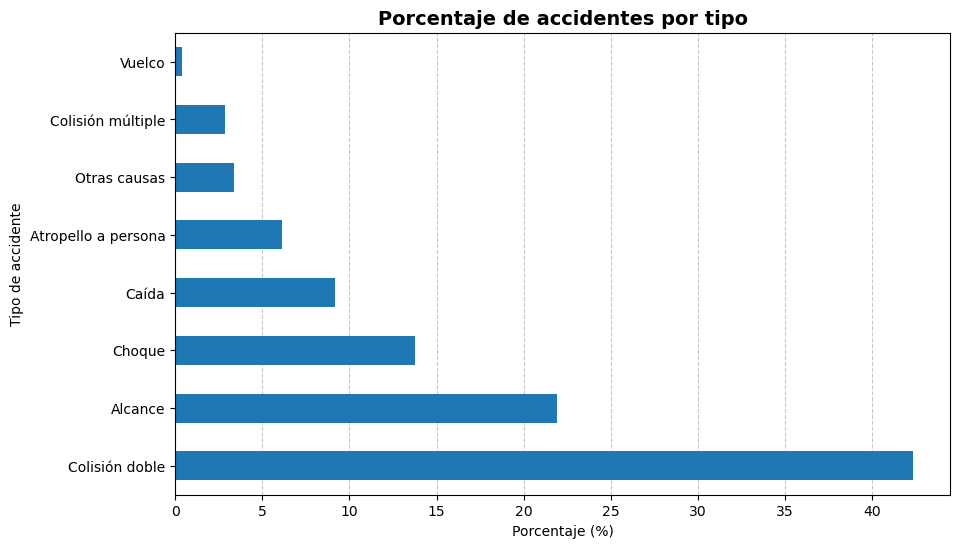

In [37]:
# Multiplicamos por 100 para pasar a tanto por 100 y que el gráfico resultante sea más fácil de leer
(db_accidentes['tipo_accidente'].value_counts(normalize=True) * 100).plot.barh(figsize= (10,6))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Porcentaje de accidentes por tipo', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Tipo de accidente')
plt.show()

Como podemos ver claramente en el gráfico, los **accidentes más frecuentes** son las **colisiones dobles**, es decir, los que se producen entre dos vehículos en movimiento, seguidos de los **alcances** (en los que un vehículo es golpeado por otro por su parte posterior) y los **choques** (accidentes entre un vehículo en movimiento y un objeto inmóvil). Por contra, los vuelcos y las colisiones múltiples son los accidentes que se producen con menor frecuencia.

Continuamos nuestro análisis univariado con la variable 'distrito', veamos primero qué etiquetas contiene:

In [38]:
db_accidentes['distrito'].value_counts()

distrito
PUENTE DE VALLECAS     1524
CHAMARTÍN              1468
CARABANCHEL            1434
SALAMANCA              1392
CENTRO                 1315
CIUDAD LINEAL          1242
FUENCARRAL-EL PARDO    1090
ARGANZUELA             1085
MONCLOA-ARAVACA        1048
TETUÁN                 1010
RETIRO                 1009
LATINA                  961
CHAMBERÍ                952
SAN BLAS-CANILLEJAS     944
USERA                   815
HORTALEZA               765
VILLAVERDE              701
MORATALAZ               573
VILLA DE VALLECAS       515
BARAJAS                 393
VICÁLVARO               386
Name: count, dtype: int64

In [39]:
db_accidentes['distrito'].nunique()

21

Vemos que el dataset contiene valores para los 21 distritos en los que se divide la ciudad de Madrid, lo que significa que todos los distritos están representados en el dataset. Vamos a representarlo gráficamente con otro gráfico de barras horizontales:  

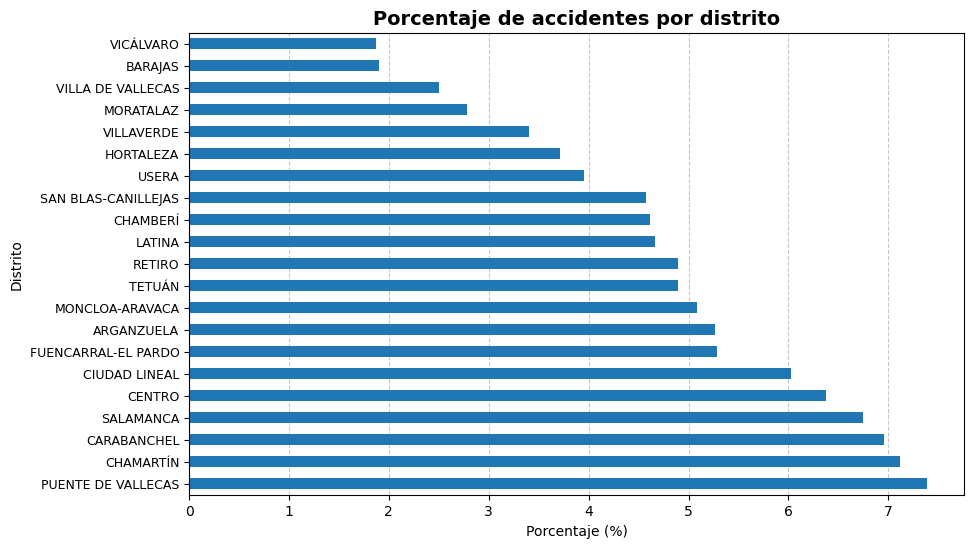

In [40]:
# Multiplicamos por 100 para pasar a tanto por 100 y que el gráfico resultante sea más fácil de leer
(db_accidentes['distrito'].value_counts(normalize=True) * 100).plot.barh(figsize= (10,6))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Porcentaje de accidentes por distrito', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Distrito')
plt.yticks(fontsize=9)
plt.show()

Podemos observar que los cinco **distritos de Madrid** en los que se produce un mayor número de accidentes de tráfico son **Puente de Vallecas, Chamartín, Carabanchel, Salamanca y Centro**, lo que resulta coherente con las características de estas zonas, ya que presentan una alta densidad de población y de tráfico, gran actividad comercial y en el caso concreto del distrito Centro un gran número de peatones y turistas.

En el caso de 'estado_meteorologico', como ya detectamos en la fase de limpieza y preparación de los datos, la etiqueta que más se repite es 'Despejado' y el número de etiquetas existentes es más reducido,  así que en este caso vamos a graficarla mediante un gráfico circular para visualizarlo de manera más efectiva:

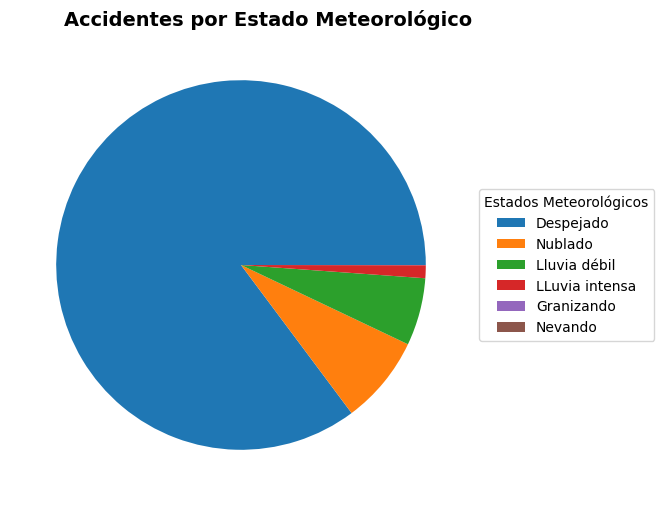

In [41]:
# Al graficarlo con las leyendas en cada parte del gráfico se amontonaban las de categorías menos frecuentes, así que elegimos generar una leyenda fuera del gráfico para que sean más legibles:
datos_met = db_accidentes['estado_meteorologico'].value_counts()
plt.figure(figsize=(10, 6))

colores, textos = plt.pie(datos_met)
plt.legend(colores, datos_met.index, title="Estados Meteorológicos", 
           loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Accidentes por Estado Meteorológico', fontsize=14, fontweight='bold', loc = 'right') 
plt.show()

Como podemos observar en este gráfico, la inmensa **mayoría de los accidentes** se producen en circunstancias de **condiciones meteorológicas favorables**, siendo los siniestros producidos durante fenómenos atmosféricos más adversos (nieve y granizo) absolutamente marginales, si bien esta circunstancia está íntimamente relacionada con las condiciones climáticas predominantes en la ciudad de Madrid. Por tanto, resultaría de mayor interés realizar un análisis bivariado para observar el comportamiento de otras variables (como el nivel de lesividad o el tipo de accidente) dentro de cada estado meteorológico, independientemente de su volumen total.

Para graficar la variable 'franja_horaria', vamos primero a realizar un conteo de valores para ver los porcentajes exactos que nos encontramos y decidir el tipo de gráfico que usamos:

In [42]:
# Habíamos definido 5 franjas horarias: de 7 incluido a 12 (Mañana), de 12 incluido a 16 (Mediodía), de 16 incluido a 20 (Tarde), de 20 incluido a 23 incluido (Noche) y de 0 a 6 (Madrugada)
db_accidentes['franja_horaria'].value_counts()

franja_horaria
Tarde        5184
Mediodía     5070
Mañana       4517
Noche        3505
Madrugada    2346
Name: count, dtype: int64

Como podemos observar, existen muy pocas diferencias entre las diferentes franjas horarias, por lo que vamos a realizar un gráfico de barras verticales para poder distinguir mejor estas diferencias:

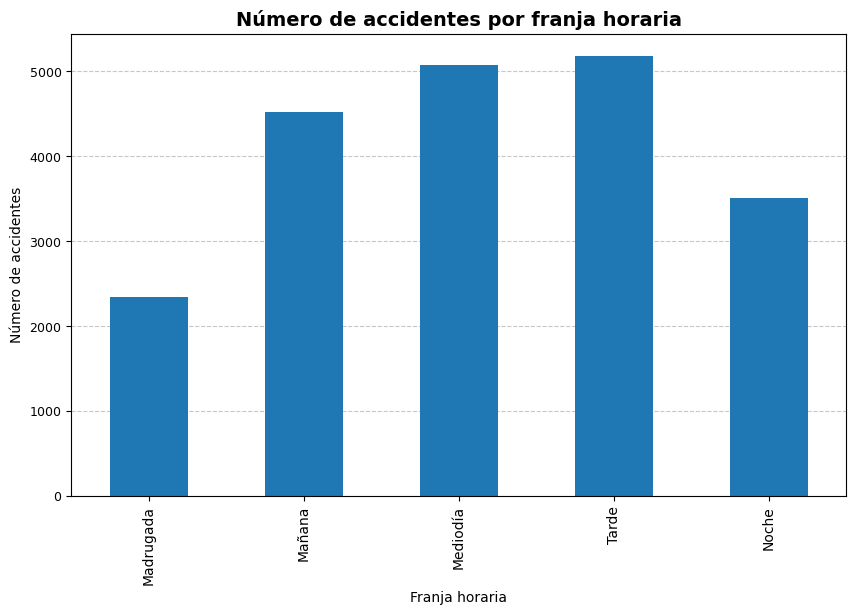

In [43]:
# Vamos a graficar las diferentes franjas horarias en el orden temporal lógico, es decir, Madrugada, Mañana, Mediodía, Tarde y Noche (si no lo hacemos salen de mayor a menor número de accidentes). Para este orden personalizado
# convertimos la columna a tipo Categorical y le asignamos el orden preestablecido en la variable orden_franjas:
orden_franjas = ['Madrugada', 'Mañana', 'Mediodía', 'Tarde', 'Noche']
db_accidentes['franja_horaria'] = pd.Categorical(db_accidentes['franja_horaria'], 
                                                 categories=orden_franjas, 
                                                 ordered=True)
db_accidentes['franja_horaria'].value_counts(sort = False).plot.bar(figsize = (10, 6))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Número de accidentes por franja horaria', fontsize=14, fontweight='bold')
plt.xlabel('Franja horaria')
plt.ylabel('Número de accidentes')
plt.yticks(fontsize=9)
plt.show()

Como se observa en el gráfico, las **franjas horarias** en las que más accidentes se producen son la **tarde**, seguida de **mediodía** y de **mañana**. Estos resultados a priori parecen razonables, ya que es en esas franjas horarias donde se concentra la mayor cantidad de movimientos circulatorios (horas punta). En concreto, por la tarde se produce la salida del trabajo de miles de personas, así como de colegios y otros centros educativos; y, de forma análoga, durante el mediodía y la mañana la salida de nuevo de centros educativos y descansos para comer de los trabajadores y llegada al trabajo, respectivamente.

En relación con la temporalidad de los accidentes, vamos a graficar los accidentes ocurridos por mes mediante un gráfico de líneas (el más adecuado para mostrar evolución temporal porque conecta los puntos en el tiempo y permite ver tendencias, subidas y bajadas de forma más visual), para ver si existen fluctuaciones en el número de accidentes ocurridos a lo largo del año:

Ene    1635
Feb    1653
Mar    1677
Abr    1808
May    1856
Jun    1764
Jul    1624
Ago    1142
Sep    1753
Oct    1965
Nov    1856
Dic    1889
Name: num_expediente, dtype: int64


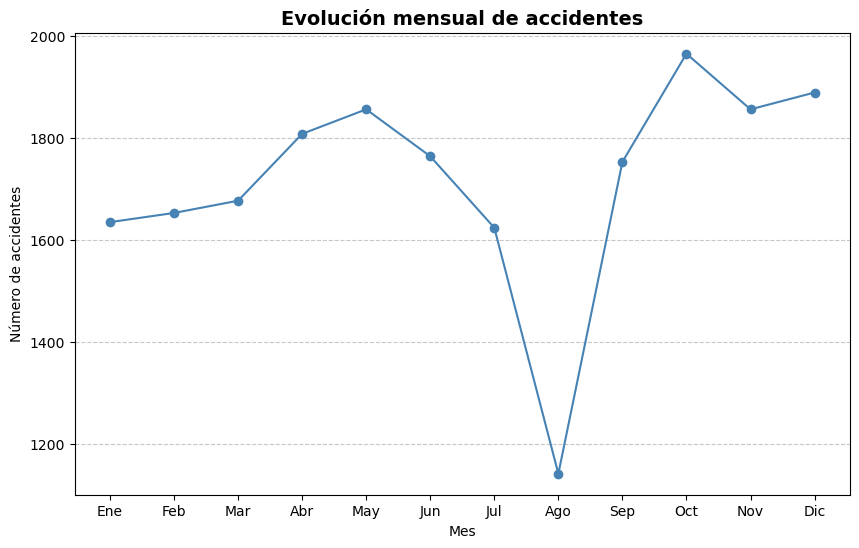

In [44]:
# Como db_accidentes no tiene la columna 'fecha', ya que cuando creamos el DataFrame agrupado por num_expediente no la incluimos en el .agg(), usaremos 'num_expediente' de db con
# nunique() para contar accidentes únicos y no duplicar por persona implicada:
accidentes_por_mes = db.groupby(db['fecha'].dt.month)['num_expediente'].nunique()
accidentes_por_mes.index = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                             'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
print(accidentes_por_mes)

plt.figure(figsize=(10, 6))
plt.plot(accidentes_por_mes.index, accidentes_por_mes.values, marker='o', color='steelblue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Evolución mensual de accidentes', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Número de accidentes')
plt.show()

Como se puede ver claramente en la gráfica, existe un descenso pronunciado del número de accidentes producido coincidiendo con las vacaciones de verano y por tanto menor cantidad de coches circulando, siendo especialmente acusado en agosto, donde se produce el mínimo de accidentes de todo el año (1142), frente al máximo producido en octubre, con 1965 accidentes, si bien no disponemos de datos suficientes para identificar una causa concreta que lo explique.

En el siguiente paso de nuestro análisis univariado, realizaremos un gráfico de barras horizontales para visualizar la variable 'tipo_via' extraída de la variable 'localizacion' durante la fase de limpieza y preparación:

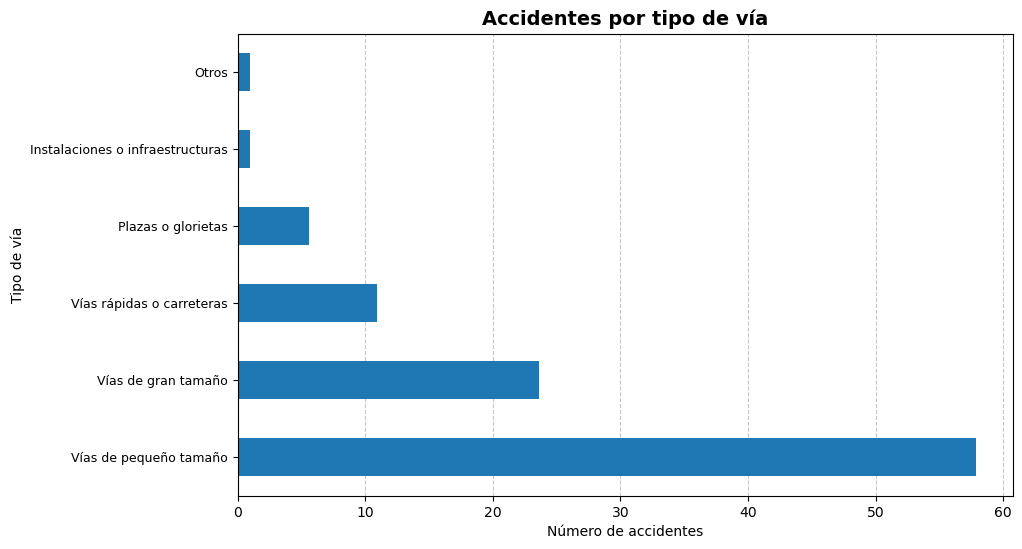

In [45]:
# Normalizamos y multiplicamos por 100 para pasar a tanto por 100 y que el gráfico resultante sea más fácil de leer
(db_accidentes['tipo_via'].value_counts(normalize = True)* 100).plot.barh(figsize= (10,6))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Accidentes por tipo de vía', fontsize=14, fontweight='bold')
plt.xlabel('Número de accidentes')
plt.ylabel('Tipo de vía')
plt.yticks(fontsize=9)
plt.show()

Como se desprende de la gráfica, la **gran mayoría de los accidentes** (aprox. un 57 %) se producen en **vías categorizadas como de pequeño tamaño** (calles, travesías, caminos, etc...), seguidas con algo más de un 20 % por las vías de gran tamaño (avenidas, bulevares, paseos,...). Este es un dato coherente con la distribución habitual de los tipos de vía en una gran ciudad como Madrid, ya que la gran mayoría de vías que la componen son de pequeño/mediano tamaño, por lo que tiene sentido que la mayoría de los accidentes se produzcan en esta clase de calles. Un análisis más interesante a plantear relacionado con estas cuestiones sería el nivel de lesividad o el tipo de accidente según el tipo de vía.

Por último, para cerrar el bloque de análisis univariado de las variables relacionadas con los accidentes producidos y no con cada persona implicada en los mismos, vamos a visualizar el nivel de lesividad por accidente producido, lo que dará una idea de la gravedad de cada siniestro producido. A la hora de agrupar los accidentes por num_expediente establecimos que para la columna 'nivel_lesividad' se guardara el nivel más alto recogido para todas las personas implicadas en el accidente. En este caso realizaremos la visualización mediante un gráfico de barras vertical: 

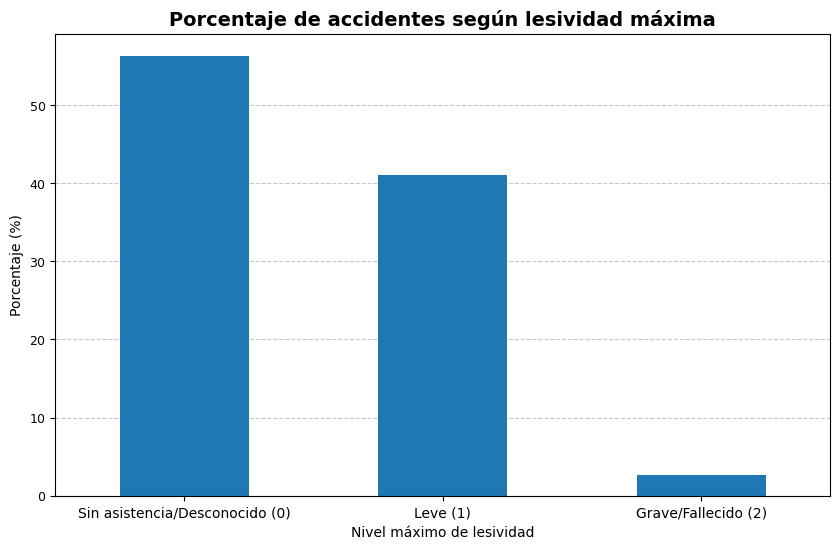

In [46]:
(db_accidentes['nivel_lesividad'].value_counts(normalize=True) * 100).plot.bar(figsize = (10, 6))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Porcentaje de accidentes según lesividad máxima', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1, 2], labels=['Sin asistencia/Desconocido (0)', 'Leve (1)', 'Grave/Fallecido (2)'], rotation = 0)
plt.xlabel('Nivel máximo de lesividad')
plt.ylabel('Porcentaje (%)')
plt.yticks(fontsize=9)
plt.show()

Vemos claramente en este gráfico que en la **mayor parte de los accidentes** (aprox. un 56 %) **ninguno de los implicados en los accidentes requirió de asistencia sanitaria** (el nivel de lesividad máxima registrada fue de 0), y sólo algo más del 2 % de los accidentes tuvieron como resultado algún fallecido o herido grave.

A continuación vamos a proseguir con el análisis univariado de nuestro dataset, centrándonos en este caso en las características de cada persona implicada en los siniestros. Para ello, comenzaremos realizando un conteo del género de las mismas (columna 'sexo'):

In [47]:
db['sexo'].value_counts()

sexo
Hombre         29767
Mujer          14270
Desconocido     4780
Name: count, dtype: int64

In [48]:
db['sexo'].value_counts(normalize=True) * 100

sexo
Hombre         60.976709
Mujer          29.231620
Desconocido     9.791671
Name: proportion, dtype: float64

Observamos que, además de las etiquetas esperadas 'Hombre' y 'Mujer', aparece la etiqueta 'Desconocido', que supone un 9,79 % del total del dataset. Por un lado, se trata de un volumen importante de registros, por lo que eliminarlos supondría una pérdida importante de información y por otro, no existe forma de imputarlos de forma fiable sin caer en sesgos, por lo que mantendremos la etiqueta como una categoría más para preservar la integridad de nuestro dataset.
Para la visualización de esta variable, utilizaremos un gráfico circular en esta ocasión:

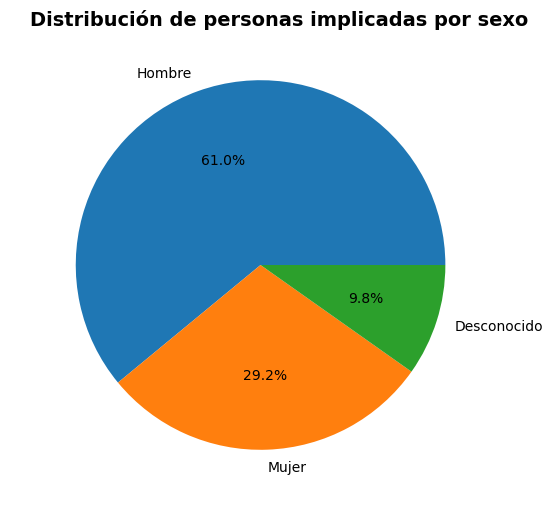

In [49]:
db['sexo'].value_counts().plot.pie(figsize=(10, 6), autopct='%1.1f%%')
plt.title('Distribución de personas implicadas por sexo', fontsize=14, fontweight='bold', loc = 'left') 
plt.ylabel(' ')
plt.show()

Según el gráfico, la mayoría de los implicados en accidentes de tráfico son hombres (aprox. un 61 %), frente a un 29 % de mujeres y con casi un 10 % de personas de las que se desconoce su género (lo que puede deberse a errores en la toma de datos en el momento del siniestro, a fugas al producirse el mismo, etc...).

Proseguimos con el análisis centrado en las personas implicadas en los accidentes con la variable 'rango_edad', cuyas etiquetas son:

In [50]:
db['rango_edad'].unique()

array(['De 55 a 59 años', 'De 25 a 29 años', 'De 35 a 39 años',
       'De 50 a 54 años', 'De 60 a 64 años', 'De 21 a 24 años',
       'De 30 a 34 años', 'De 18 a 20 años', 'Desconocido',
       'De 40 a 44 años', 'De 15 a 17 años', 'De 45 a 49 años',
       'Más de 74 años', 'De 65 a 69 años', 'De 70 a 74 años',
       'Menor de 5 años', 'De 6 a 9 años', 'De 10 a 14 años'],
      dtype=object)

In [51]:
db['rango_edad'].value_counts()

rango_edad
De 45 a 49 años    5000
Desconocido        4850
De 30 a 34 años    4822
De 25 a 29 años    4808
De 40 a 44 años    4691
De 35 a 39 años    4577
De 50 a 54 años    4532
De 55 a 59 años    3488
De 21 a 24 años    3267
De 60 a 64 años    2435
De 18 a 20 años    1576
Más de 74 años     1203
De 65 a 69 años    1169
De 70 a 74 años     728
De 15 a 17 años     462
Menor de 5 años     458
De 10 a 14 años     442
De 6 a 9 años       309
Name: count, dtype: int64

Nos encontramos con 18 etiquetas con rangos de edad relativamente pequeños, lo que nos da una idea bastante exacta de la distribución por edades de los implicados en los accidentes. No obstante, al igual que en el caso de la columna 'sexo', observamos una categoría 'Desconocido', que se encuentra además en segundo lugar en cuanto a frecuencia, y que debido al alto número registros que supone y a la imposibilidad de una imputación fiable sin sesgos importantes, vamos a mantener. Destaca que el número de registros categorizados como 'Desconocido' en la columna 'rango_edad' es muy similar al de los registros categorizados de la misma manera en la columna 'sexo', lo que refuerza la idea planteada para el caso de 'sexo' en cuanto a las causas de la presencia de esta etiqueta en un escenario de fuga de personas implicadas o bien de errores a la hora de registrar la información en el lugar del accidente.

A la hora de graficar estos rangos de edad mediante un gráfico de barras horizontales, al tratarse de una variable categórica ordinal, vamos a generar un orden personalizado para facilitar su visualización de forma análoga al orden que establecimos para 'franja_horaria':

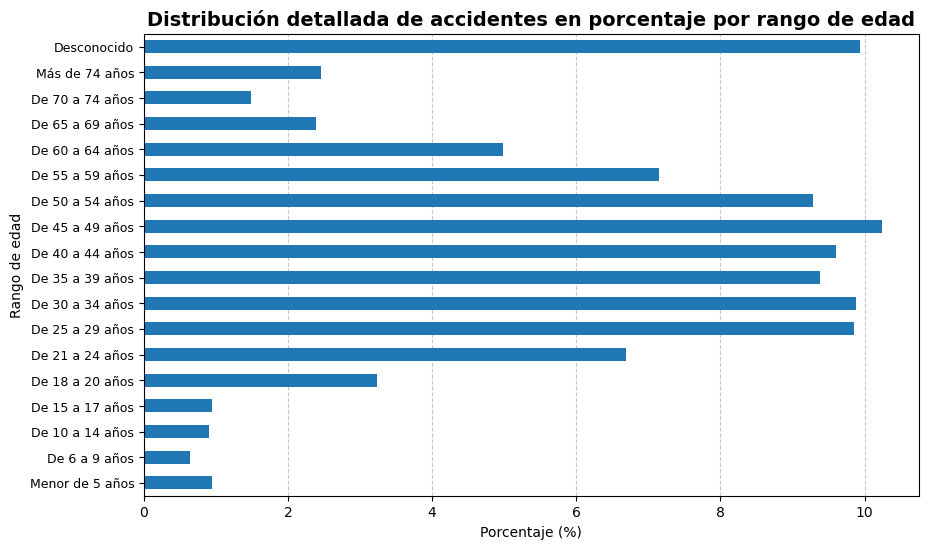

In [52]:
orden_edades = ['Menor de 5 años', 'De 6 a 9 años', 'De 10 a 14 años', 'De 15 a 17 años', 'De 18 a 20 años', 'De 21 a 24 años', 'De 25 a 29 años', 'De 30 a 34 años', 'De 35 a 39 años', 'De 40 a 44 años', 
                'De 45 a 49 años', 'De 50 a 54 años', 'De 55 a 59 años', 'De 60 a 64 años', 'De 65 a 69 años', 'De 70 a 74 años', 'Más de 74 años', 'Desconocido']

db['rango_edad'] = pd.Categorical(db['rango_edad'], categories=orden_edades, ordered=True)

(db['rango_edad'].value_counts(normalize = True, sort = False) * 100).plot.barh(figsize= (10,6))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Distribución detallada de accidentes en porcentaje por rango de edad', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Rango de edad')
plt.yticks(fontsize=9)
plt.show()

Observamos que el **rango de edad** en el que **más personas implicadas en accidentes** hay es el de personas de **entre 45 a 49 años**, seguidas de las personas de **30 a 34 años** y de **25 a 29 años**. Es llamativo también el número de personas implicadas en los siniestros de más de 74 años, significativamente superior al de las personas incluidas en el rango inmediatamente inferior (70 a 74 años), lo que sería interesante abordar más adelante en un análisis bivariado con respecto al tipo de persona implicada ('tipo_persona') y el nivel de lesividad producido ('nivel_lesividad').

Dada la gran fragmentación de los rangos de edad con que nos encontramos, y de cara al análisis bivariado que realizaremos posteriormente, vamos a crear una nueva columna denominada 'categoria_edad' que nos permita agrupar las 18 categorías de rangos de edad existentes en 6 nuevas categorías aplicando criterios de legalidad (edad legal para conducir), sociales y económicos (jóvenes hasta 34 años al retrasarse la edad de emancipación) y vulnerabilidad (ancianos de más de 74 años).

In [53]:
def asignar_categoria_edad(rango):
    if rango in ['Menor de 5 años', 'De 6 a 9 años', 'De 10 a 14 años', 'De 15 a 17 años']:
        return 'Menores de edad (< 18)'
    elif rango in ['De 18 a 20 años', 'De 21 a 24 años', 'De 25 a 29 años', 'De 30 a 34 años']:
        return 'Jóvenes (18 a 34)'
    elif rango in ['De 35 a 39 años', 'De 40 a 44 años', 'De 45 a 49 años', 'De 50 a 54 años', 'De 55 a 59 años', 'De 60 a 64 años']:
        return 'Adultos (35 a 64)'
    elif rango in ['De 65 a 69 años', 'De 70 a 74 años']:
        return 'Tercera edad (65 a 74)'
    elif rango == 'Más de 74 años':
        return 'Ancianos (> 74)'
    else:
        return 'Desconocido'
db['categoria_edad'] = db['rango_edad'].apply(asignar_categoria_edad)

Vamos a realizar un conteo de la nueva variable 'categoria_edad'

In [54]:
db['categoria_edad'].value_counts()

categoria_edad
Adultos (35 a 64)         24723
Jóvenes (18 a 34)         14473
Desconocido                4850
Tercera edad (65 a 74)     1897
Menores de edad (< 18)     1671
Ancianos (> 74)            1203
Name: count, dtype: int64

Seguidamente vamos a graficarlo de igual manera que con los rangos mediante un gráfico de barras horizontales y estableciendo el orden en que queremos mostrar las etiquetas, respetando su orden interno:

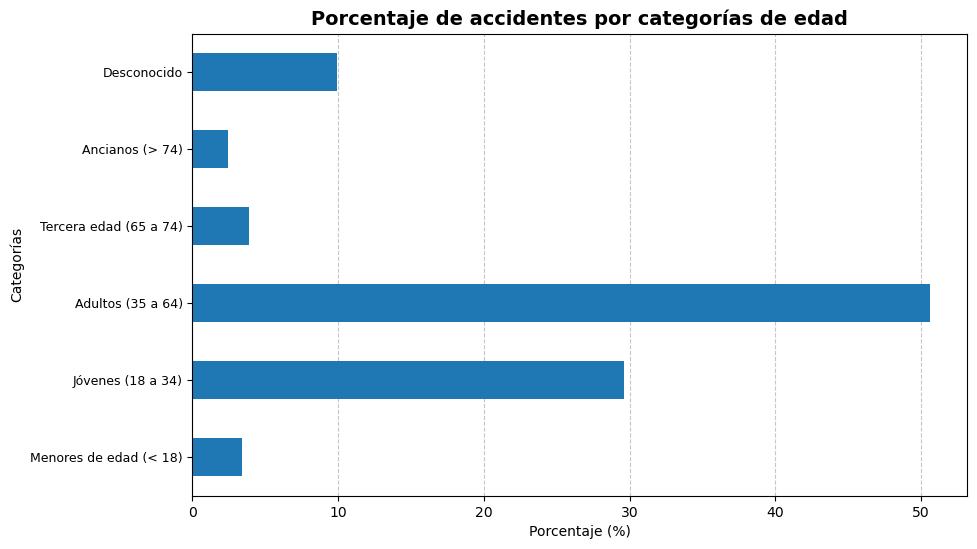

In [55]:
orden_categorias_edad = ['Menores de edad (< 18)', 'Jóvenes (18 a 34)', 'Adultos (35 a 64)', 'Tercera edad (65 a 74)', 'Ancianos (> 74)', 'Desconocido']
db['categoria_edad'] = pd.Categorical(db['categoria_edad'], categories=orden_categorias_edad, ordered=True)

(db['categoria_edad'].value_counts(normalize = True, sort = False) * 100).plot.barh(figsize= (10,6))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Porcentaje de accidentes por categorías de edad', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Categorías')
plt.yticks(fontsize=9)
plt.show()

En este gráfico, observamos resultados generales parecidos al generado para los rangos de edad, siendo los **adultos (35 a 64 años)** los que se encuentran **involucrados en un mayor número de accidentes**. Sin embargo, si bien esta categorización ayuda a visualizar y leer los datos, también difumina la anomalía detectada para los mayores de 74 años debido al método aplicado para la agrupación, que concentra el grueso de los datos en la categoría de adultos. Todo ello refuerza la importancia de realizar el análisis con diferentes niveles de detalle en los que cada uno de ellos pondrá el foco sobre distinto tipo de información.

Para finalizar con el análisis univariado, vamos a analizar las variables 'tipo_vehiculo', 'tipo_persona', 'positiva_alcohol', y 'nivel_lesividad' (en relación al total de las personas implicadas, no el máximo resgistrado para cada accidente). En el caso de la primera, realizaremos en primer lugar un conteo de las etiquetas que la integran: 


                                                                                                                                                

In [56]:
db['tipo_vehiculo'].nunique()

32

In [57]:
db['tipo_vehiculo'].value_counts(normalize = True, sort = False) * 100

tipo_vehiculo
Motocicleta > 125cc                   3.693386
Turismo                              69.215642
Bicicleta                             1.661307
Motocicleta hasta 125cc               6.770183
Camión rígido                         2.355737
Maquinaria de obras                   0.370772
Furgoneta                             6.600160
VMU eléctrico                         1.579368
Autobús                               3.070652
Bicicleta EPAC (pedaleo asistido)     0.540795
Todo terreno                          1.687937
Otros vehículos sin motor             0.024582
Autobús articulado                    0.159780
Ciclomotor                            0.964828
Sin especificar                       0.075793
Otros vehículos con motor             0.335949
Vehículo articulado                   0.172071
Autocaravana                          0.028679
Tractocamión                          0.432226
Ciclo                                 0.034824
Autobus EMT                           0.055309

Como podemos observar en los resultados del conteo, la columna 'tipo_vehiculo' contiene una cantidad de etiquetas muy elevada que dificultan tanto su visualización como su análisis. Para mejorar su legibilidad y simplificar el análisis, vamos a agruparlas según su tipología en seis categorías: 'Turismos', 'Vehículos pesados/carga','Motocicletas/ciclomotores', 'Autobuses', 'Bicicletas/ciclos/patinetes' y 'Otros', categoría que engloba todas las que no pueden incluirse en ninguna de las anteriores.  Por otra parte, tenemos una etiqueta 'Sin especificar' que representa una parte ínfima de los datos y que vamos a incluir también en 'Otros'

In [58]:
def asignar_tipo_vehiculo(vehiculo):
    if vehiculo in ['Turismo', 'Todo terreno']:
        return 'Turismos'
    elif vehiculo in ['Camión rígido','Furgoneta', 'Vehículo articulado', 'Tractocamión', 'Semiremolque', 'Remolque']:
        return 'Vehículos pesados/carga'
    elif vehiculo in ['Motocicleta > 125cc', 'Motocicleta hasta 125cc', 'Ciclomotor', 'Moto de tres ruedas > 125cc', 'Cuadriciclo ligero', 'Cuadriciclo no ligero', 'Moto de tres ruedas hasta 125cc', 'Ciclo de motor L1e-A', 'Ciclomotor de dos ruedas L1e-B', 'Ciclomotor de tres ruedas']:
        return 'Motocicletas/ciclomotores'
    elif vehiculo in ['Autobús', 'Autobús articulado', 'Autobus EMT']:
        return 'Autobuses'
    elif vehiculo in ['Bicicleta', 'Bicicleta EPAC (pedaleo asistido)', 'Ciclo', 'Patinete no eléctrico', 'VMU eléctrico']:
        return 'Bicicletas/ciclos/patinetes'
    else:
        return 'Otros'
db['categoria_vehiculo'] = db['tipo_vehiculo'].apply(asignar_tipo_vehiculo)

In [59]:
db['categoria_vehiculo'].value_counts(normalize = True) * 100

categoria_vehiculo
Turismos                       70.903579
Motocicletas/ciclomotores      11.571789
Vehículos pesados/carga         9.566340
Bicicletas/ciclos/patinetes     3.832681
Autobuses                       3.285741
Otros                           0.839871
Name: proportion, dtype: float64

Una vez que hemos agrupado las categorías de 'tipo_vehiculo' en la nueva columna 'categoria_vehiculo', vamos a graficarla junto con 'tipo persona':

In [60]:
(db['tipo_persona'].value_counts(normalize = True) * 100)

tipo_persona
Conductor    80.093000
Pasajero     16.701149
Peatón        3.205850
Name: proportion, dtype: float64

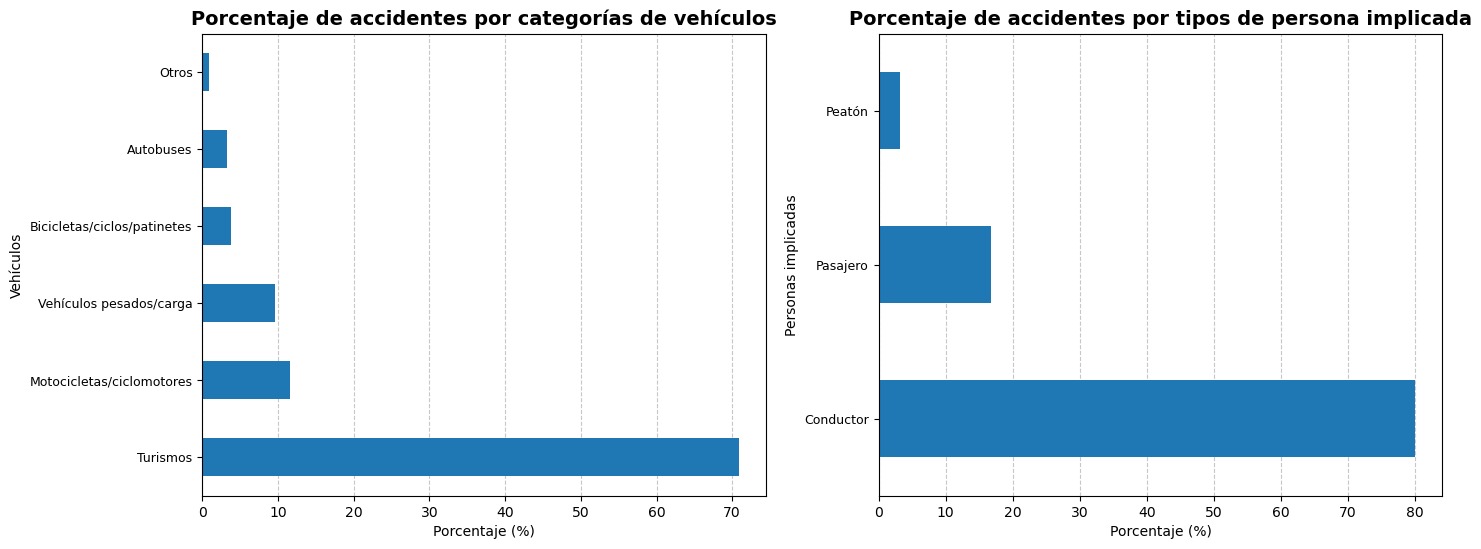

In [61]:
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
(db['categoria_vehiculo'].value_counts(normalize = True) * 100).plot.barh()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Porcentaje de accidentes por categorías de vehículos', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Vehículos')
plt.yticks(fontsize=9)

plt.subplot(1, 2, 2)
(db['tipo_persona'].value_counts(normalize = True) * 100).plot.barh()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Porcentaje de accidentes por tipos de persona implicada', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Personas implicadas')
plt.yticks(fontsize=9)
plt.show()

Tras visualizar ambas variables podemos deducir que la inmensa **mayoría de las personas implicadas en accidentes en Madrid son conductores de turismos**. No obstante, cabe destacar las motocicletas y ciclomotores como segundo tipo de vehículo más relacionado con mayor siniestralidad. Asimismo, es de destacar el porcentaje de 3.20 % de peatones, que, si bien constituyen la categoría de personas con menor frecuencia de implicación, representan a priori el grupo más vulnerable, por lo que resulta de gran interés analizar más adelante su nivel de lesividad específico. 

Con respecto a la variable **'positiva_alcohol'**, como es de esperar, los resultados muestran un **fuerte sesgo hacia el negativo**, que supone un 97.06 % de los datos, si bien el 2.93 % de positivos puede darnos pistas en el análisis bivariado que realizaremos más adelante, donde podremos analizar si existen correlaciones importantes con otras variables como las relacionadas con la edad, el sexo, franja horaria o tipo de accidente.

In [62]:
db['positiva_alcohol'].value_counts(normalize = True) * 100

positiva_alcohol
N    97.064547
S     2.935453
Name: proportion, dtype: float64

Por último, en relación a la variable **'nivel_lesividad'** (respecto al total de las personas implicadas) su **distribución es similar a la que ya observamos para el nivel de lesividad respecto a cada siniestro**. No obstante, los porcentajes relativos varían, ya que en un mismo accidente pueden coexistir diferentes niveles de lesividad, siendo el nivel 0 (sin asistencia) el más frecuente entre todos los involucrados.

In [63]:
db['nivel_lesividad'].value_counts(normalize = True) * 100

nivel_lesividad
0    77.108384
1    21.678923
2     1.212692
Name: proportion, dtype: float64

## 5. Análisis Bivariante y Multivariante

En esta fase de nuestro análisis vamos a explorar las posibles relaciones existentes entre las variables del dataset. Durante el paso anterior de análisis univariado, hemos detectado posibles interacciones sobre las que sería valioso incidir para llegar a las conclusiones finales de nuestra exploración, además de añadir algunas más que consideramos de interés para el estudio.

Comenzaremos estudiando la relación entre la gravedad de los accidentes (dada por su nivel_lesividad) y diferentes factores externos como son la climatología en el momento del accidente (estado_meteorologico), el tipo de vehículo implicado (categoria_vehiculo), la franja horaria (franja_horaria), el tipo de accidente (categoria_accidente) y el tipo de vía en la que se produjo el siniestro (tipo_via), así como la posible interacción entre la meteorología y el tipo de accidente (categoria_accidente).

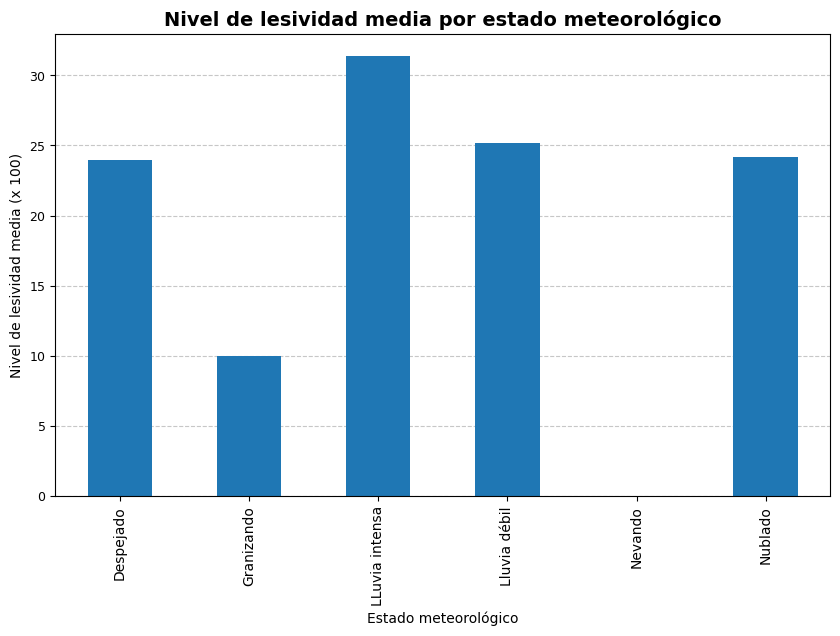

In [64]:
# En primer lugar vamos a realizar un gráfico de barras verticales comparando el nivel de lesividad medio con las consiciones meteorológicas:
(db.groupby('estado_meteorologico')['nivel_lesividad'].mean() * 100).plot.bar(figsize = (10,6))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Nivel de lesividad media por estado meteorológico', fontsize=14, fontweight='bold')
plt.xlabel('Estado meteorológico')
plt.ylabel('Nivel de lesividad media (x 100)')
plt.yticks(fontsize=9)
plt.show()

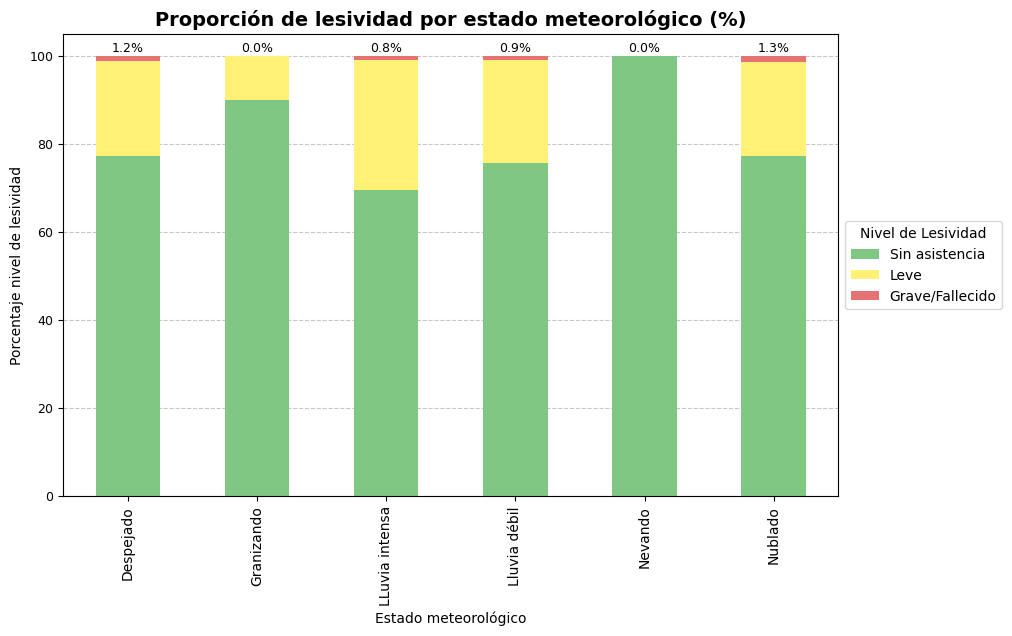

In [65]:
# Ahora vamos a realizar un gráfico de barras de estado meteorológico apiladas por nivel de lesividad:

db_plot_bar = db.groupby(['estado_meteorologico', 'nivel_lesividad']).size().unstack().fillna(0)
db_plot_bar_porcentaje = db_plot_bar.div(db_plot_bar.sum(axis=1), axis=0) * 100
ax = db_plot_bar_porcentaje.plot.bar(figsize=(10, 6), stacked = True, color=['#81c784', '#fff176', '#e57373'])
 
# Este bucle es para poner los porcentajes de accidentes con nivel de lesividad grave dentro de cada categoría de estado meteorológico:
valores_graves = db_plot_bar_porcentaje[2]
for x, y in enumerate(valores_graves):
    ax.text(x, 101, f'{y:.1f}%', ha='center', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Proporción de lesividad por estado meteorológico (%)', fontsize=14, fontweight='bold')
plt.xlabel('Estado meteorológico')
plt.ylabel('Porcentaje nivel de lesividad')
plt.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], 
           loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(fontsize=9)
plt.show()

Como podemos observar en los gráficos, a pesar de que en el análisis univariado vimos que el mayor número de accidentes se produce en condiciones climáticas favorables, es con meteorología adversa (en concreto, lluvia intensa y lluvia débil) cuando se producen accidentes con un nivel medio de lesividad mayor. Sin embargo, con respecto a los accidentes graves, al analizar el gráfico de barras apiladas, vemos que curiosamente los niveles de lesividad más altos se producen en climas nublados y despejados, lo que podría deberse al nivel de confianza y alerta que tienen las personas en condiciones meteorológicas más favorables, en las que tenemos tendencia a relajarnos, descuidar la atención a nuestro entorno e incluso circular a mayor velocidad en el caso de los conductores.

En cuanto la relación entre las condiciones meteorológicas y el tipo de accidente, vamos a trabajar sobre el DataFrame db_accidentes que creamos en el análisis univariado para trabajar con algunas variables agrupadas accidente ('num_expediente'). En concreto, vamos a realizar un gráfico de barras apiladas, en este caso horizontales para mejor legibilidad:

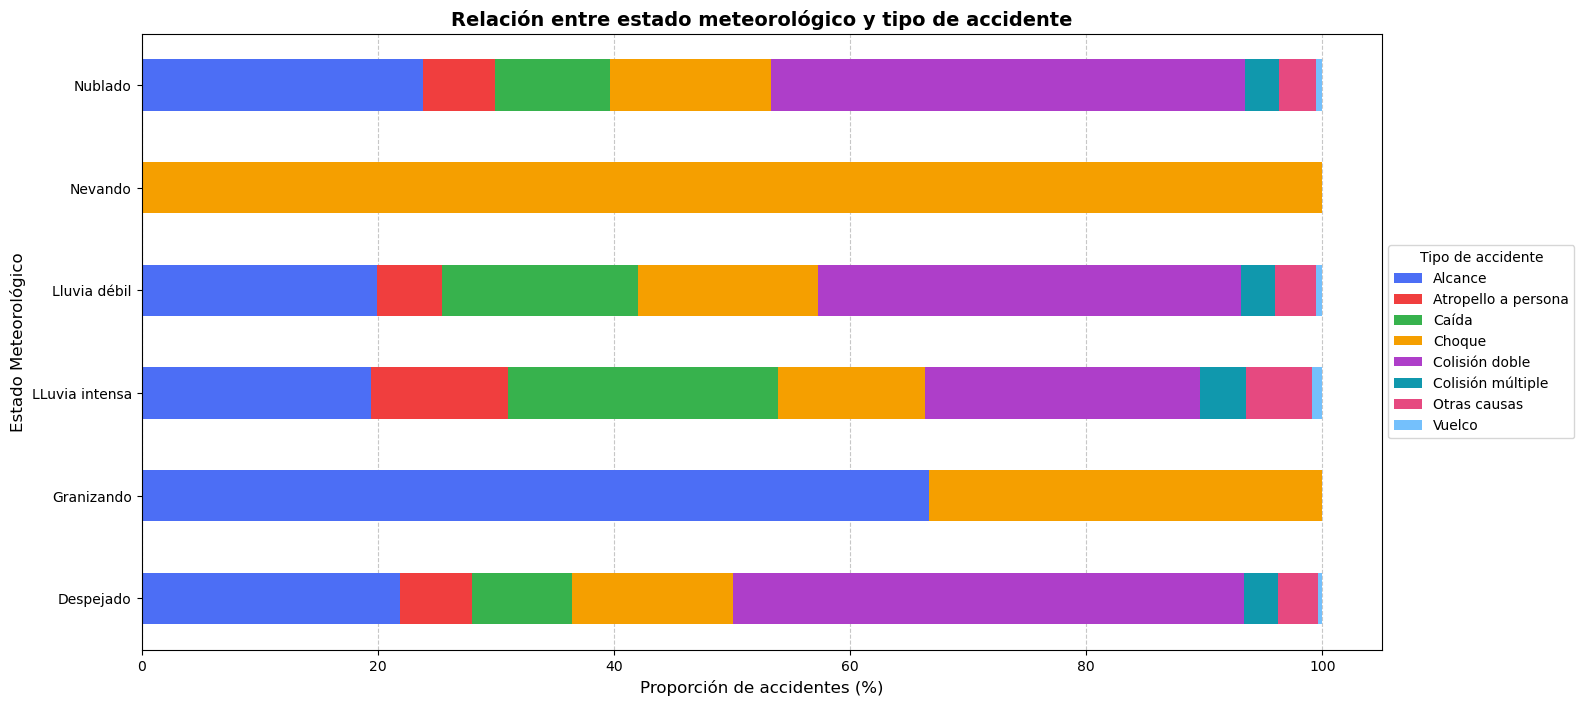

In [66]:
db_accidentes_plot_bar = db_accidentes.groupby(['estado_meteorologico', 'tipo_accidente']).size().unstack().fillna(0)
db_accidentes_plot_bar_porcentaje = db_accidentes_plot_bar.div(db_accidentes_plot_bar.sum(axis=1), axis=0) * 100
db_accidentes_plot_bar_porcentaje.plot.barh(figsize=(16, 8), stacked = True, color=['#4C6EF5','#F03E3E','#37B24D','#F59F00','#AE3EC9','#1098AD','#E64980','#74C0FC'])
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Relación entre estado meteorológico y tipo de accidente', fontsize=14, fontweight='bold')
plt.xlabel('Proporción de accidentes (%)', fontsize=12)
plt.ylabel('Estado Meteorológico', fontsize=12)
plt.legend(title='Tipo de accidente', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.yticks(fontsize=10)
plt.show()

Vemos que, exceptuando el caso del granizo o la nieve, que suponen un porcentaje muy marginal dentro de los posibles estados meteorológicos y por lo tanto no tienen representatividad suficiente para considerarlos individualmente, las colisiones dobles (que son los accidentes con más incidencia, según concluimos en el análisis univariado) se producen mayoritariamente en días nublados o despejados, lo que coincide con las condiciones meteorológicas en las que se producen los siniestros con niveles de lesividad más alto, tal y como vimos anteriormente. Esta relación es coherente, ya que las colisiones dobles son un tipo de accidente que por su naturaleza pueden conllevar un mayor grado de gravedad. Los alcances también se producen mayoritariamente en días nublados y despejados, probablemente por los mismos motivos por los que podría explicarse el aumento del nivel de lesividad en estas condiciones meteorológicas, como son el exceso de confianza y relajación, además del aumento de la velocidad de circulación.

Por otra parte, vemos una proporción mayor de caídas en condiciones de lluvia intensa y débil, algo totalmente razonable debido al agua acumulada en el pavimento bajo estas condiciones climáticas. También durante situaciones de lluvia intensa se registra mayor porcentaje de atropellos a personas, lo que puede explicarse con el aumento de la distancia de frenado con pavimento mojado y la disminución de la visibilidad.

Continuando con nuestro análisis bivariado, vamos a explorar la relación entre la franja horaria y el nivel de lesividad del accidente, de especial interés en este EDA por tratarse de una de las preguntas de negocio a las que queremos dar respuesta. Para ello, vamos a graficar mediante un gráfico de barras apiladas que muestre además el porcentaje de accidentes con el nivel de lesividad más alto (2 - grave) para cada franja horaria, de forma análoga a lo realizado para las variables 'estado_meteorológico' y 'nivel_lesividad':

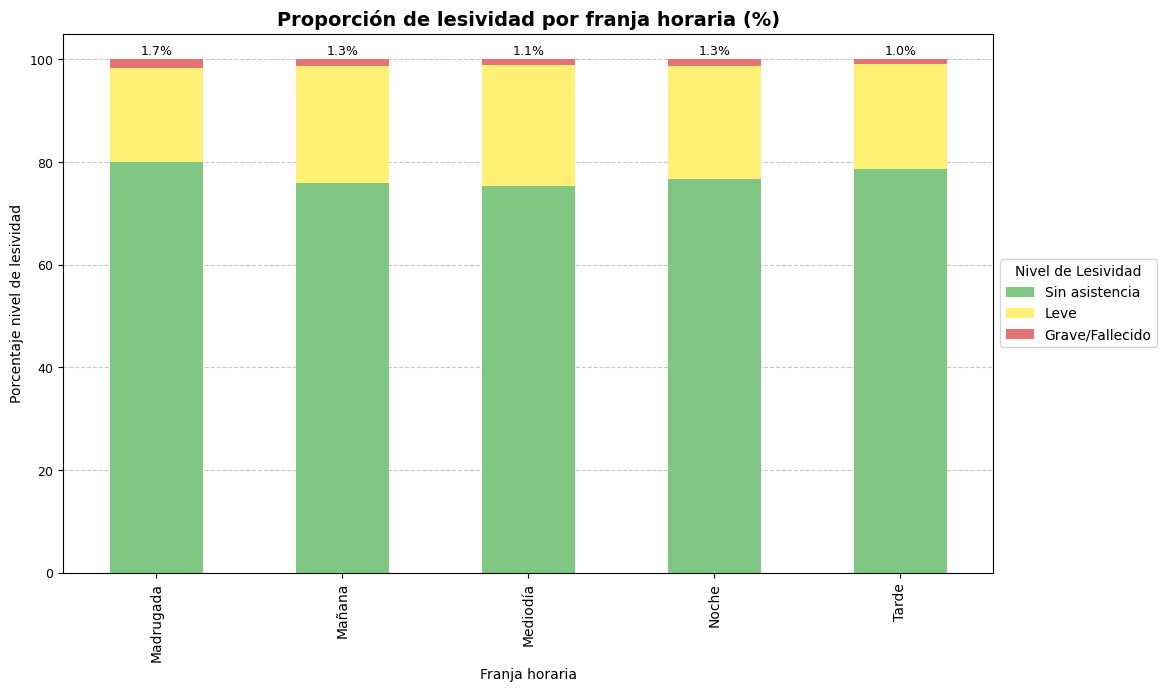

In [67]:
# Gráfico de barras de franja horaria apiladas por nivel de lesividad:

db_plot_bar_franja = db.groupby(['franja_horaria', 'nivel_lesividad']).size().unstack().fillna(0)
db_plot_bar_franja_porcentaje = db_plot_bar_franja.div(db_plot_bar_franja.sum(axis=1), axis=0) * 100
ax = db_plot_bar_franja_porcentaje.plot.bar(figsize=(12, 7), stacked = True, color=['#81c784', '#fff176', '#e57373'])
 
# Este bucle es para poner los porcentajes de accidentes con nivel de lesividad grave dentro de cada categoría de franja horaria:
valores_graves_franja = db_plot_bar_franja_porcentaje[2]
for x, y in enumerate(valores_graves_franja):
    ax.text(x, 101, f'{y:.1f}%', ha='center', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Proporción de lesividad por franja horaria (%)', fontsize=14, fontweight='bold')
plt.xlabel('Franja horaria')
plt.ylabel('Porcentaje nivel de lesividad')
plt.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(fontsize=9)
plt.show()

A tenor de los resultados visualizados en el gráfico, la franja horaria en la que se produce el porcentaje más alto de accidentes de mayor gravedad (cuyo nivel de lesividad es 2 (Grave/Fallecido) es la madrugada (establecida al inicio de nuestro análisis en el periodo comprendido entre las 00:00 y las 6:00), a pesar de ser la franja horaria en la que menor número de accidentes se producen, de acuerdo con los resultados obtenidos en el análisis univariado. Según concluimos también en éste, es durante la tarde cuando más accidentes se producen, pero tal y como podemos observar en el gráfico, el porcentaje de accidentes graves en esta franja es el más bajo, seguido del registrado a mediodía y durante la mañana y la noche, lo que apunta a una relación inversa entre el número de accidentes producidos y nivel de lesividad máxima por franja horaria, es decir, para cada franja horaria, a menor número de accidentes producidos, mayor porcentaje de accidentes graves y/o fallecidos, si bien hay que tener en cuenta que el bajo número de accidentes producidos durante la madrugada hace que el porcentaje sea más sensible a variaciones. Por otra parte, las diferencias porcentuales en el nivel más alto de lesividad entre las diferentes franjas horarias son mínimas, por lo que el efecto del número total de accidentes es aún más significativo.

Exploramos a continuación la relación entre el tipo de vehículo siniestrado (agrupados en el análisis univariado en la variable 'categoria_vehiculo') y el nivel de lesividad y lo hacemos en este caso con un gráfico de barras horizontales apiladas por nivel de lesividad:

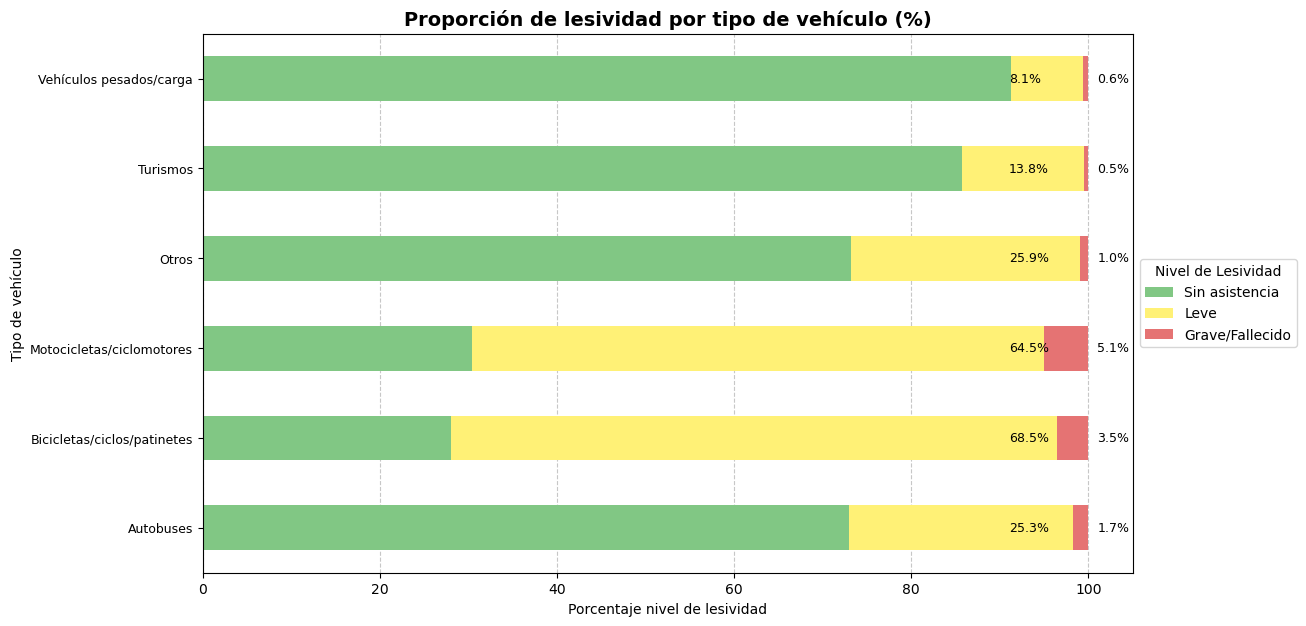

In [68]:
# Gráfico de barras horizontales de tipo de vehículo apiladas por nivel de lesividad:

db_plot_bar_vehiculo = db.groupby(['categoria_vehiculo', 'nivel_lesividad']).size().unstack().fillna(0)
db_plot_bar_vehiculo_porcentaje = db_plot_bar_vehiculo.div(db_plot_bar_vehiculo.sum(axis=1), axis=0) * 100
ax = db_plot_bar_vehiculo_porcentaje.plot.barh(figsize=(12, 7), stacked = True, color=['#81c784', '#fff176', '#e57373'])
 
# Hemos implementado dos bucles, para poner los porcentajes de accidentes con nivel de lesividad grave y leve dentro de cada categoría de tipo de vehículo:
valores_graves_vehiculo = db_plot_bar_vehiculo_porcentaje[2]
for x, y in enumerate(valores_graves_vehiculo):
    ax.text(101, x, f'{y:.1f}%', va='center', fontsize=9)
valores_leves_vehiculo = db_plot_bar_vehiculo_porcentaje[1]
for x, y in enumerate(valores_leves_vehiculo):
    ax.text(91, x, f'{y:.1f}%', va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Proporción de lesividad por tipo de vehículo (%)', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje nivel de lesividad')
plt.ylabel('Tipo de vehículo')
plt.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(fontsize=9)
plt.show()

Como observamos en el gráfico, los vehículos asociados a una mayor gravedad en los accidentes y también en los de un nivel de lesividad leve son las motocicletas/ciclomotores, con un 5,1 % de personas involucradas con un nivel de lesividad grave y un 64,5 % de implicados con nivel de lesividad leve, seguidos de las bicicletas/ciclos/patinetes (3,5 % para implicados con nivel grave), siendo los turismos (aún constituyendo la categoría de vehículos involucrada en un mayor número de accidentes en términos absolutos) los que menor porcentaje de personas involucradas con nivel de lesividad grave presentan, así como una proporción significativamente baja de implicados leves. Podemos concluir entonces que los accidentes en los que se ven involucrados turismos presentan un menor nivel de lesividad grave y que los usuarios de motocicletas/ciclomotores son los que tienen mayor riesgo de sufrir accidentes con nivel de lesividad grave, lo que resulta razonable por la propia naturaleza de los mismos. Los conductores de motocicletas (y bicicletas o patinetes) se encuentran mucho más expuestos en cualquier tipo de siniestro ya que disponen de un número significativamente inferior de sistemas de seguridad a los implementados en los turismos a lo largo de los años, gracias a la evolución de los sistemas de seguridad en vehículos y los cambios legislativos producidos.

Continuamos analizando el impacto de algunas variables sobre el nivel de lesividad explorando ahora el tipo de accidente:

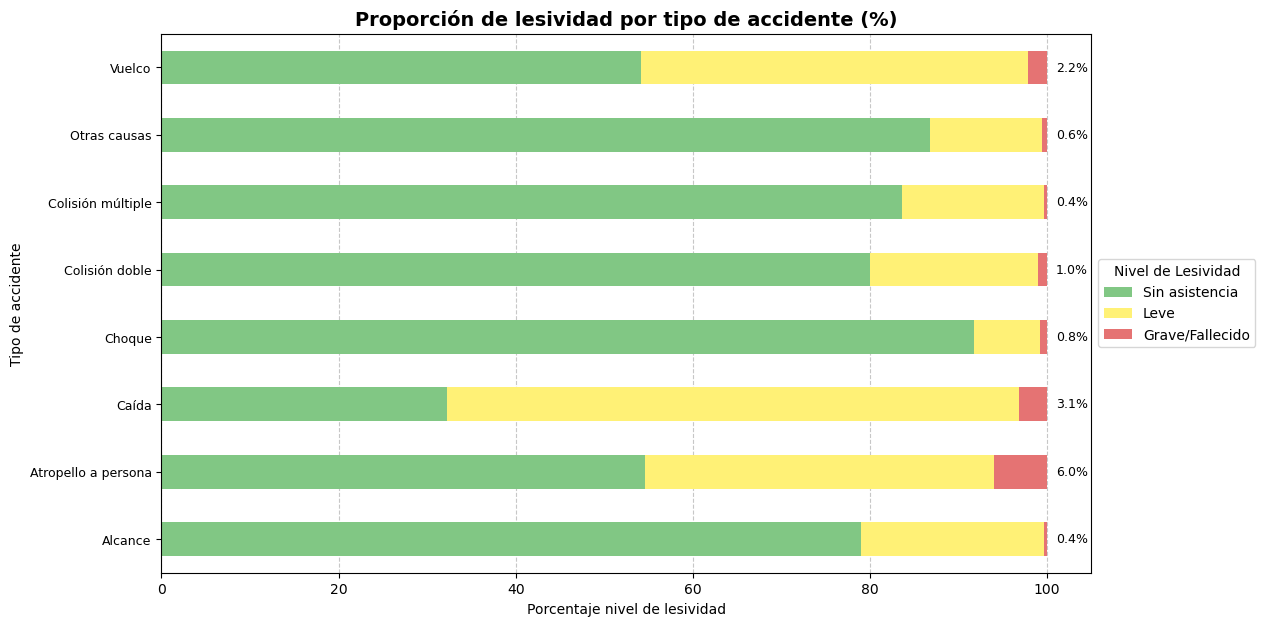

In [69]:
# Gráfico de barras horizontales de tipo de accidente apiladas por nivel de lesividad:

db_plot_bar_acc = db.groupby(['tipo_accidente', 'nivel_lesividad']).size().unstack().fillna(0)
db_plot_bar_acc_porcentaje = db_plot_bar_acc.div(db_plot_bar_acc.sum(axis=1), axis=0) * 100
ax = db_plot_bar_acc_porcentaje.plot.barh(figsize=(12, 7), stacked = True, color=['#81c784', '#fff176', '#e57373'])
 
valores_graves_acc = db_plot_bar_acc_porcentaje[2]
for x, y in enumerate(valores_graves_acc):
    ax.text(101, x, f'{y:.1f}%', va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Proporción de lesividad por tipo de accidente (%)', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje nivel de lesividad')
plt.ylabel('Tipo de accidente')
plt.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(fontsize=9)
plt.show()

En este gráfico vemos que el atropello es, con un porcentaje del 6 % (significativamente superior al resto), el tipo de accidente que mayor lesividad produce en los involucrados, seguido de las caídas (motocicletas, bicicletas, patinetes,...) con un 3.1 %. Este resultado es coherente con lo observado para los tipos de vehículo, en donde vimos que las motocicletas y bicicletas son los vehículos involucrados en accidentes con mayor nivel de lesividad. Un poco más adelante estudiaremos el nivel de lesividad por tipo de persona donde podremos confirmar si, según se desprende de estas observaciones, los peatones son el colectivo involucrado en accidentes con mayor proporción de nivel de lesividad grave. 

Para cerrar este primer bloque dentro del análisis bivariado centrado en las condiciones externas que pueden influir en la gravedad de los accidentes, vamos a estudiar la relación entre el tipo de vía y el nivel de lesividad. Para ello, al igual que en el caso de 'estado_meteorologico' y 'tipo_accidente', vamos a trabajar sobre el DataFrame db_accidentes y vamos a realizar un gráfico de barras apiladas horizontales:

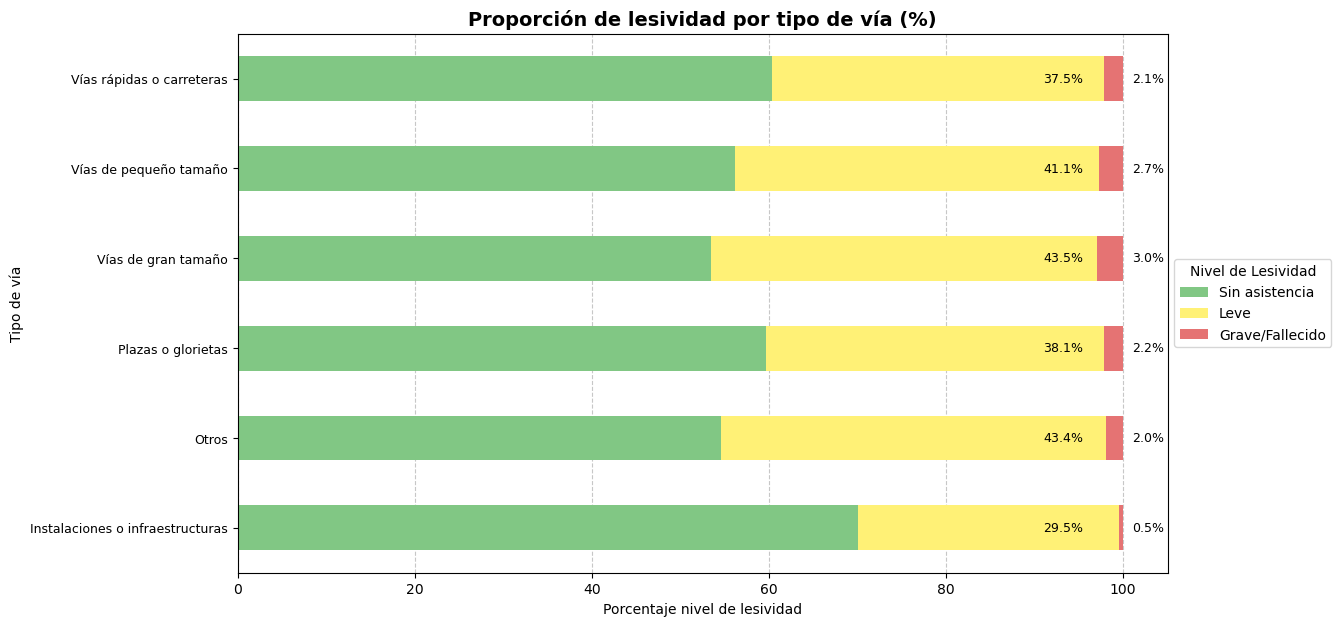

In [70]:
# Gráfico de barras horizontales de tipo de vía del DataFrame db_accidentes apiladas por nivel de lesividad:

db_accidentes_plot_bar_via = db_accidentes.groupby(['tipo_via', 'nivel_lesividad']).size().unstack().fillna(0)
db_accidentes_plot_bar_via_porcentaje = db_accidentes_plot_bar_via.div(db_accidentes_plot_bar_via.sum(axis=1), axis=0) * 100
ax = db_accidentes_plot_bar_via_porcentaje.plot.barh(figsize=(12, 7), stacked = True, color=['#81c784', '#fff176', '#e57373'])
 
# Hemos implementado dos bucles, para poner los porcentajes de accidentes con nivel de lesividad grave y leve dentro de cada categoría de tipo de vía:
valores_graves_via = db_accidentes_plot_bar_via_porcentaje[2]
for x, y in enumerate(valores_graves_via):
    ax.text(101, x, f'{y:.1f}%', va='center', fontsize=9)
valores_leves_via = db_accidentes_plot_bar_via_porcentaje[1]
for x, y in enumerate(valores_leves_via):
    ax.text(91, x, f'{y:.1f}%', va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Proporción de lesividad por tipo de vía (%)', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje nivel de lesividad')
plt.ylabel('Tipo de vía')
plt.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(fontsize=9)
plt.show()

Al analizar la lesividad de los accidentes por tipos de vía, nos encontramos con unas distribuciones bastante homogéneas en general, si bien existe una mayor proporción de lesividad grave y leve en el caso de las vías de gran tamaño, lo que puede deberse por un lado a que la velocidad media de circulación por este tipo de vías es mayor que en otro tipo de vías urbanas (dejando de lado las vías interurbanas) y por otro a dos factores relacionados con variables exploradas anteriormente: por un lado, al tipo de implicados que existen en este tipo de vías, ya que existen motocicletas, bicicletas, peatones, patinetes,.. que como vimos en el análisis de la lesividad por tipos de vehículo son más susceptibles de estar relacionados con niveles de lesividad mayores al estar más desprotegidos. Por otro, al tipo de accidentes en los que la lesividad es mayor, los atropellos y las caídas, por los mismos motivos. Ésta puede ser también la razón de que las vías de pequeño tamaño sean las segundas con niveles de lesividad más altos, ya que, a pesar de ser las vías donde más accidentes se producen en números absolutos, la velocidad de circulación en las mismas es inferior al de de las vías de mayor tamaño por lo que la incidencia en el nivel de lesividad en los tipos de accidentes y de vehículos detectados como más vulnerables es menor. 

Es interesante el caso de las plazas o glorietas en comparación con las vías rápidas: vemos también que la lesividad en las primeras es ligeramente superior que en las segundas a pesar de que la velocidad de circulación en las vías rápidas es significativamente superior, lo que puede deberse a las propias características y singularidad de las glorietas, en las que se producen continuos cambios de carril y entradas y salidas a las mismas y lo que provocará más colisiones dobles y alcances, que como vimos anteriormente son los tipos de accidente con mayor frecuencia absoluta. Sin embargo, al igual que al analizar las franjas horarias y en concreto la madrugada, en el caso de las plazas o glorietas y las vías rápidas nos encontramos con un bajo número de registros, lo que hace que los diferentes porcentajes sean más sensibles a variaciones. Por último, subrayar de nuevo que las diferencias porcentuales en el nivel más alto de lesividad entre las distintas categorías de vías son mínimas, por lo que el efecto del número total de registros es aún más importante.

Pasamos ahora a explorar las relaciones entre la gravedad de los accidentes y factores intrínsecamente humanos, como son el tipo de persona implicada en los accidentes ('tipo_persona'), sexo, rango de edad ('categoria_edad'), positivo en alcoholemia,... Además, porteriormente realizaremos análisis geográficos con GeoPandas para estudiar la interacción por distrito de algunas de las variables y la distribución geográfica de los accidentes para poder visualizarlo de manera más sencilla.

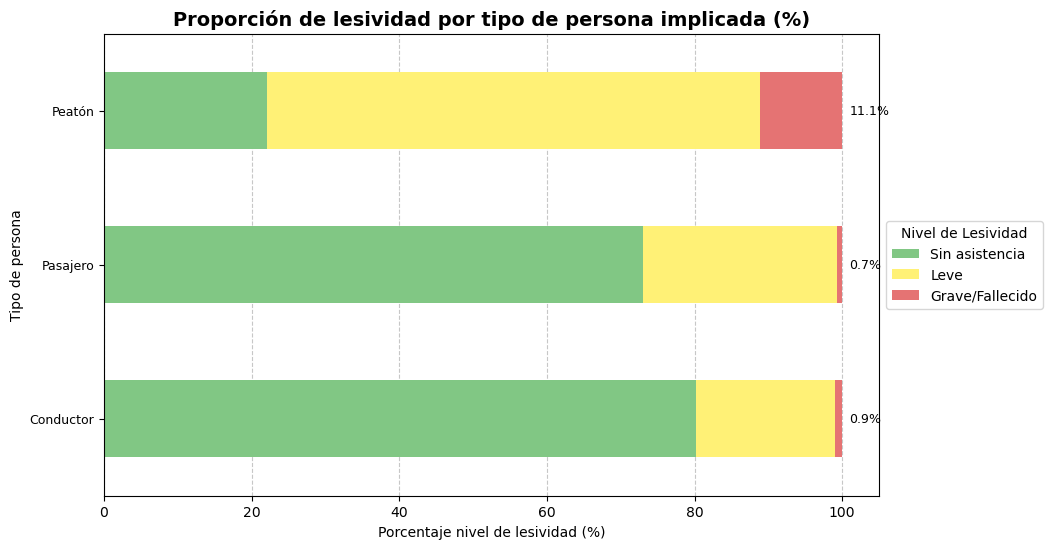

In [71]:
# Para el análisis bivariado entre tipo_persona y nivel_lesividad vamos a realizar un gráfico de barras apiladas horizontales, destacando como hemos hecho anteriormente para otras variables el porcentaje
# de cada categoría con nivel de lesividad grave/fallecido:

db_plot_bar_persona = db.groupby(['tipo_persona', 'nivel_lesividad']).size().unstack().fillna(0)
db_plot_bar_persona_porcentaje = db_plot_bar_persona.div(db_plot_bar_persona.sum(axis=1), axis=0) * 100
ax = db_plot_bar_persona_porcentaje.plot.barh(figsize=(10, 6), stacked = True, color=['#81c784', '#fff176', '#e57373'])
 
valores_graves_persona = db_plot_bar_persona_porcentaje[2]
for x, y in enumerate(valores_graves_persona):
    ax.text(101, x, f'{y:.1f}%', va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Proporción de lesividad por tipo de persona implicada (%)', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje nivel de lesividad (%)')
plt.ylabel('Tipo de persona')
plt.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(fontsize=9)
plt.show()

Como podemos observar, la gráfica muestra claramente que la mayor proporción de personas accidentadas con un nivel de lesividad más alto se concentra en los peatones, con un 11,1 % de graves/fallecidos. Además, es en este grupo de personas en el que se concentra mayor número de accidentados leves. Este resultado es perfectamente consistente con el arrojado en el análisis bivariado del tipo de accidente con el nivel de lesividad, en el que se mostraba una mayor proporción de nivel de lesividad grave/fallecido en los atropellos, siendo los peatones los más vulnerables en este tipo de siniestros. Conductores y pasajeros, por contra, presentan en general unos niveles de lesividad bajos, quedando sin asistencia en más de un 70 % de los casos en los pasajeros y del 80 % en el caso de los conductores.

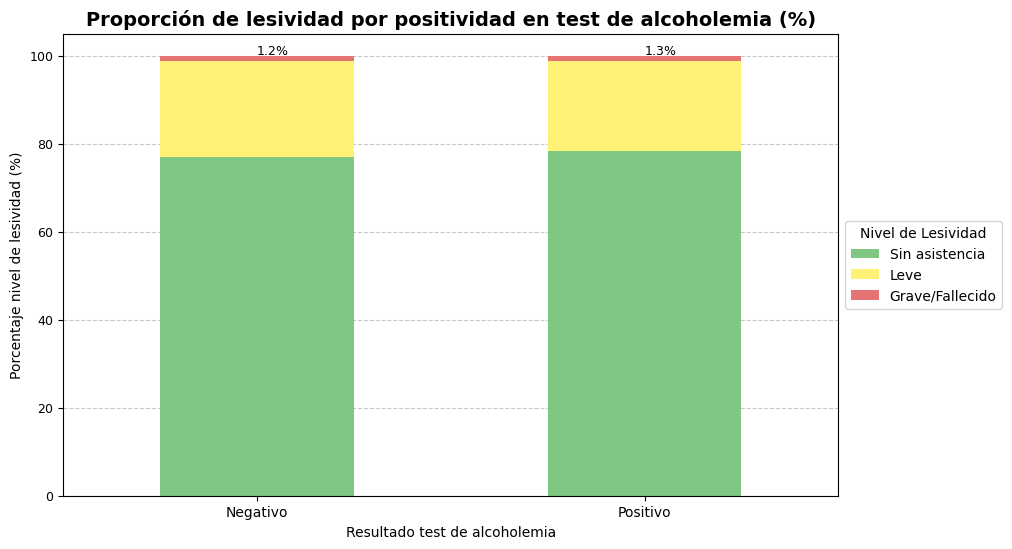

In [72]:
db_plot_bar_alcohol = db.groupby(['positiva_alcohol', 'nivel_lesividad']).size().unstack().fillna(0)
db_plot_bar_alcohol_porcentaje = db_plot_bar_alcohol.div(db_plot_bar_alcohol.sum(axis=1), axis=0) * 100
ax = db_plot_bar_alcohol_porcentaje.plot.bar(figsize=(10, 6), stacked = True, color=['#81c784', '#fff176', '#e57373'])
 
valores_graves_alcohol = db_plot_bar_alcohol_porcentaje[2]
for x, y in enumerate(valores_graves_alcohol):
    ax.text(x, 101, f'{y:.1f}%', va='center', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Proporción de lesividad por positividad en test de alcoholemia (%)', fontsize=14, fontweight='bold')
plt.xlabel('Resultado test de alcoholemia')
plt.ylabel('Porcentaje nivel de lesividad (%)')
ax.set_xticklabels(['Negativo', 'Positivo'], rotation = 0)
plt.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(fontsize=9)
plt.show()

Con respecto a la relación entre el nivel de lesividad y el resultado del test de alcoholemia, vemos que las distribuciones de la lesividad en los test negativos y positivos son muy similares, produciéndose el nivel de lesividad más alto en una proporción ligeramente superior en el caso de las personas que dieron positivo en el test (1,3 % frente a un 1.2 % de accidentes graves en el caso de las personas que dieron negativo en alcoholemia). Al tratarse de un resultado tan homogéneo, no podemos concluir que la positividad en alcohol en los accidentes sea un factor determinante en el nivel de lesividad de los mismos.

Cabe destacar también, que al encontrarse la variable 'positiva_alcohol' sumamente sesgada hacia el no (tal y como se observó en el análisis univariado realizado anteriormente), el número de registros del grupo de los positivos es muy pequeño, por lo que el porcentaje de accidentes graves es muy sensible a variaciones, de forma análoga a lo detectado para la franja horaria madrugada o los tipos de vía plazas/glorietas.

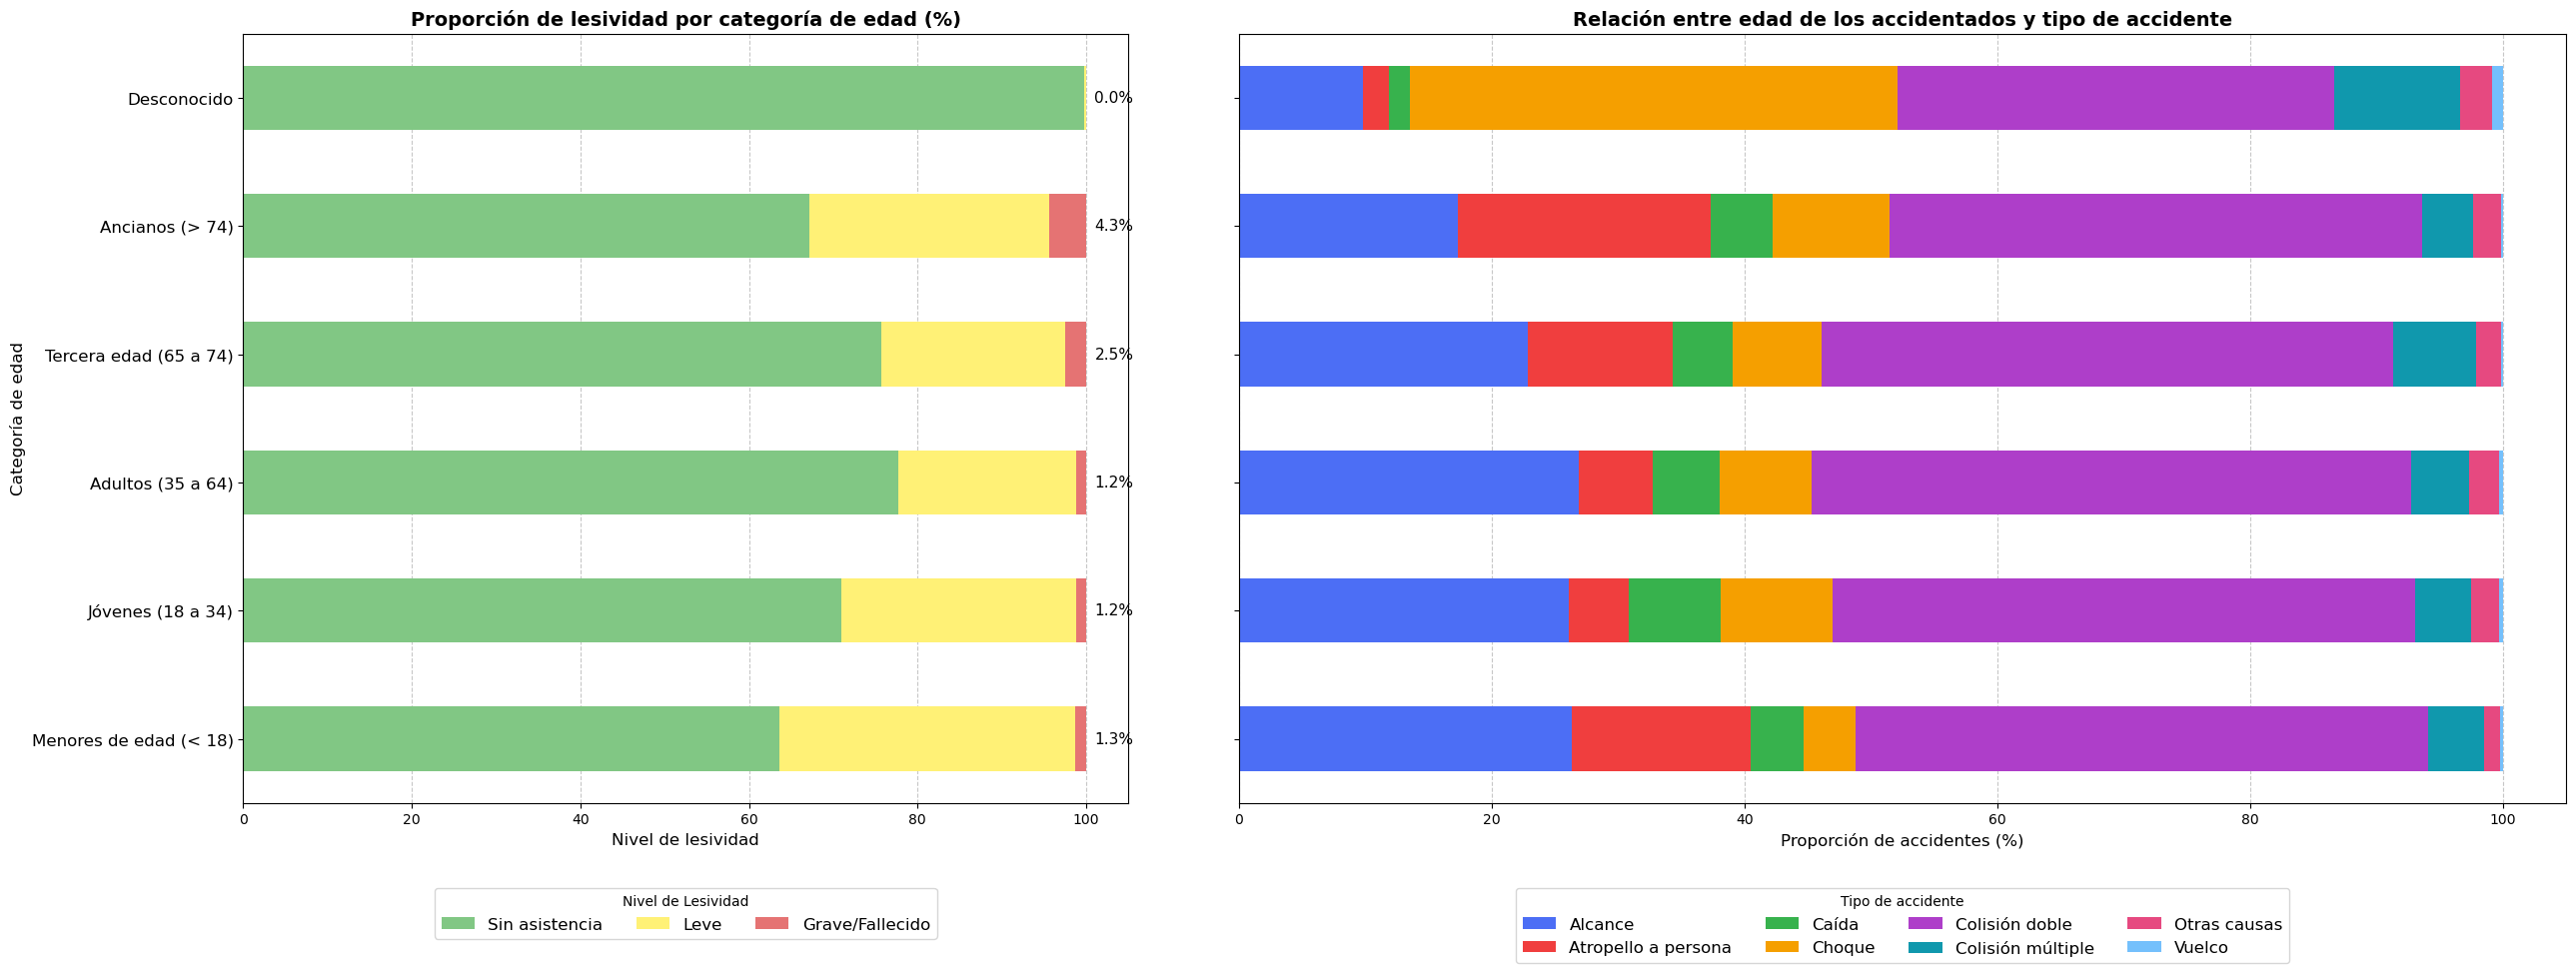

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10), gridspec_kw={'width_ratios': [1, 1.5]})

db_plot_bar_edad = db.groupby(['categoria_edad', 'nivel_lesividad'], observed=False).size().unstack().fillna(0)
db_plot_bar_edad_porcentaje = db_plot_bar_edad.div(db_plot_bar_edad.sum(axis=1), axis=0) * 100
db_plot_bar_edad_porcentaje.plot.barh(ax=ax1, stacked=True, color=['#81c784', '#fff176', '#e57373'])
valores_graves_edad = db_plot_bar_edad_porcentaje[2]
for x, y in enumerate(valores_graves_edad):
    ax1.text(101, x, f'{y:.1f}%', va='center', fontsize=11)
ax1.grid(axis='x', linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)
ax1.set_title('Proporción de lesividad por categoría de edad (%)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nivel de lesividad', fontsize=12)
ax1.set_ylabel('Categoría de edad', fontsize=12)
ax1.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol = 3, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

db_plot_bar_edad_acc = db.groupby(['categoria_edad', 'tipo_accidente'], observed=False).size().unstack().fillna(0)
db_plot_bar_edad_acc_porcentaje = db_plot_bar_edad_acc.div(db_plot_bar_edad_acc.sum(axis=1), axis=0) * 100
db_plot_bar_edad_acc_porcentaje.plot.barh(ax=ax2, stacked=True, color=['#4C6EF5','#F03E3E','#37B24D','#F59F00','#AE3EC9','#1098AD','#E64980','#74C0FC'])
ax2.grid(axis='x', linestyle='--', alpha=0.7)
ax2.set_axisbelow(True)
ax2.set_title('Relación entre edad de los accidentados y tipo de accidente', fontsize=14, fontweight='bold')
ax2.set_xlabel('Proporción de accidentes (%)', fontsize=12)
ax2.set_ylabel(' ')
ax2.legend(title='Tipo de accidente', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol = 4, fontsize=12)
ax2.tick_params(axis='y', labelleft=False)

plt.subplots_adjust(wspace=0.1)
plt.show()

Observamos en estos gráficos que la proporción del nivel de lesividad más alto se produce entre los ancianos mayores de 74 años (un 4,3 %), seguidos de los integrantes del grupo de la tercera edad (entre 65 y 74 años), mostrando el resto de grupos de edad una proporción de lesividad alta muy similar entre sí. Además, como podemos ver en el gráfico que muestra la relación entre los rangos de edad de los accidentados y el tipo de accidente sufrido, vemos que en la franja de edad con mayor lesividad es también en la que se producen más atropellos, lo que es coherente con lo analizado anteriormente en cuanto al nivel de lesividad por tipo de accidente, en donde comprobamos que el porcentaje de mayor lesividad se produce en los atropellos. 

Los accidentes que se producen con mayor frecuencia (colisiones dobles y alcances) tienen una distribución bastante parecida entre el resto de grupos de edad, no observándose diferencias significativas en este aspecto. Destaca también que el segundo grupo de edad que sufre mayor proporción de atropellos es el de los menores, lo que es consecuente con las características del grupo, con mayor propensión a la distracción y menor nivel de cumplimiento de las normas de circulación que el resto de grupos poblacionales, rasgos que comparten con el grupo de mayores de 74 años y tercera edad.

Es significativo, además, que la mayor proporción de caídas se produce en la categoría jóvenes ( de 18 a 34 años), ya que este grupo tiende a usar más vehículos tipo motocicletas, ciclomotores, bicicletas y patinetes que son los susceptibles de sufrir este tipo de accidentes.

Por último, cabe recordar que la categoría 'Desconocido' supone un porcentaje relevante del dataset y no permite extraer conclusiones sobre el perfil de edad de esos implicados, si bien podemos observar que en este grupo no hay ningún accidente grave o con resultado de muerte y que además tiene en porcentaje de choques y colisiones múltiples más alto de todas las categorías registradas, lo que reforzaría la idea planteada en el análisis univariado de que estos datos desconocidos en la variable 'rango_edad' se deba a fugas producidas tras el accidente.

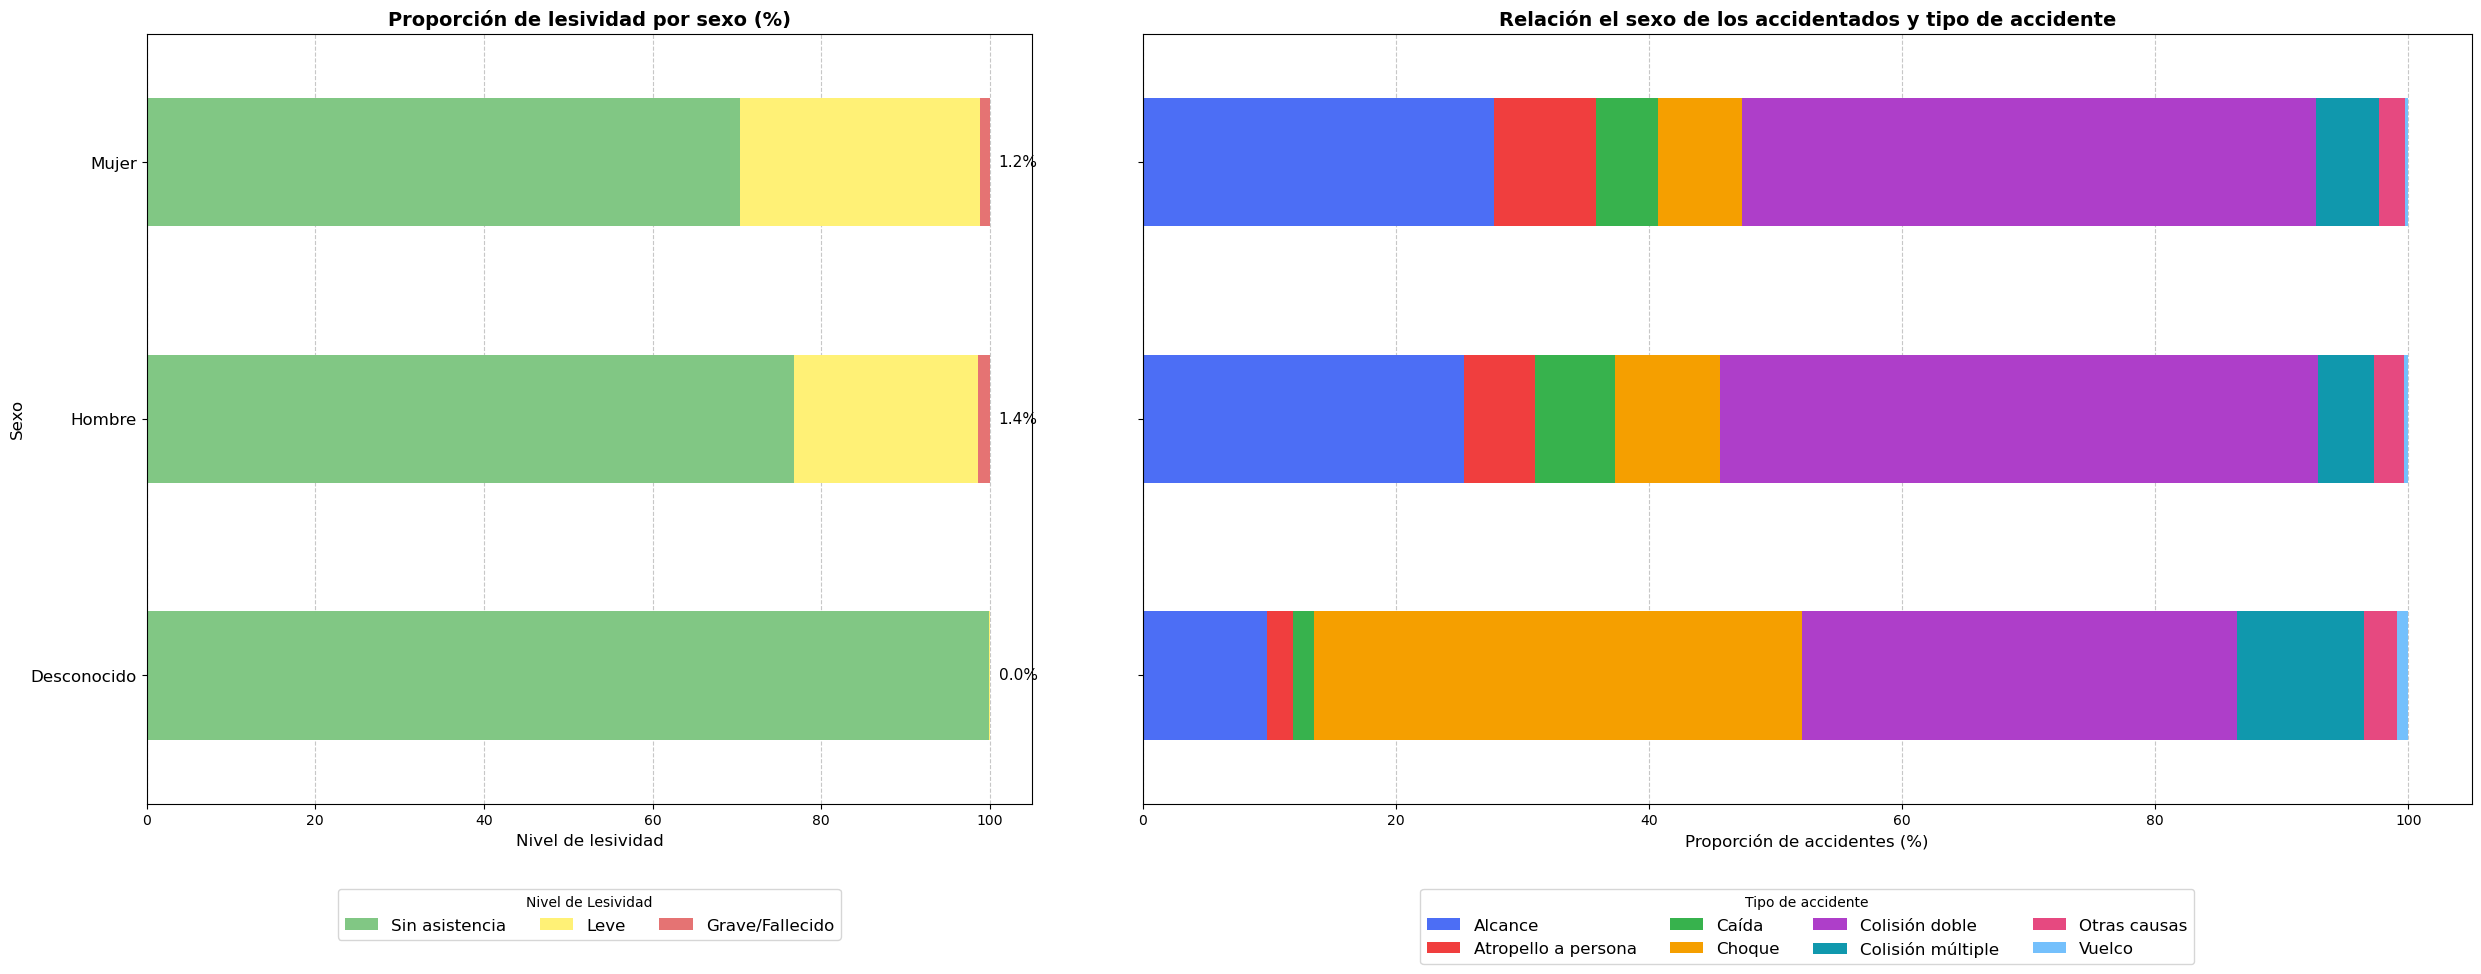

In [74]:
# Vamos a realizar con el sexo dos subplots de forma análoga a lo realizado para las categorías de edad y la lesividad y tipo de accidente:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10), gridspec_kw={'width_ratios': [1, 1.5]})

db_plot_bar_sexo = db.groupby(['sexo', 'nivel_lesividad'], observed=False).size().unstack().fillna(0)
db_plot_bar_sexo_porcentaje = db_plot_bar_sexo.div(db_plot_bar_sexo.sum(axis=1), axis=0) * 100
db_plot_bar_sexo_porcentaje.plot.barh(ax=ax1, stacked=True, color=['#81c784', '#fff176', '#e57373'])
valores_graves_sexo = db_plot_bar_sexo_porcentaje[2]
for x, y in enumerate(valores_graves_sexo):
    ax1.text(101, x, f'{y:.1f}%', va='center', fontsize=11)
ax1.grid(axis='x', linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)
ax1.set_title('Proporción de lesividad por sexo (%)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nivel de lesividad', fontsize=12)
ax1.set_ylabel('Sexo', fontsize=12)
ax1.legend(title='Nivel de Lesividad', labels=['Sin asistencia', 'Leve', 'Grave/Fallecido'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol = 3, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

db_plot_bar_sexo_acc = db.groupby(['sexo', 'tipo_accidente'], observed=False).size().unstack().fillna(0)
db_plot_bar_sexo_acc_porcentaje = db_plot_bar_sexo_acc.div(db_plot_bar_sexo_acc.sum(axis=1), axis=0) * 100
db_plot_bar_sexo_acc_porcentaje.plot.barh(ax=ax2, stacked=True, color=['#4C6EF5','#F03E3E','#37B24D','#F59F00','#AE3EC9','#1098AD','#E64980','#74C0FC'])
ax2.grid(axis='x', linestyle='--', alpha=0.7)
ax2.set_axisbelow(True)
ax2.set_title('Relación el sexo de los accidentados y tipo de accidente', fontsize=14, fontweight='bold')
ax2.set_xlabel('Proporción de accidentes (%)', fontsize=12)
ax2.set_ylabel(' ')
ax2.legend(title='Tipo de accidente', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol = 4, fontsize=12)
ax2.tick_params(axis='y', labelleft=False)

plt.subplots_adjust(wspace=0.1)
plt.show()

En relación al sexo y la lesividad y el tipo de accidente, no se observan patrones con diferencias significativas entre hombre y mujer. La proporción con nivel de lesividad alta en ambos grupos es muy parecida, existiendo únicamente una pequeña diferencia en la lesividad leve, algo mayor en mujeres. En cuanto al tipo de accidentes, se distribuyen de forma bastante similar en ambos grupos, siendo algo más frecuentes los alcances y atropellos en mujeres y algo más frecuentes los choques y colisiones dobles en hombres.

Es destacable también el caso de los datos desconocidos de sexo, que funcionan de forma equivalente a los desconocidos por rango de edad, suponiendo el mayor porcentaje de choques y colisiones múltiples y un porcentaje nulo de heridos graves o fallecidos, por lo que, al igual que en lo que se refiere al rango de edad, reafirma la idea de la presencia de esos datos desconocidos por fugas tras los siniestros.

Vamos a continuación con el análisis geográfico con GeoPandas de las variables nivel de lesividad y tipo de accidente por distrito:

In [75]:
# En primer lugar cargamos el archivo GeoJson que previamente hemos descargado del geoportal del Ayutamiento de Madrid 
# (https://geoportal.madrid.es/IDEAM_WBGEOPORTAL/dataset.iam?id=541f4ef6-762b-11e9-861d-ecb1d753f6e8). 

db_distritos = gpd.read_file('Distritos.geojson')

#hacemos un .head() a dd_distritos a ver qué columnas tenemos:

db_distritos.head(10)

,id,COD_DIS,COD_DIS_TX,NOMBRE,DISTRI_MAY,DISTRI_MT,Area_m2,geometry
0,None,1,01,Centro,CENTRO,CENTRO,None,"POLYGON ((-3.69186 40.40844, -3.69257 40.40801..."
1,None,2,02,Arganzuela,ARGANZUELA,ARGANZUELA,None,"POLYGON ((-3.72293 40.41398, -3.72047 40.41394..."
2,None,3,03,Retiro,RETIRO,RETIRO,None,"POLYGON ((-3.6587 40.41868, -3.65898 40.41745,..."
3,None,4,04,Salamanca,SALAMANCA,SALAMANCA,None,"POLYGON ((-3.6606 40.44461, -3.66012 40.44395,..."
4,None,5,05,Chamartín,CHAMARTIN,CHAMARTÍN,None,"POLYGON ((-3.67346 40.48406, -3.67352 40.48342..."
5,None,6,06,Tetuán,TETUAN,TETUÁN,None,"POLYGON ((-3.71328 40.46851, -3.71321 40.4686,..."
6,None,7,07,Chamberí,CHAMBERI,CHAMBERÍ,None,"POLYGON ((-3.69126 40.44623, -3.69179 40.44127..."
7,None,8,08,Fuencarral - El Pardo,FUENCARRAL - EL PARDO,FUENCARRAL - EL PARDO,None,"POLYGON ((-3.83665 40.47958, -3.83665 40.47958..."
8,None,9,09,Moncloa - Aravaca,MONCLOA - ARAVACA,MONCLOA - ARAVACA,None,"POLYGON ((-3.7746 40.40032, -3.77437 40.40209,..."
9,None,10,10,Latina,LATINA,LATINA,None,"POLYGON ((-3.77074 40.36055, -3.77162 40.35983..."


In [76]:
# Comprobamos cómo teníamos representados los distritos en nuestro DataFrame db:
db['distrito'].unique()

array(['HORTALEZA', 'CENTRO', 'CHAMBERÍ', 'TETUÁN', 'LATINA',
       'MONCLOA-ARAVACA', 'RETIRO', 'PUENTE DE VALLECAS', 'MORATALAZ',
       'CARABANCHEL', 'SALAMANCA', 'CHAMARTÍN', 'VICÁLVARO', 'ARGANZUELA',
       'FUENCARRAL-EL PARDO', 'USERA', 'VILLA DE VALLECAS', 'BARAJAS',
       'VILLAVERDE', 'SAN BLAS-CANILLEJAS', 'CIUDAD LINEAL'], dtype=object)

A priori parece que la columna 'DISTRI_MT' del GeoDataframe que acabamos de crear, db_distritos, es igual que nuestra columna 'distrito', pero vamos a comprobarlo exactamente:

In [77]:
print(db['distrito'].unique())
print(db_distritos['DISTRI_MT'].unique())

['HORTALEZA' 'CENTRO' 'CHAMBERÍ' 'TETUÁN' 'LATINA' 'MONCLOA-ARAVACA'
 'RETIRO' 'PUENTE DE VALLECAS' 'MORATALAZ' 'CARABANCHEL' 'SALAMANCA'
 'CHAMARTÍN' 'VICÁLVARO' 'ARGANZUELA' 'FUENCARRAL-EL PARDO' 'USERA'
 'VILLA DE VALLECAS' 'BARAJAS' 'VILLAVERDE' 'SAN BLAS-CANILLEJAS'
 'CIUDAD LINEAL']
['CENTRO' 'ARGANZUELA' 'RETIRO' 'SALAMANCA' 'CHAMARTÍN' 'TETUÁN'
 'CHAMBERÍ' 'FUENCARRAL - EL PARDO' 'MONCLOA - ARAVACA' 'LATINA'
 'CARABANCHEL' 'USERA' 'PUENTE DE VALLECAS' 'MORATALAZ' 'CIUDAD LINEAL'
 'HORTALEZA' 'VILLAVERDE' 'VILLA DE VALLECAS' 'VICÁLVARO'
 'SAN BLAS - CANILLEJAS' 'BARAJAS']


Comprobamos que son iguales a excepción de los nombres compuestos de los distritos que van separados por un guión, en db_distritos hay un espacio delante y detrás del guión y en el nuestro no, por lo que vamos a hacer una preparación sencilla de db_distritos eliminando esos espacios para que coincidan exactamente:

In [78]:
db_distritos['DISTRI_MT'] = db_distritos['DISTRI_MT'].str.replace(' - ', '-')

In [79]:
print(db['distrito'].unique())
print(db_distritos['DISTRI_MT'].unique())

['HORTALEZA' 'CENTRO' 'CHAMBERÍ' 'TETUÁN' 'LATINA' 'MONCLOA-ARAVACA'
 'RETIRO' 'PUENTE DE VALLECAS' 'MORATALAZ' 'CARABANCHEL' 'SALAMANCA'
 'CHAMARTÍN' 'VICÁLVARO' 'ARGANZUELA' 'FUENCARRAL-EL PARDO' 'USERA'
 'VILLA DE VALLECAS' 'BARAJAS' 'VILLAVERDE' 'SAN BLAS-CANILLEJAS'
 'CIUDAD LINEAL']
['CENTRO' 'ARGANZUELA' 'RETIRO' 'SALAMANCA' 'CHAMARTÍN' 'TETUÁN'
 'CHAMBERÍ' 'FUENCARRAL-EL PARDO' 'MONCLOA-ARAVACA' 'LATINA' 'CARABANCHEL'
 'USERA' 'PUENTE DE VALLECAS' 'MORATALAZ' 'CIUDAD LINEAL' 'HORTALEZA'
 'VILLAVERDE' 'VILLA DE VALLECAS' 'VICÁLVARO' 'SAN BLAS-CANILLEJAS'
 'BARAJAS']


Ahora agrupamos por distrito según el nivel de lesividad máximo y creamos dos nuevas columnas para calcular el porcentaje de accidentes más graves (es decir, aquellos en los que 'nivel_lesividad' == 2):

In [80]:
# La columna 'total' cuenta el número total de registros 'nivel_lesividad' para cada distrito, lo que es igual al número de accidentes total en cada distrito y la columna 'graves'
# suma el número de registros por distrito en los que el 'nivel_lesividad' es igual a 2, o sea, los accidentes más graves.
db_acc_graves_distrito = db_accidentes.groupby('distrito').agg(total = ('nivel_lesividad', 'count'), graves = ('nivel_lesividad', lambda x: (x == 2).sum())).reset_index()
# Creamos ahora la nueva columna 'porcentaje_graves' dentro del DataFrame db_acc_graves_distrito con la proporción de accidentes graves sobre el total, multiplicado por 100 (el porcentaje):
db_acc_graves_distrito['porcentaje_graves'] = (db_acc_graves_distrito['graves'] / db_acc_graves_distrito['total']) * 100

Con esto calculado, lo unimos con db_distritos con la función .merge():

In [81]:
# Indicamos con left_on='DISTRI_MT', right_on='distrito' por qué columna queremos unir, tenemos que especificar estos dos argumentos en este caso porque los nombres son distintos en ambos DataFrame:
db_distritos_lesividad = db_distritos.merge(db_acc_graves_distrito, left_on='DISTRI_MT', right_on='distrito')

In [82]:
# Comprobamos que haya funcionado correctamente:

In [83]:
db_distritos_lesividad.head()

,id,COD_DIS,COD_DIS_TX,NOMBRE,DISTRI_MAY,DISTRI_MT,Area_m2,geometry,distrito,total,graves,porcentaje_graves
0,None,1,01,Centro,CENTRO,CENTRO,None,"POLYGON ((-3.69186 40.40844, -3.69257 40.40801...",CENTRO,1315,33,2.509506
1,None,2,02,Arganzuela,ARGANZUELA,ARGANZUELA,None,"POLYGON ((-3.72293 40.41398, -3.72047 40.41394...",ARGANZUELA,1085,32,2.949309
2,None,3,03,Retiro,RETIRO,RETIRO,None,"POLYGON ((-3.6587 40.41868, -3.65898 40.41745,...",RETIRO,1009,25,2.477701
3,None,4,04,Salamanca,SALAMANCA,SALAMANCA,None,"POLYGON ((-3.6606 40.44461, -3.66012 40.44395,...",SALAMANCA,1392,38,2.729885
4,None,5,05,Chamartín,CHAMARTIN,CHAMARTÍN,None,"POLYGON ((-3.67346 40.48406, -3.67352 40.48342...",CHAMARTÍN,1468,47,3.201635


Vamos a dibujar el mapa:

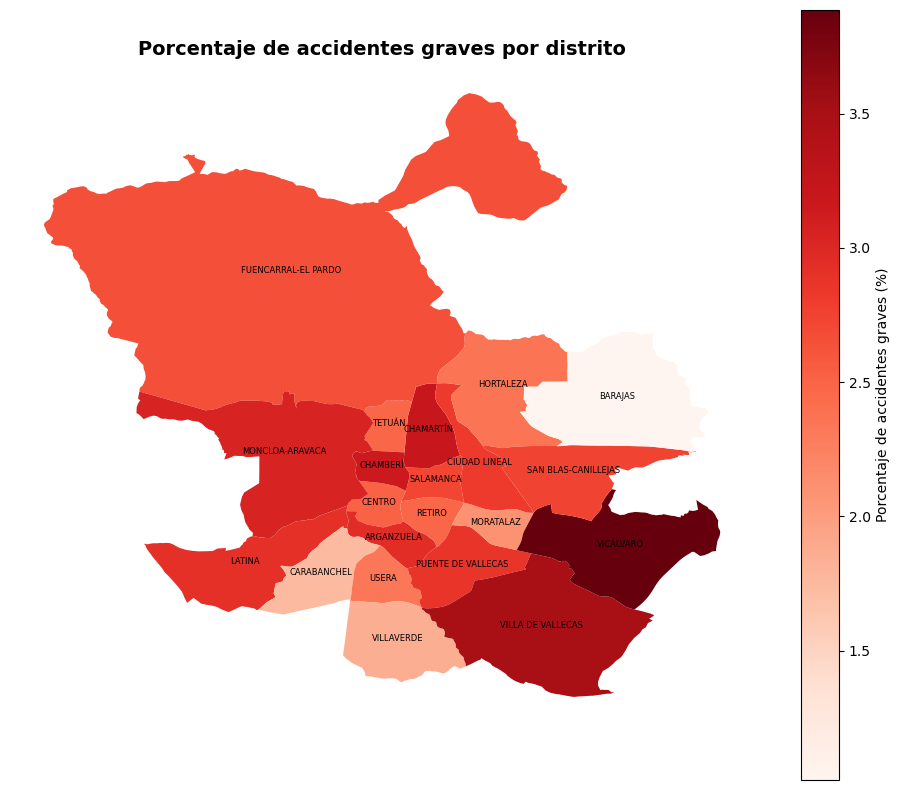

In [84]:
# Para dibujar el mapa, ponemos legend=True para que aparezca al lado la barra con los colores de la leyenda. El argumento legend_kwds permite pasar agumentos adicionales para la leyenda y con 'label'
# definimos el texto que queremos que aparezca junto a la barra de colores.
ax = db_distritos_lesividad.plot(column='porcentaje_graves', figsize=(12, 10), legend=True, cmap='Reds', legend_kwds={'label': 'Porcentaje de accidentes graves (%)'})
ax.set_title('Porcentaje de accidentes graves por distrito', fontsize=14, fontweight='bold')
ax.set_axis_off()

# Implementamos un bucle para que aparezca el nombre de cada distrito en su centro con annotate(), siendo el primer agumento el texto que queremos mostrar, en este caso los nombres de los distritos
# (columna 'DISTRI_MT'), el argumento xy, las coordenadas donde queremos que aparezca el texto (row['geometry'].centroid.x y row['geometry'].centroid.y nos dan las coordenadas geométricas del centro 
# de cada polígono de distrito) y ha = 'center' que alinea el texto en el centro respecto al punto calculado para posicionarlo.
for x, row in db_distritos_lesividad.iterrows():
    ax.annotate(row['DISTRI_MT'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), ha='center', fontsize=6)

plt.show()


Según el mapa, los accidentes de mayor gravedad se concentran principalmente en el distrito de Vicálvaro, seguido del de Villa de Vallecas. Por contra, los distritos que presentan menor porcentaje de accidentes graves son Villaverde y Carabanchel. Esta tendencia podría estar relacionada con el tipo de vías existentes en cada distrito y la velocidad de circulación por las mismas, si bien no disponemos de datos relativos a la velocidad de circulación en estos distritos, sí que disponemos de datos del tipo de vía en el que se produjo cada accidente. En el análisis bivariado entre nivel de lesividad y tipo de vía vimos que aunque hay homogeneidad en la distribución de la lesividad por tipo de vía, existe una mayor proporción de lesividad grave y leve en el caso de las vías de gran tamaño, seguidas de las vías de menor tamaño, veamos cómo se distribuye por distritos el tipo de vía para ver posibles correlaciones con la lesividad:

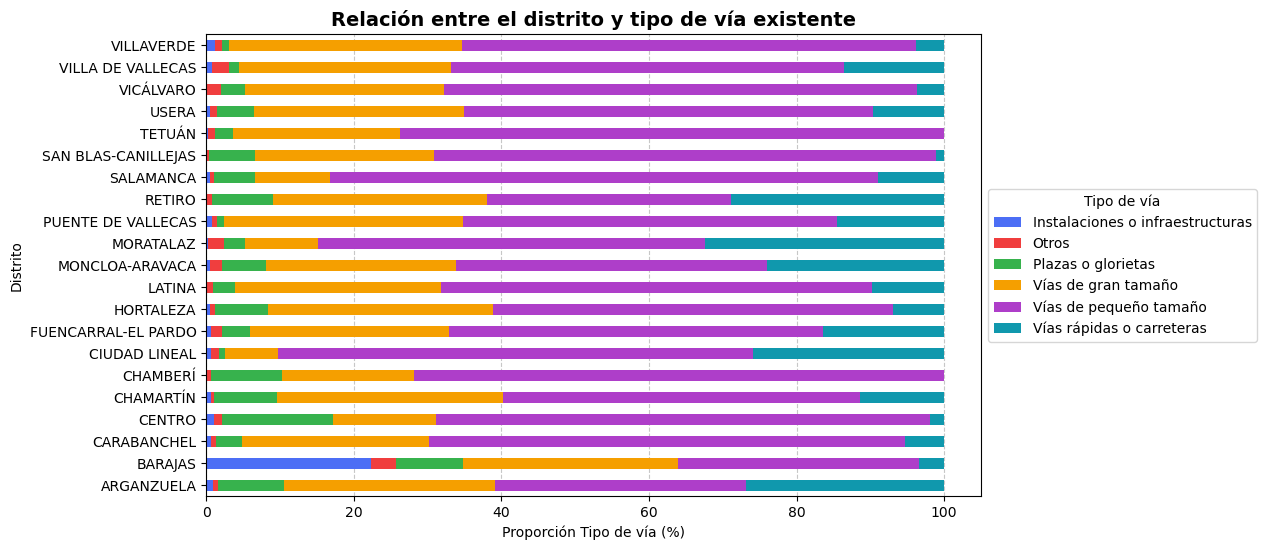

In [85]:
db_plot_bar_distrito_via = db.groupby(['distrito', 'tipo_via'], observed=False).size().unstack().fillna(0)
db_plot_bar_distrito_via_porcentaje = db_plot_bar_distrito_via.div(db_plot_bar_distrito_via.sum(axis=1), axis=0) * 100
ax = db_plot_bar_distrito_via_porcentaje.plot.barh(figsize=(10, 6), stacked=True, color=['#4C6EF5','#F03E3E','#37B24D','#F59F00','#AE3EC9','#1098AD'])
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_title('Relación entre el distrito y tipo de vía existente', fontsize=14, fontweight='bold')
ax.set_xlabel('Proporción Tipo de vía (%)')
ax.set_ylabel('Distrito')
ax.legend(title='Tipo de vía', loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

Como podemos observar en el gráfico, la mayor parte de accidentes ocurridos en los distritos de Vicálvaro y Villa de Vallecas (en los que el porcentaje de accidentes con lesividad más alta es mayor) se producen en vías de pequeño tamaño y no en vías de gran tamaño, lo que invalida la hipótesis previamente planteada sobre la relación entre el porcentaje de accidentes graves y la tipología de la vía o su velocidad de circulación. Podemos sugerir por tanto, que esta mayor lesividad en estos distritos es debida a otro tipo de factores locales desconocidos que aumentan la gravedad en accidentes donde, a priori, el riesgo de lesiones debería ser menor. Para identificar estos factores locales, como mala señalización o visibilidad en determinados cruces o mayor tránsito de peatones por cercanía de colegios, sería necesario realizar un análisis más detallado de las zonas más conflictivas.

Ahora vamos a realizar un análisis de la densidad de accidentes en Madrid, para desvelar la existencia de puntos concretos del municipio en el que se concentre mayor número de accidentes:

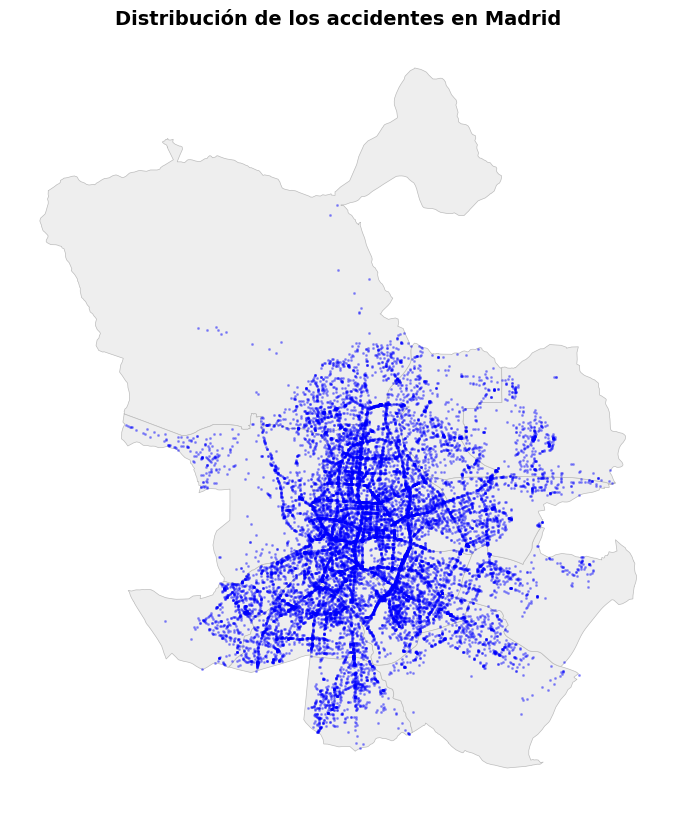

In [86]:
# Creamos un geoDataFrame en el que la columna geometry viene dada por las coordenadas UTM en el sistema de metros EPSG:25830, que es el que traen
db_accidentes_metros = gpd.GeoDataFrame(db_accidentes, geometry=gpd.points_from_xy(db_accidentes['coordenada_x_utm'], db_accidentes['coordenada_y_utm']), crs="EPSG:25830")

# Convertimos los accidentes a coordenadas en grados (EPSG:4326) para que coincidan con las coordenadas del mapa de distritos
db_accidentes_grados = db_accidentes_metros.to_crs(epsg=4326)


fig, ax = plt.subplots(figsize=(12, 10))

# Dibujamos en mapa de distritos con un color gris clarito y con los bordes de los distritos en un gris más oscuro para que se vean mejor
db_distritos.plot(ax=ax, color='#eeeeee', edgecolor='#bcbcbc', linewidth=0.5)

# Dibujamos los puntos con las coordenadas ya convertidas a grados para que coincidan con las del mapa de distritos. Los puntos son de color azul y con transparencia de alpha=0.3 para que donde haya
# varios puntos se vea más oscuro 
db_accidentes_grados.plot(ax=ax, color='blue', markersize=1.4, alpha=0.3)


ax.set_title('Distribución de los accidentes en Madrid', fontsize=14, fontweight='bold')
ax.axis('off')
plt.show()

Como cabía esperar, los puntos con mayor densidad de accidentes se encuentran situados en las vías de gran tamaño de mayor intensidad de tráfico, concentrados sobre todo en la zona centro y sur - sureste del municipio. Observamos que concretamente en los distritos de Vicálvaro y Villa de Vallecas, aunque la densidad de accidentes es menor que en los distritos Centro o Salamanca, presentan una mayor proporción de accidentes graves, lo que refuerza la idea de que a pesar de que se da un menor número de accidentes en general, hay ciertos factores, desconocidos con los datos de que disponemos, que hacen que su nivel de lesividad sea mayor.

A continuación vamos a abordar el análisis geográfico por distritos de los tipos de accidente, pero en este caso vamos a representar el tipo de accidente que más se repite dentro de cada distrito, es decir, su moda:

In [87]:
# Vamos a realizar un procedimiento análogo al realizado para el porcentaje de lesividad, en este caso calculando el tipo de accidente más frecuente (moda) agrupada por distrito:
tipo_accidente_distrito = db_accidentes.groupby('distrito')['tipo_accidente'].agg(lambda x: x.mode()[0]).reset_index()
db_tipo_distrito = db_distritos.merge(tipo_accidente_distrito, left_on='DISTRI_MT', right_on='distrito')

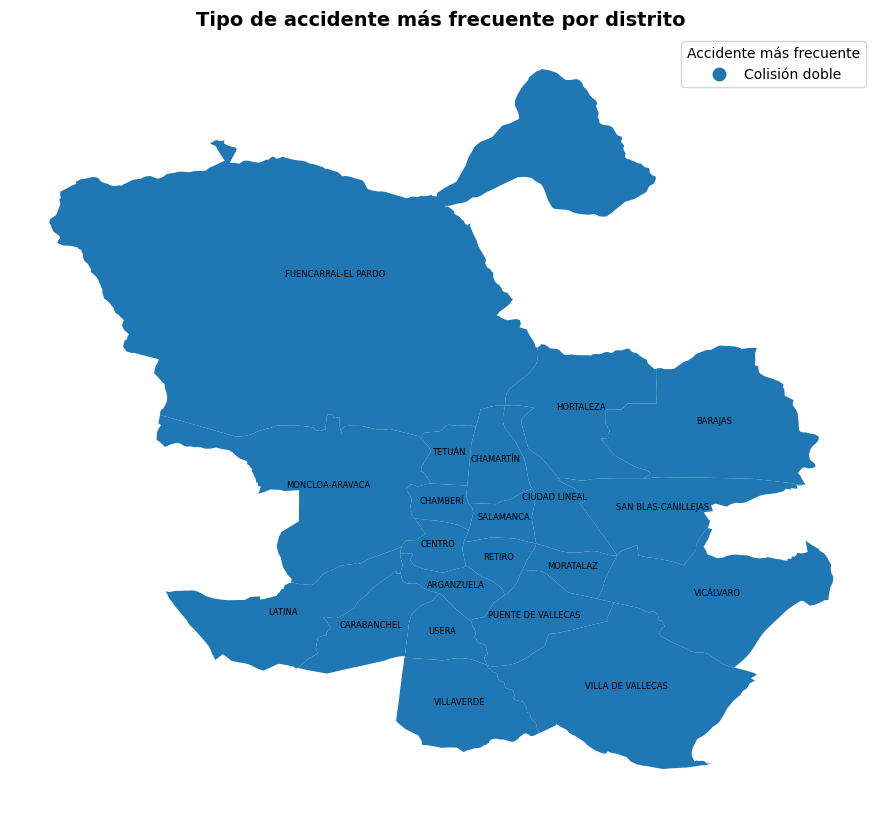

In [88]:
# Ahora dibujamos el mapa. Con el argumento categorical = True le decimos a geoPandas que las etiquetas que estamos intentando representar son una variable categórica y no un grado en una escala, con
# lo que asignamos un color distinto a cada categoría y no una escala degrada de un color:
ax = db_tipo_distrito.plot(column='tipo_accidente', figsize=(12, 10), legend=True, cmap='tab10', categorical = True, legend_kwds={'title': 'Accidente más frecuente'})
ax.set_title('Tipo de accidente más frecuente por distrito', fontsize=14, fontweight='bold')
ax.set_axis_off()

for x, row in db_distritos_lesividad.iterrows():
    ax.annotate(row['DISTRI_MT'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), ha='center', fontsize=6)

plt.show()

En el mapa podemos observar que en todos los distritos el tipo de accidente más frecuente es la colisión doble. Es un resultado coherente, ya que según vimos en el análisis univariado del tipo de accidente, la colisión doble es el de mayor frecuencia absoluta, con más de un 40 % del total de los siniestros producidos.

Para terminar con nuestro análisis y pasar al apartado de conclusiones finales, vamos a explorar la relación entre una tasa de alcohol positiva y factores humanos como el sexo y rango de edad y la misma variable 'positiva_alcohol' y tipo de accidente y la franja horaria en que se produces, factores externos.

Como ya vimos en el análisis univariado, la variable 'positiva_alcohol' presenta un fuerte sesgo hacia el negativo, con sólo un 2.93 % de positivos por lo que para su análisis en relación con las variables que hemos comentado, vamos a centrarnos únicamente en lo que ocurre en esos positivos, que suponen únicamente 1433 registros del total del dataset:

In [89]:
db_alcohol = db[db['positiva_alcohol'] == 'S']

In [90]:
db_alcohol.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1433 entries, 20 to 49326
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   num_expediente        1433 non-null   object        
 1   fecha                 1433 non-null   datetime64[ns]
 2   hora                  1433 non-null   object        
 3   cod_distrito          1433 non-null   int64         
 4   distrito              1433 non-null   object        
 5   tipo_accidente        1433 non-null   object        
 6   estado_meteorologico  1433 non-null   object        
 7   tipo_vehiculo         1433 non-null   object        
 8   tipo_persona          1433 non-null   object        
 9   rango_edad            1433 non-null   category      
 10  sexo                  1433 non-null   object        
 11  coordenada_x_utm      1433 non-null   float64       
 12  coordenada_y_utm      1433 non-null   float64       
 13  positiva_alcohol     

In [91]:
# Vamos a realizar una tabla pivotante para ver en qué categorías de edad y sexo son más frecuentes los positivos en alcohol:
result = pd.pivot_table(data = db_alcohol, index = 'sexo', columns = 'categoria_edad', values = 'positiva_alcohol', aggfunc = 'count', observed=False)

# Al graficar sale por defecto la columna 'Desconocido' (con un conteo a 0) en las categorías de edad porque al hacer el pivot_table de pandas por defecto incluye todas las etiquetas presentes en 
#'categoría_edad' del DataFrame db_alcohol, así que vamos a eliminarla para no 'ensuciar' nuestro mapa de calor, con el argumento errors='ignore' para que no de error:
result = result.drop(columns='Desconocido', errors='ignore')

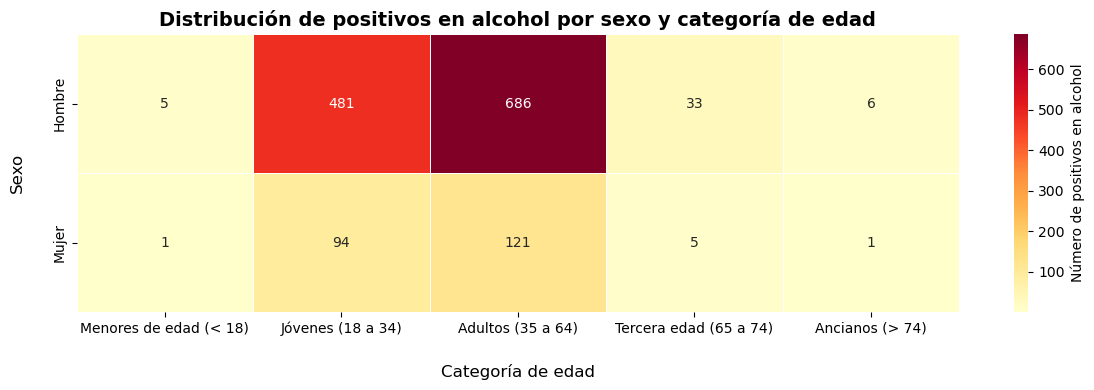

In [92]:
# Graficamos con un mapa de calor de seaborn, en el que mostramos el conteo con el argumento fmt='g', el mapa de colores cmap='YlOrRd' que es una paleta de colores secuencial que va del amarillo para los
# valores más bajos hasta el rojo intenso para los valores más altos, linewidths separa un poco visualmente las celdas y cbar_kws para ponerle una etiqueta a la barra con la escala de colores:

plt.figure(figsize=(12, 4))
sns.heatmap(result, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Número de positivos en alcohol'})
plt.title('Distribución de positivos en alcohol por sexo y categoría de edad', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de edad', fontsize=12, labelpad=20)
plt.xticks(rotation=0)
plt.ylabel('Sexo', fontsize=12, labelpad=20)
plt.tight_layout()
plt.show()

Podemos observar en el gráfico que los positivos en alcohol registrados en los accidentes se producen de forma notablemente mayoritaria en hombres y más concretamente en hombres adultos de entre 35 a 64 años, seguidos de los jóvenes de 18 a 34 años, estando el resto de grupos de edad representados de forma marginal. Estos resultados están estrechamente ligados con las tendencias generales en cuanto al consumo de alcohol se refiere y sus características socio-culturales, además de ser consistentes con los resultados recogidos en el análisis univariado de los accidentes por sexo y categoría de edad, en el que observamos que un 61 % de los implicados en accidentes son hombres y más de un 50 % son adultos con edades comprendidas entre los 35 a los 64 años.

En términos relativos, tenemos que de las personas implicadas en un accidente de tráfico que dan positivo en un test de alcoholemia un 81.50 % son hombres, siendo de estos un 56.65 % adultos y un 39.72 % jóvenes.
 
Por otra parte, observamos que no existen positivos en las categorías 'Desconocido' de las variables 'sexo' y 'categoría_edad' lo que consolida la hipótesis planteada en el presente EDA sobre la naturaleza de estos datos indeterminados, de que se trata de personas que se dieron a la fuga en el momento del accidente por lo que no se les pudo realizar ningún control de alcoholemia in situ.

Continuamos con los factores externos que pueden influir en una tasa de alcoholemia positiva:

In [93]:
# Vamos a realizar una tabla pivotante para ver en qué categorías de edad y sexo son más frecuentes los positivos en alcohol:
result_ext = pd.pivot_table(data = db_alcohol, index = 'franja_horaria', columns = 'tipo_accidente', values = 'positiva_alcohol', aggfunc = 'count', observed=False)

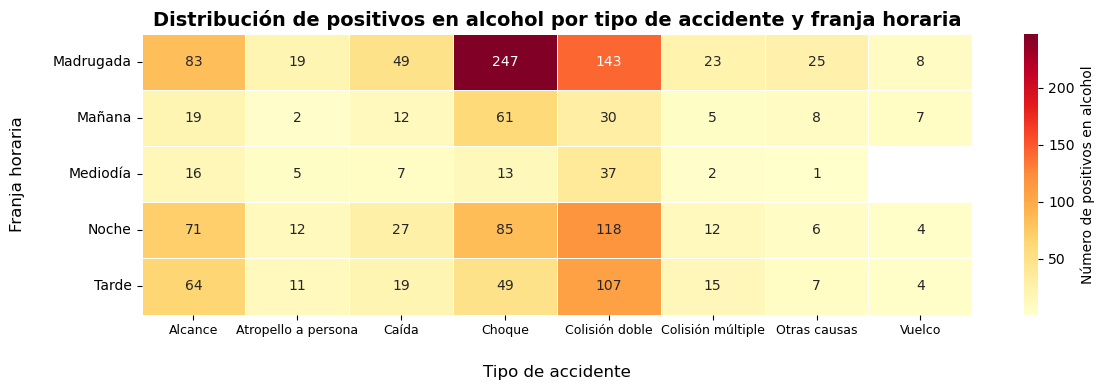

In [94]:
plt.figure(figsize=(12, 4))
sns.heatmap(result_ext, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Número de positivos en alcohol'})
plt.title('Distribución de positivos en alcohol por tipo de accidente y franja horaria', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de accidente', fontsize=12, labelpad=20)
plt.xticks(rotation=0, fontsize=9, ha='center')
plt.ylabel('Franja horaria', fontsize=12, labelpad=20)
plt.tight_layout()
plt.show()

En el gráfico vemos como el mayor número de positivos en el test de alcoholemia se produce durante la madrugada (con un 41,66 % de los positivos por franjas horarias), principalmente en los choques, seguidos de las colisiones dobles, con unos porcentajes del 17.24 % y un 9.98 % de los positivos, respectivamente. El resultado es previsible, ya que es durante la madrugada cuando mayor es el consumo de alcohol debido a las dinámicas de ocio nocturno existentes.

Es interesante también señalar el pico de positivos que se da durante la tarde y la noche (también en choques y colisiones dobles), que presumiblemente pueden deberse a accidentes que se dan en los desplazamientos después de comidas y cenas en las que suele producirse una ingesta de alcohol importante.

Como pudimos observar en los análisis realizados a lo largo de este EDA, si bien la franja horaria donde se produce un menor número absoluto de accidentes es la madrugada, ésta presenta a su vez un nivel de lesividad más alto que el resto de franjas horarias (siempre considerando el sesgo detectado en cuanto al número de registros existentes, significativamente inferior al resto de franjas), lo que inicialmente podría parecer relacionado con esta mayor tasa de positividad en alcohol detectada, si bien el análisis bivariado entre positividad en alcohol y nivel de lesividad realizado anteriormente no muestra diferencias significativas entre ambos grupos, por lo que esta relación no puede confirmarse con los datos disponibles.

## 6. Conclusiones

Para dar por finalizado nuestro análisis, vamos a intentar dar respuesta a las preguntas de negocio planteadas al inicio, así como destacar algunos hallazgos observados que nos parecen de especial interés.

A la pregunta **¿en qué franja horaria se producen accidentes con mayor gravedad?**, podríamos concluir que es durante la **madrugada** (de 00:00 a 06:00 h.) cuando se producen los accidentes con mayor gravedad, o lo que es lo mismo, con un nivel de lesividad igual a 2 en nuestro trabajo (lo que incluye heridos con un ingreso hospitalario con una duración superior a 24 horas o bien fallecidos). Sin embargo, como hemos comentado en varias ocasiones a lo largo del análisis, este resultado debe ser recibido con cautela, ya que hay que tener en cuenta que el bajo número de accidentes producidos durante la madrugada hace que el porcentaje sea más sensible a variaciones y además, las diferencias porcentuales en el nivel más alto de lesividad entre las diferentes franjas horarias son mínimas, por lo que el efecto del número absoluto de accidentes es aún más significativo.

Por otra parte, con respecto a **¿qué condiciones concretas pueden influir en una alta lesividad?**, durante nuestra exploración, hemos observado que las variables más determinantes en una lesividad mayor son:

- **Tipo de vehículo siniestrado**: observamos que los vehículos asociados a una mayor gravedad en los accidentes y también en los de un nivel de lesividad leve son las motocicletas/ciclomotores, con un 5,1 % de personas involucradas con un nivel de lesividad grave y un 64,5 % de implicados con nivel de lesividad leve, seguidos de las bicicletas/ciclos/patinetes (3,5 % para implicados con nivel grave), concluyendo que los accidentes en los que se ven involucrados turismos presentan un menor nivel de lesividad grave y que los usuarios de motocicletas/ciclomotores son los que tienen mayor riesgo de sufrir accidentes con nivel de lesividad grave.

- **Tipo de accidente**: el atropello es, con un porcentaje del 6 % (significativamente superior al resto), el tipo de accidente que mayor lesividad produce en los involucrados, seguido de las caídas (motocicletas, bicicletas, patinetes,...) con un 3.1 %, siendo este último un resultado coherente con lo observado para los tipos de vehículo.

- **Tipo de persona**: la mayor proporción de personas accidentadas con un nivel de lesividad más alto se concentra en los peatones, con un 11,1 % de graves/fallecidos. Este resultado es perfectamente consistente con el arrojado en el análisis bivariado del tipo de accidente con el nivel de lesividad, en el que se mostraba una mayor proporción de nivel de lesividad grave/fallecido en los atropellos, siendo los peatones los más vulnerables en este tipo de siniestros.

- **Rango de edad**: la proporción del nivel de lesividad más alto se produce entre los ancianos mayores de 74 años (un 4,3 %), seguidos de los integrantes del grupo de la tercera edad (entre 65 y 74 años), mostrando el resto de grupos de edad una proporción de lesividad alta muy similar entre sí. Observamos también que esa franja de edad es también en la que se producen más atropellos, lo que afianza la idea de los ancianos como el grupo con mayor riesgo de sufrir un accidente grave.

Otra variable que posee cierta relevancia para la lesividad es el **estado meteorológico** en el momento del accidente. Hemos observado que aunque el mayor número de accidentes se produce en condiciones climáticas favorables, es con meteorología adversa (en concreto, lluvia intensa y lluvia débil) cuando se producen accidentes con un nivel medio de lesividad mayor. Sin embargo, con respecto a los accidentes graves, observamos que curiosamente los niveles de lesividad más altos se producen en climas nublados y despejados. Si bien estos resultados son interesantes, **no destaca como un factor determinante** en la alta lesividad en comparación con otras variables analizadas.

Por último, como cierre de nuestro análisis, caben destacar algunas **revelaciones interesantes** derivadas de la exploración realizada. Por un lado, hemos concluido que a pesar de lo que a priori pudiera parecer, de los datos de que disponemos **no se puede inferir que exista una relación directa entre los positivos registrados en los test de alcoholemia y un nivel de lesividad alto**, ya que su distribución es considerablemente homogénea en los casos positivos y negativos. De igual manera y por el mismo motivo, **tampoco** podemos afirmar que exista una **correlación entre el sexo y una proporción alta de accidentados graves**, ya su distribución es también muy similar en ambos sexos.

En segundo lugar, tanto en la variable 'sexo' como en 'categoria_edad' nos encontramos con una **etiqueta 'Desconocido'** que supone en ambos casos un porcentaje relevante del dataset. En ambos casos, de sus análisis bivariados hemos podido extraer que en este grupo no hay ningún accidente grave o con resultado de muerte y que además presenta el mayor porcentaje de choques y colisiones múltiples de todas las categorías registradas, lo que daría consistencia a la **hipótesis planteada** en el análisis univariado que estos datos desconocidos en ambas variables se deban a **fugas producidas tras el accidente**. 

En tercer lugar, comentar el caso concreto de las franjas horarias y tipos de vía y su relación con los niveles altos de lesividad. A pesar de que en ambos no se ha encontrado una correlación especialmente intensa entre ambas variables, sí que existen hallazgos interesantes a destacar, como son en el caso de la franja horaria una **aparente relación inversa entre el número de accidentes producidos y nivel de lesividad máxima por franja horaria**, es decir, para cada franja horaria, a menor número de accidentes producidos, mayor porcentaje de accidentes graves y/o fallecidos, si bien hay que tener en cuenta el sesgo existente en cuanto el número de registros presentes en el dataset correspondientes a esta franja horaria que ya comentamos a la hora de responder a la primera pregunta de negocio.

En el caso de los tipos de vía y en concreto las **plazas o glorietas** en comparación con las vías rápidas nos encontramos con un hallazgo a priori anómalo: la **lesividad** en las primeras es **ligeramente superior** que en las segundas a pesar de que la velocidad de circulación en las vías rápidas es significativamente superior. En el análisis bivariado ya conjeturamos que esta anomalía **podía deberse a los propios patrones de circulación** que se dan en las glorietas. Sin embargo, al igual que al analizar las franjas horarias en el caso de las plazas y glorietas nos encontramos también con un bajo número de registros, lo que hace que los diferentes porcentajes sean más sensibles a variaciones y además, las diferencias porcentuales en el nivel más alto de lesividad entre las distintas categorías de vías son mínimas, por lo que el efecto del número total de registros es aún más importante.

Por último, en cuanto al **análisis geográfico realizado**, cabe destacar que si bien **Vicálvaro y Villa de Vallecas** no son los distritos con mayor densidad de accidentes, presentan una mayor proporción de accidentes graves, lo que dota de mayor peso a la teoría planteada de que **existen ciertos factores, desconocidos** con los datos de que disponemos, que hacen que su **nivel de lesividad sea mayor**.

# Modelo de Regresión Logística: predicción de positividad en test de alcoholemia en accidentes de tráfico en Madrid

Nuestra finalidad una vez realizado el EDA es la implementación de un **modelo de regresión logística que prediga si un implicado en un accidente va a resultar positivo o no en un test de alcoholemia**. Para ello, el primer paso es la definición de nuestra **variable objetivo**, que es **'positiva_alcohol'**. Al tratarse ésta de una variable categórica de tipo binario, debemos convertirla primero a numérica para su correcto procesamiento por parte del modelo:

In [95]:
db['positiva_alcohol'] = np.where(db['positiva_alcohol'] == 'S', 1, 0)
db['positiva_alcohol'].value_counts()

positiva_alcohol
0    47384
1     1433
Name: count, dtype: int64

Para la realización del modelo vamos a utilizar la librería de Python Scikit-learn, por lo que vamos a importar las funciones que vamos a necesitar de esa librería:

In [96]:
from sklearn.model_selection import train_test_split


A continuación vamos a seleccionar las **variables** que consideramos **más determinantes para la predicción** que queremos realizar. Basándonos en los resultados obtenidos en la exploración de los datos realizada, podemos inferir que la **franja horaria**, el **tipo de accidente**, el **sexo**, el **rango de edad**, el **tipo de vehículo ('categoria_vehiculo')**, **fecha** y **distrito** son a priori las variables más relevantes para la predicción de nuestro dataset. En el EDA realizado pudimos ver que la franja horaria, el sexo y el rango de edad ('categoria_edad') son variables especialmente relacionadas con la positividad en alcoholemia. En relación a la fecha, es sabido que los patrones de consumo son diferentes en fin de semana y en días laborables, y si unimos esto con lo que ya sabemos de la mayor positividad en alcohol durante las madrugadas parece razonable utilizar esta variable para nuestro modelo. En el análisis geográfico vimos que los distritos presentan distintos patrones de distribución de accidentes y lesividad, lo que puede estar relacionado con la existencia de zonas de ocio nocturno y patrones de distribución poblacional que pueden influir en la positividad en alcoholemia.

Todas estas variables escogidas son de tipo categórico, por lo que para su correcta integración en el modelo necesitamos codificarlas para su conversión a variables numéricas, que son las que acepta el modelo de regresión logística. Además, en el caso de 'fecha' vamos a crear una nueva variable 'fin_de_semana' que es la que en realidad usaremos para el modelo que contengan valores binarios de si la fecha concreta en la que ocurrió el accidente era fin de semana o no (1 para sí era fin de semana, es decir, sábado o domingo, o 0 para el resto de días):

In [97]:
# dayofweek devuelve un número según el día de la semana: 0 apara el lunes, 1 para el martes,..., por lo que sábado y domingo se corresponden con el 5 y 6, por lo que ahora tenemos una nueva variable
# 'fin_de_semana' es booleana conteniendo valores 'True' si la fecha en concreto es fin de semana o 'False' si es un día laborable:
db['fin_de_semana'] = db['fecha'].dt.dayofweek >= 5

# Convertimos a binaria, donde True es igual a 1 y False es igual a 0
db['fin_de_semana'] = np.where(db['fin_de_semana'], 1, 0)
db['fin_de_semana'].value_counts()

fin_de_semana
0    36670
1    12147
Name: count, dtype: int64

Del resto de variables predictoras que tenemos, 'categoria_edad' es una variable de tipo ordinal, por lo que para conservar su orden interno vamos a implementar una transformación customizada con .map(). En esta variable (al igual que en 'sexo') nos encontrábamos con un número importante de 'Desconocido' que en el EDA mantuvimos a efectos de análisis debido al alto número registros que suponía y a la imposibilidad de una imputación fiable sin sesgos importantes. En el caso de la implementación del modelo, creemos que el mantenimiento de esta categoría introduciría ruido en lugar de ser útil, debido a que se trata de registros con un comportamiento diferente al de otros grupos de edad, ya que tal y como hipotetizamos durante la exploración de los datos podrían estar relacionados con fugas producidas en el momento del accidente, y por lo tanto no añadirían un valor predictivo al modelo sino confusión.

Esta reflexión es igualmente válida para la variable 'sexo' por los mismos motivos, por lo que antes de continuar con la codificación de las distintas variables vamos a crear una copia del DataFrame eliminando los registros con etiqueta 'Desconocido' en las columnas 'categoria_edad' y 'sexo' que será el que utilicemos para la implementación del modelo.

In [98]:
# Creamos una copia del dataframe original con nombre db_modelo eliminando los registros en los que aparezca 'Desconocido' en las columnas 'categoria_edad y 'sexo':
db_modelo = db[(db['categoria_edad'] != 'Desconocido') & (db['sexo'] != 'Desconocido') ].copy()

# Vemos que se hayan eliminado los desconocidos correctamente de ambas columnas en db_modelo:
db_modelo['categoria_edad'].value_counts()

categoria_edad
Adultos (35 a 64)         24720
Jóvenes (18 a 34)         14473
Tercera edad (65 a 74)     1897
Menores de edad (< 18)     1671
Ancianos (> 74)            1203
Desconocido                   0
Name: count, dtype: int64

In [99]:
db_modelo['sexo'].value_counts()

sexo
Hombre    29712
Mujer     14252
Name: count, dtype: int64

In [100]:
# Creamos el diccionario con los valores numéricos que vamos a asignar a cada categoría_edad:
orden_edad = {
    'Menores de edad (< 18)': 1,
    'Jóvenes (18 a 34)': 2,
    'Adultos (35 a 64)': 3,
    'Tercera edad (65 a 74)': 4,
    'Ancianos (> 74)': 5
}

# Mapeamos toda la columna 'categoria_edad' para asignar los valores':
db_modelo['categoria_edad'] = db_modelo['categoria_edad'].map(orden_edad)

In [101]:
db_modelo['categoria_edad'].value_counts()

categoria_edad
3.0    24720
2.0    14473
4.0     1897
1.0     1671
5.0     1203
Name: count, dtype: int64

In [102]:
# Ahora vamos a convertir en una variable numérica a la variable 'sexo' de forma análoga a lo realizado con 'positiva_alcohol', asignándole el valor 1 a la categoría 'Hombre' (porque como vimos en el EDA
# es la más frecuente con un 61 % del total de registros) y 0 a 'Mujer':
db_modelo['sexo'] = np.where(db_modelo['sexo'] == 'Hombre', 1, 0)

In [103]:
db_modelo['sexo'].value_counts()

sexo
1    29712
0    14252
Name: count, dtype: int64

A continuación vamos a elegir la codificación más adecuada para el resto de variables predictoras que hemos elegido, que son 'franja_horaria', 'tipo_accidente', 'categoria_vehiculo' y 'distrito'. Todas ellas son variables categóricas nominales que no tienen ningún orden preestablecido y presentan múltiples etiquetas por lo que la codificación más adecuada de Scikit-learn en este caso es OneHotEncoder, que crea una columna binaria (0/1) para cada etiqueta dentro de cada categoría, mientras que LabelEncoder asigna números aleatorios a cada categoría lo que el modelo podría interpretar como un orden interno que no es real. Con OneHotEncoder por tanto conseguimos eliminar cualquier orden implícito (aunque sea aleatorio).

In [104]:
# Importamos el codificador OneHotEncoder de la libería:
from sklearn.preprocessing import OneHotEncoder

# Creamos la lista de variables nominales que queremos codificar:
lista_var_nom = ['franja_horaria', 'tipo_accidente', 'categoria_vehiculo', 'distrito']

# Creamos un diccionario en que vamos a guardar todas las conversiones realizadas para volver a usarlas si fuera necesario:
dicc_ohe = {}

# Implementamos un bucle para ir guardando en el diccionario creado todas las conversiones:
for var_nom in lista_var_nom:
    # Creamos y entrenamos el codificador para cada variable. El argumento drop='first' es para evitar duplicados. Por ejemplo para franja_horaria sin en drop se crearían 5 columnas para cada categoría de
    # franja-horaria, y con drop='first' elimina la primera, si las otras 4 tienen un valor 0, el codificador sabe que el valor 1 queda en la que falta. Con las 5 columnas el modelo tendría información
    # redundante. El argumento sparse_output=False hace que la matriz devuelta por OneHotEncoder sea una matriz normal (de 0 y 1) y no una matriz dispersa (donde solo se guardan los 1, opción por defecto), 
    # lo que hace que luego podamos convertirlo a un DataFrame de pandas y operar con él.
    ohe = OneHotEncoder(drop='first', sparse_output=False)
    # Realizamos las codificaciones de las columnas (usamos [[]] para que sea una matriz y una columna porque OneHotEncoder sólo admite matrices):
    matriz_transformaciones = ohe.fit_transform(db_modelo[[var_nom]])
    # Generamos los nombres de las nuevas columnas creadas, como por ejemplo franja_horaria_Mañana:
    nombres = ohe.get_feature_names_out([var_nom])
    # Creamos un nuevo DataFrame temporal con las transformaciones y los nombres de las nuevas columnas, con index=db_modelo.index mantenemos la alineación de las filas que teníamos en nuestro db_modelo:
    db_modelo_temporal = pd.DataFrame(matriz_transformaciones, columns=nombres, index=db_modelo.index)
    # Unimos al DataFrame db_modelo las nuevas columnas y eliminamos las columnas originales de texto que ya no son de utilidad para el modelo:
    db_modelo = pd.concat([db_modelo.drop(columns=[var_nom]), db_modelo_temporal], axis=1)
    # Guardamos cada objeto creado en el diccionario:
    dicc_ohe[var_nom] = ohe

In [105]:
db_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43964 entries, 0 to 49339
Data columns (total 53 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   num_expediente                                  43964 non-null  object        
 1   fecha                                           43964 non-null  datetime64[ns]
 2   hora                                            43964 non-null  object        
 3   cod_distrito                                    43964 non-null  int64         
 4   estado_meteorologico                            43964 non-null  object        
 5   tipo_vehiculo                                   43964 non-null  object        
 6   tipo_persona                                    43964 non-null  object        
 7   rango_edad                                      43964 non-null  category      
 8   sexo                                            439

Una vez definida nuestra variable objetivo, y establecidas y codificadas nuestras variables predictoras vamos a declarar las variables 'X' e 'y' que empleará nuestro modelo:

In [106]:
y = db_modelo['positiva_alcohol'].copy(deep = True)

# Para X como hemos creado una cantidad considerable de nuevas columnas con la codificación lo que hacemos es asignarle el DataFrame db_modelo pero eliminando las variables que no consideramos útiles para
# el modelo:
X = db_modelo.drop(columns=['positiva_alcohol', 'num_expediente', 'fecha', 'hora', 'cod_distrito', 'estado_meteorologico', 'tipo_vehiculo', 'tipo_persona', 'rango_edad', 'coordenada_x_utm', 
'coordenada_y_utm', 'hora_numero', 'tipo_via', 'nivel_lesividad'], errors='ignore').copy(deep=True)

El siguiente paso para la creación de nuestro modelo es la división del dataset en los conjuntos de entrenamiento (train) y prueba (test). Durante el análisis exploratorio, pudimos observar que nuestra variable objetivo 'y' ('positiva_alcohol') se encuentra fuertemente sesgada hacia el no, resultando positivos únicamente un 2,93 % de los test de alcoholemia realizados. Por tanto, para asegurarnos de que ambos conjuntos contengan la misma proporción de positivos y negativos y de que en el de entrenamiento estén suficientemente representados los positivos y el de prueba sea suficientemente representativo, vamos a utilizar el argumento 'stratify = y':

In [107]:
# Dividimos el dataset en los conjuntos de entrenamiento y prueba, en este caso en una proporción de 80-20 (test_size = 0.2) y con muestreo estratificado para la variable objetivo 'y' (stratify = y). Además
# con el argumento random_state = 42 nos aseguramos que los resultados sean reproducibles para cualquier persona que ejecute el código, ya que siempre se producirá la misma división del conjunto 

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42, stratify = y)

A continuación importamos la clase AlcoholLogisticModel que hemos implementado en el script 'models.py', la instanciamos, entrenamos el modelo con nuestros datos de entrenamiento y por último visualizamos las métricas aplicadas al modelo:

Recall: 0.7504
F1-score: 0.1744


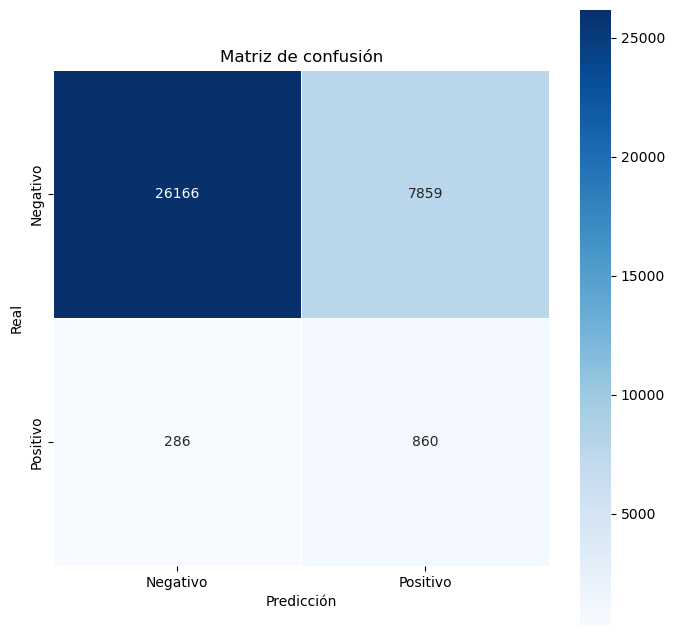

In [108]:
from models import AlcoholLogisticModel

modelo = AlcoholLogisticModel()
modelo.fit(X_train, y_train)
predicciones_entrenamiento = modelo.predict(X_train)
modelo.evaluate(X_train, y_train)

Como podemos observar en las métricas obtenidas del modelo sobre los datos de entrenamiento, obtenemos un recall bastante aceptable de 0.7504, lo que significa que el modelo está identificando correctamente un 75,04 % de los positivos en alcohol. Sin embargo, el F1-score obtenido (0.1744) es bajo, lo que significa que tiene una precisión baja. En la matriz de confusión podemos ver que el modelo ha identificado como positivos a 7859 negativos reales, o sea hay un número elevado de falsos positivos.

Esta tendencia del modelo a sobreclasificar los casos como positivos puede ser consecuencia del argumento class_weight = 'balanced' que establecimos en el init del modelo, ya que quizá le esté otorgando demasiada importancia a los positivos para compensar su bajo número. Vamos a instanciar de nuevo la clase AlcoholLogisticModel con el argumento class_weight= None para no realizar ningún tipo de compensación y vamos a entrenar el modelo y visualizar las métricas para ver qué resultados obtenemos: 

Recall: 0.0183
F1-score: 0.0353


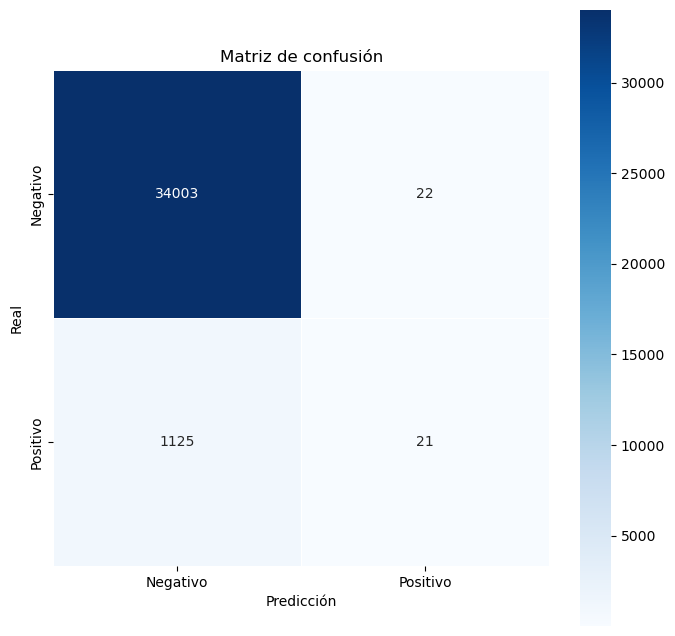

In [109]:
modelo_2 = AlcoholLogisticModel(class_weight=None)
modelo_2.fit(X_train, y_train)
predicciones_entrenamiento_2 = modelo_2.predict(X_train)
modelo_2.evaluate(X_train, y_train)

Como podemos comprobar con las métricas obtenidas, los resultados son mucho peores que con class_weight = 'balanced', por lo que según desprende de estas métricas, es necesario realizar algún tipo de compensación en las clases. En este  caso, vamos a probar una class_weight customizada class_weight={0: 1, 1: 10} en la que le decimos al modelo que cada vez que encontremos un positivo (clase 1), le de 10 veces más peso que a un negativo (clase 0):

Recall: 0.4380
F1-score: 0.2451


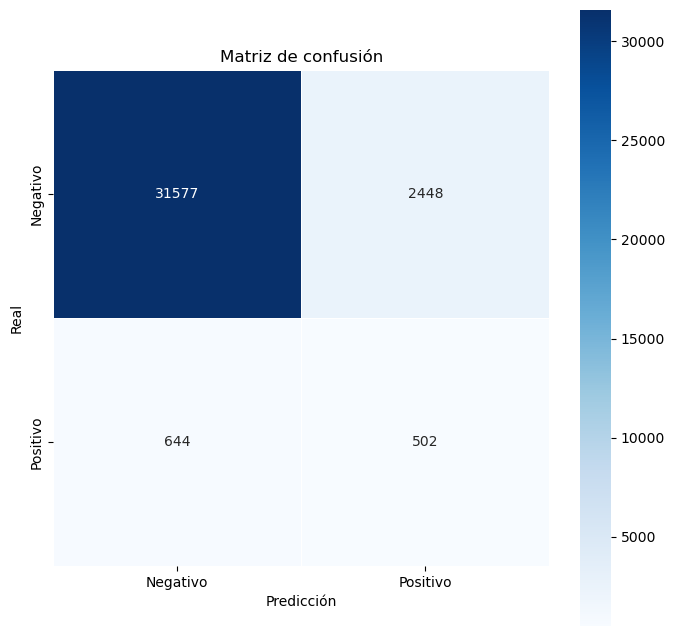

In [110]:
modelo_3 = AlcoholLogisticModel(class_weight={0: 1, 1: 10})
modelo_3.fit(X_train, y_train)
predicciones_entrenamiento_3 = modelo_3.predict(X_train)
modelo_3.evaluate(X_train, y_train)

En esta ocasión, obtenemos unas métricas mejores que con class_weight = None, con un recall de 0.4380 y un F1-score de 0.2451. Si bien el F1-score es mejor que con class_weight = 'balanced' al reducirse el número de falsos positivos, el recall obtenido es significativamente más bajo, lo que implicaría una detección de positivos inferior a lo deseado desde el punto de vista de la seguridad vial, por lo que queda claro que class_weight = 'balanced' es imprescindible en este caso.

A continuación vamos a modificar los hiperparámetros C y solver para ver con ello obtenemos una mejora en las métricas de nuestro modelo. Primero modificaremos la regularización a 0.1 para ver si mejora las métricas:


Recall: 0.7435
F1-score: 0.1738


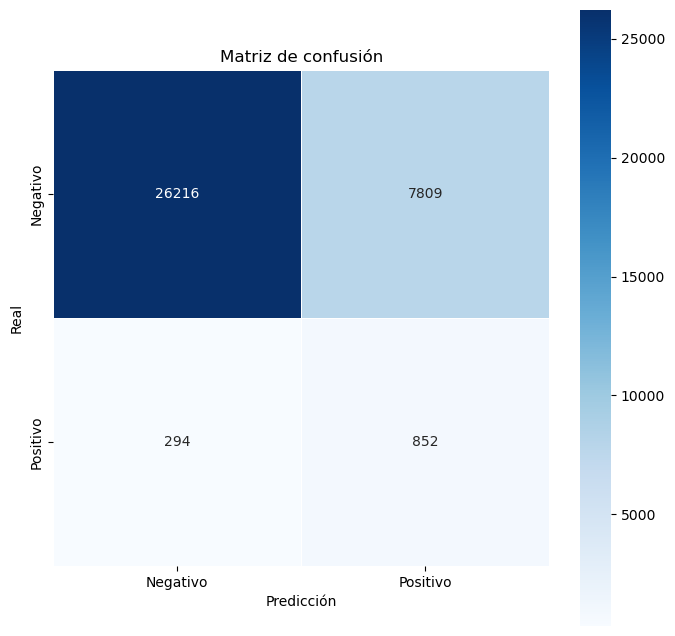

In [111]:
modelo_4 = AlcoholLogisticModel(C=0.1)
modelo_4.fit(X_train, y_train)
predicciones_entrenamiento_4 = modelo_4.predict(X_train)
modelo_4.evaluate(X_train, y_train)

La modificación del hiperparámetro 'C' no ha tenido prácticamente ningún impacto en las métricas de nuestro modelo, habiendo bajado ligerísimamente el recall y el F1-score (al principio con un valor para el recall de 0.7504 y de 0.1744 para el F1-score).

Testearemos a continuación la modificación del hiperparámetro solver con solver = 'saga', que a veces da mejores resultados con datasets desbalanceados:

Recall: 0.6911
F1-score: 0.1696


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


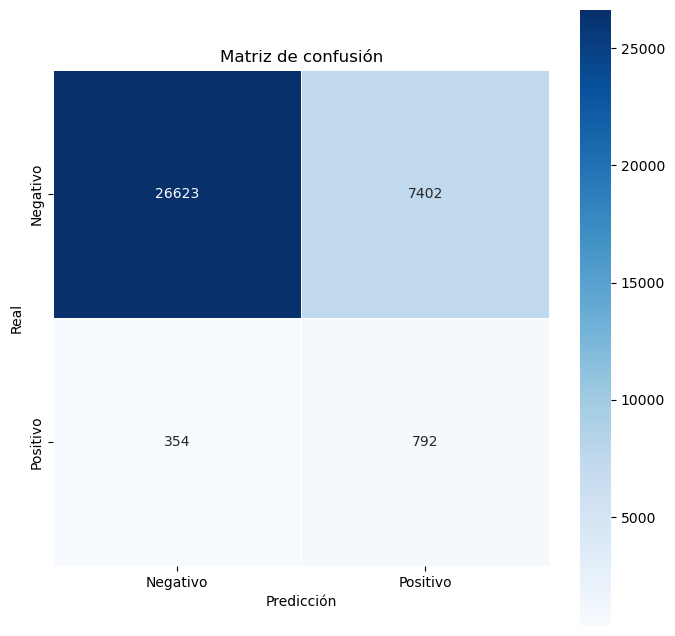

In [112]:
modelo_5 = AlcoholLogisticModel(solver = 'saga')
modelo_5.fit(X_train, y_train)
predicciones_entrenamiento_5 = modelo_5.predict(X_train)
modelo_5.evaluate(X_train, y_train)

Con solver='saga' hemos recibido un warning en que se indica que se ha alcanzado el máximo de iteraciones definido (en este caso max_iter = 1000) sin que el modelo converja, lo que significa que necesita más iteraciones para lograr encontrar los pesos óptimos, así que vamos a aumentar su número:

Recall: 0.8761
F1-score: 0.1297


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


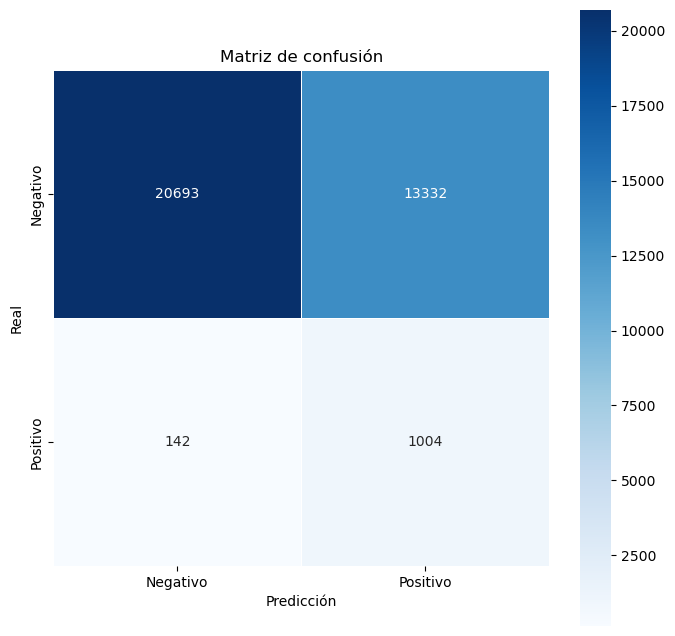

In [113]:
modelo_6 = AlcoholLogisticModel(solver = 'saga', max_iter = 5000)
modelo_6.fit(X_train, y_train)
predicciones_entrenamiento_6 = modelo_6.predict(X_train)
modelo_6.evaluate(X_train, y_train)

Comprobamos que el modelo sigue sin converger, por lo que vamos a dejar el valor de 'solver' por defecto (solver = 'lbfgs') ya que ha demostrado que funcionaba mejor. En este caso con 5000 iteraciones ha conseguido un recall de 0.8761, es decir, que ha identificado correctamente un 87,61 % de los positivos, sin embargo, el F1-score ha caído a 0.1297, porque ha identificado erróneamente como positivos a 13332 positivos (tal y como observamos en la matriz de confusión), un número sustancialmente mayor que el de falsos positivos identificados con solver = 'lbfgs'.

A continuación vamos a probar el modelo con un conjunto de datos de entrada distinto, eliminando la variable 'distrito' que según podemos deducir de la exploración realizada en el EDA es de las que menos relación tiene con nuestra variable objetivo, 'positiva_alcohol'. Por otra parte, al existir 21 distritos diferentes y haber aplicado el OneHotEncoder, se han creado una gran cantidad de nuevas columnas que quizá estén complicando demasiado el modelo y si las eliminamos mejoremos las métricas:

Recall: 0.7321
F1-score: 0.1683


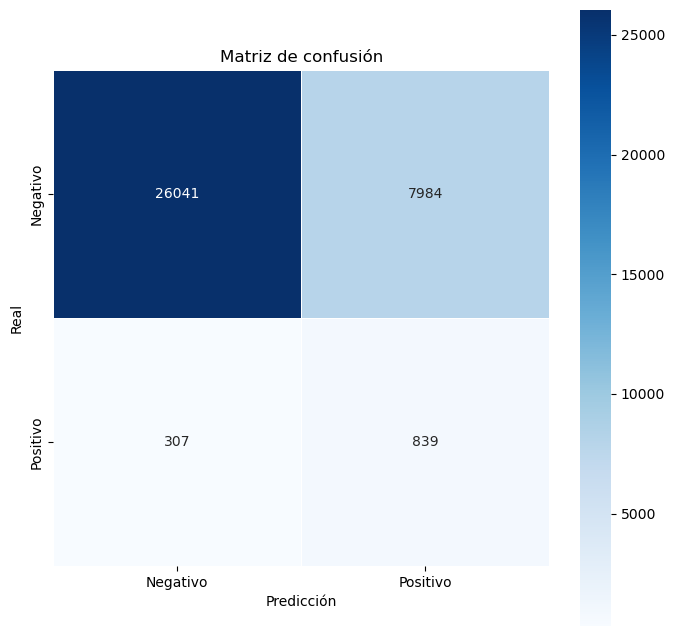

In [114]:
# Vamos a crear un X_train y un X_test eliminando todas las columnas de 'distrito'. Primero creamos una list comprehension para guardar todas esas columnas en una variable:
columnas_a_eliminar = [col for col in X_train.columns if col.startswith('distrito')]
# Hacemos un drop a X_train y X_test quitando esas columnas que empiecen por 'distrito' y lo guardamos en las variables X_train_sin_distrito y X_test_sin_distrito.
X_train_sin_distrito = X_train.drop(columns = columnas_a_eliminar)
X_test_sin_distrito = X_test.drop(columns = columnas_a_eliminar)

# Dejamos los valores de los hiperparámetros por defecto, que son los que a priori han funcionado mejor:

modelo_7 = AlcoholLogisticModel()
modelo_7.fit(X_train_sin_distrito, y_train)
predicciones_entrenamiento_7 = modelo_7.predict(X_train_sin_distrito)
modelo_7.evaluate(X_train_sin_distrito, y_train)

Como podemos observar, las métricas con este conjunto de entrenamiento no son mejores que con el conjunto de entrenamiento establecido originalmente, por lo que podemos inferir que 'distrito' es una variable valiosa para nuestro modelo.

Ahora eliminaremos las columnas relacionadas con la variable 'tipo_accidente' de forma análoga a lo realizado con 'distrito', ya que tras nuestro análisis percibimos que esta variable tiene también menos relación directa con nuestra variable objetivo que otras como 'franja_horaria' o 'sexo':

Recall: 0.7339
F1-score: 0.1615


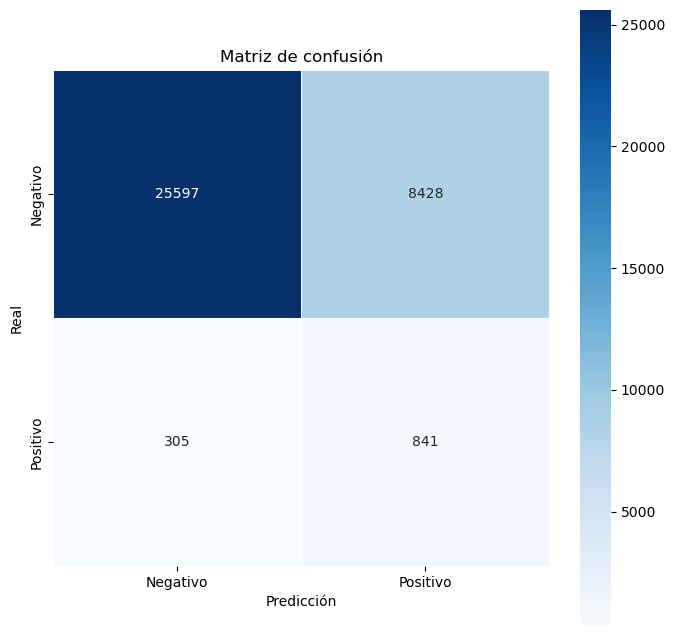

In [115]:
columnas_a_eliminar_2 = [col for col in X_train.columns if col.startswith('tipo_accidente')]
# Hacemos un drop a X_train y X_test quitando esas columnas que empiecen por 'tipo_accidente' y lo guardamos en las variables X_train_sin_acc y X_test_sin_acc.
X_train_sin_acc = X_train.drop(columns = columnas_a_eliminar_2)
X_test_sin_acc = X_test.drop(columns = columnas_a_eliminar_2)

# Dejamos los valores de los hiperparámetros por defecto, que son los que a priori han funcionado mejor:

modelo_8 = AlcoholLogisticModel()
modelo_8.fit(X_train_sin_acc, y_train)
predicciones_entrenamiento_8 = modelo_8.predict(X_train_sin_acc)
modelo_8.evaluate(X_train_sin_acc, y_train)

En este caso, los resultados son muy parecidos a los del modelo entrenado sin las columnas de 'distrito', sin 'tipo_accidente' las métricas son parecidas a las obtenidas con el conjunto de datos original, si bien son ligeramente peores con un recall de 0.7339 y un F1-score de 0.1615 frente al 0.7504 y 0.1744, respectivamente, del modelo original.

A continuación elaboraremos una tabla resumen de todas las pruebas realizadas para poder comparar más fácilmente los resultados obtenidos para los distintos hiperparámetros utilizados:



In [116]:
tabla_resumen = pd.DataFrame({
    'Modelo': ['modelo', 'modelo_2', 'modelo_3', 'modelo_4', 'modelo_5', 'modelo_6', 'modelo_7', 'modelo_8'],
    'Hiperparámetros': [
        'balanced, C=1, lbfgs, max_iter=1000',
        'class_weight=None',
        'class_weight={0:1, 1:10}',
        'balanced, C=0.1, lbfgs',
        'balanced, saga, max_iter=1000',
        'balanced, saga, max_iter=5000',
        'balanced, sin distrito',
        'balanced, sin tipo_accidente'
    ],
    'Recall_train': [0.7504, 0.0183, 0.4380, 0.7435, 0.6911, 0.8761, 0.7321, 0.7339],
    'F1_train':     [0.1744, 0.0353, 0.2451, 0.1738, 0.1696, 0.1297, 0.1683, 0.1615]
})

tabla_resumen

,Modelo,Hiperparámetros,Recall_train,F1_train
0,modelo,"balanced, C=1, lbfgs, max_iter=1000",0.7504,0.1744
1,modelo_2,class_weight=None,0.0183,0.0353
2,modelo_3,"class_weight={0:1, 1:10}",0.4380,0.2451
3,modelo_4,"balanced, C=0.1, lbfgs",0.7435,0.1738
4,modelo_5,"balanced, saga, max_iter=1000",0.6911,0.1696
5,modelo_6,"balanced, saga, max_iter=5000",0.8761,0.1297
6,modelo_7,"balanced, sin distrito",0.7321,0.1683
7,modelo_8,"balanced, sin tipo_accidente",0.7339,0.1615


De todas las pruebas realizadas podemos inferir que tanto los hiperparámetros escogidos en el init del modelo, como las variables escogidas para su entrenamiento y prueba son los que mejores resultados arrojan para el modelo de regresión logística implementado. En general, podemos concluir que el reducido F1-score obtenido (0.1744) es coherente con el fuerte desequilibrio existente en la variable objetivo (en la que sólo un 2,93 % de los registros se corresponden a positivos en el test de alcoholemia realizado), ya que en este caso concreto al forzar el balanceo de clases con class_weight = 'balanced' estamos priorizando que el modelo detecte a los positivos por ser la cuestión más importante en cuanto a seguridad vial se refiere. En concreto, el modelo detecta 3 de 4 conductores que conducen bajo los efectos del alcohol. Eso conlleva que el modelo tenga un gran número de falsos positivos que restan precisión al modelo, pero que en la práctica sólo tendría consecuencias molestas para los conductores que deben detenerse para realizar un control resultando finalmente negativo. Un recall más bajo tendría consecuencias mucho más graves para la integridad y la vida de las personas, ya que no detectaría a muchos conductores ebrios. El modelo_6, además de no converger aún con 5000 iteraciones, si bien arrojaba un recall 12 puntos por encima del modelo original (0.8761), su F1-score (0.1297) y por tanto su precisión era más baja, lo que significaba un número de falsos positivos sustancialmente mayor en números absolutos al del primer modelo instanciado, por lo que en principio el modelo original presenta un mayor equilibrio y robustez. Es importante destacar también que ese número más elevado de falsos positivos (13332 en comparación con los 7859 del modelo original, es decir una diferencia de casi 5500) tiene un impacto directo tanto a nivel económico como en la utilización de recursos públicos que hay que tener en cuenta, ya que cada uno de ellos tiene un coste económico y en medios tanto humanos como técnicos que es vital optimizar en la medida de lo posible, siempre manteniendo un recall aceptable, que es el objetivo principal de cualquier actuación relacionada con la seguridad vial.

Por todo lo anterior, y tras las diversas pruebas realizadas con distintos hiperparámetros y conjuntos de datos, vamos a guardar el modelo para almacenar su estado antes de su evaluación final:

In [117]:
modelo.save_model()

Modelo guardado correctamente


A continuación analizaremos la importancia o peso de cada variable en nuestro modelo, para lo que vamos a extraer los coeficientes del mismo. El modelo guarda los pesos en el atributo de Scikit-learn *.coef*, que devuelve una matriz de numpy, por lo que para poder extraerlos de forma sencilla accedemos a la perimera (y en este caso única) fila de la matriz de coeficientes:

In [118]:
# Creamos un DataFrame de pandas con los nombres de las columnas y sus coeficientes correspondientes para poder identificarlos mejor
pesos = pd.DataFrame({'Variable': X_train.columns,'Coeficiente': modelo.model.coef_[0]})

# Ahora los ordenamos de mayor a menor coeficiente con sort_values():
pesos = pesos.sort_values(by = 'Coeficiente', ascending = False)

In [119]:
print(pesos)

                                          Variable  Coeficiente
18      categoria_vehiculo_Vehículos pesados/carga     2.238757
17                     categoria_vehiculo_Turismos     2.233080
14  categoria_vehiculo_Bicicletas/ciclos/patinetes     2.198666
13                           tipo_accidente_Vuelco     1.933703
15    categoria_vehiculo_Motocicletas/ciclomotores     1.921624
9                            tipo_accidente_Choque     1.480627
38                             distrito_VILLAVERDE     1.107077
16                        categoria_vehiculo_Otros     1.007702
0                                             sexo     0.973122
8                             tipo_accidente_Caída     0.951254
27                                 distrito_LATINA     0.903227
20                            distrito_CARABANCHEL     0.826079
2                                    fin_de_semana     0.782191
36                              distrito_VICÁLVARO     0.753879
35                                  dist

Vamos a realizar un gráfico de barras horizontales para poder visualizar más fácilmente todos los coeficientes:

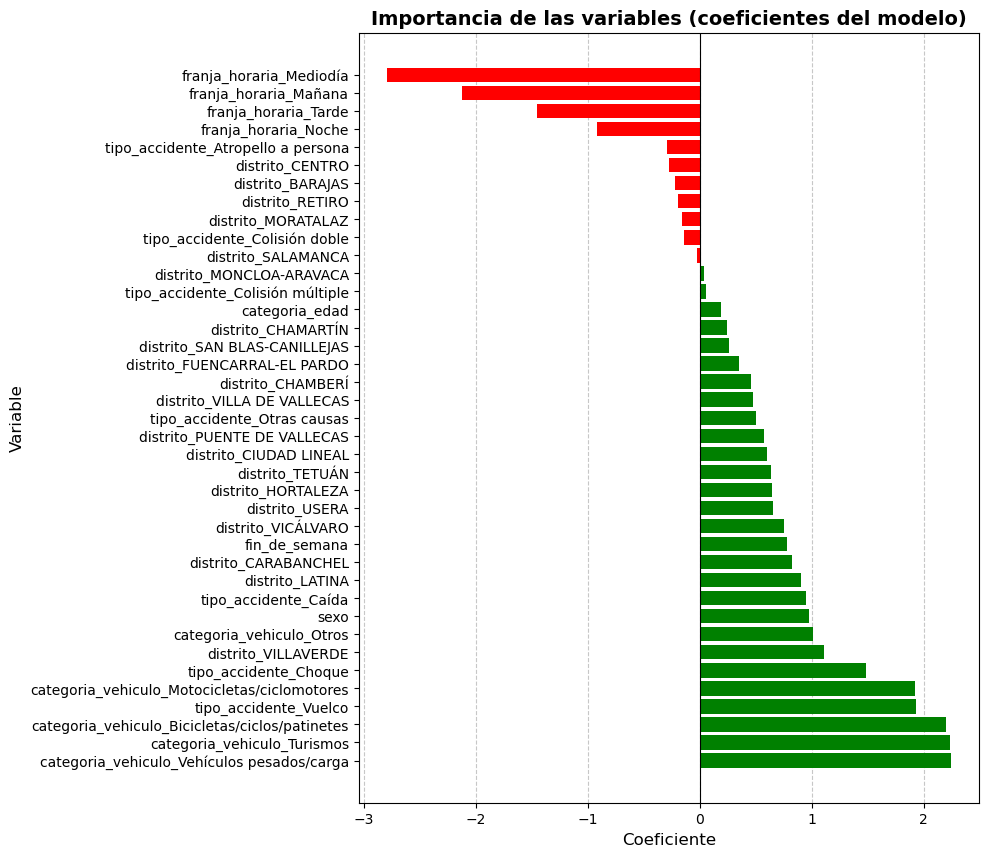

In [120]:
plt.figure(figsize=(8, 10))
# Vamos a poder los coeficientes negativos en color rojo y los positivos en color verde para distinguirlos mejor 8los asignamos con una list comprehension):
colores = ['red' if c < 0 else 'green' for c in pesos['Coeficiente']]
# Gráfico de barras horizontales donde en el eje x tenemos los coeficientes y en el eje y tenemos las variables y los colres son los establecidos en la list comprehension según si son positivos o negativos:
plt.barh(pesos['Variable'], pesos['Coeficiente'], color=colores)
# Dibujamos una línea negra divisoria en el 0 para facilitar la visualización
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title('Importancia de las variables (coeficientes del modelo)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.show()

Como podemos observar en el gráfico, los **coeficientes obtenidos son coherentes con lo observado durante nuestro análisis exploratorio**: por un lado, vemos que los coeficientes positivos más altos (es decir, los que indican una mayor relación con nuestra variable objetivo 'positiva_alcohol' se encuentran en las columnas 'categoria_vehiculo'. Recordemos que al realizar la codificación de las variables con OneHotEncoder para evitar información redundante que pudiera confundir al modelo utilizamos el argumento drop_first = True, lo que elimina una categoría de cada variable (la primera alfabéticamente) que se convierte en la categoría de referencia. Al realizar esta operación, el resto de coeficientes de las distintas etiquetas se interpretan siempre en relación a esta referencia, lo que significa en el caso de 'categoria_vehiculo' que un conductor de un turismo incrementa significativamente la probabilidad (coeficiente de 2.233080) de dar positivo en un control de alcoholemia que un conductor de autobús, si bien son los conductores de vehículos pesados/carga los que presentan un coeficiente más alto (coeficiente 2.238757). En tercer lugar se encuentran las bicicletas/ciclos/patinetes con un coeficiente de 2.198666.

Por otro lado, en relación a los tipos de accidentes, nos encontramos los coeficientes más altos en los vuelcos (1.933703) y los choques (1.480627). Curiosamente, choques y vuelcos son los tipos de accidente más frecuentes dentro de la categoría 'Desconocido' presente en las variables 'sexo' y 'categoria_edad', lo que apunta nuevamente a que esta falta de información en estos registros se corresponde con personas que se dieron a la fuga en el momento del accidente y que, probablemente, se encontraban bajo los efectos del alcohol y de ahí proceder a su fuga.

El siguiente coeficiente positivo en importancia es el de distrito_VILLAVERDE, con un 1.107077, si bien este hallazgo no tiene una explicación clara con los datos de que disponemos, ya que no se trata de un distrito con una vida nocturna de especialmente destacada, sino que concentra principalmente actividad residencial y sobre todo industrial. Si tenemos en cuenta que la categoría de vehículo con mayor probabilidad de que su conductor dé positivo en alcoholemia es la de vehículos pesados/de carga, podría ser que esta circunstancia estuviera relacionada con el alto coeficiente que presenta este distrito, al estar ubicados en el mismo varios polígonos con una alta actividad industrial y logística en el que hay una gran circulación de vehículos de estas características. Además, durante la madrugada se realizan en estas zonas labores de carga y descarga, cambios de turno, etc... Este contexto, conocido por las autoridades competentes, puede hacer que se lleven a cabo más controles en esa zona y franja horaria. La combinación de todos estos factores podría ser la causa del alto peso asignado por el modelo a la categoría 'distrito_VILLAVERDE', aunque para poder corroborar esta hipótesis necesitaríamos disponer de información adicional que no se encuentra incluida en nuestro dataset.

Confirmamos también con los coeficientes obtenidos que la variable 'sexo' tiene una correlación directa importante con nuestra variable objetivo, con un coeficiente de 0.973122,  estando en consonancia este resultado con los hallazgos realizados durante la exploración de los datos. Es interesante también destacar que, tal y como sospechábamos por los patrones conocidos de consumo de alcohol durante la semana, 'fin_de_semana' tiene un papel importante en la positividad en alcohol, siendo la probabilidad de dar positivo en alcohol significativamente mayor durante el fin de semana que en día laborable.

Por último, y con respecto a la 'franja_horaria', de forma análoga a lo ocurrido durante la codificación de 'categoria_vehiculo', OneHotEncoder eliminó la primera categoría encontrada alfabéticamente (en este caso 'Madrugada') y la convirtió en la categoría de referencia para la variable. Observamos en los resultados una fuerte correlación inversa entre positividad en alcohol y las franjas horarias 'Mediodía', con un coeficiente negativo de -2.792632 y 'Mañana' -2.122567, franjas en las que la probabilidad de positivos en alcohol es mucho más baja, lo que es coherente con lo observado anteriormente en el análisis exploratorio de los datos, donde vimos que la madrugada es la franja horaria con mayor número de positivos en alcohol. Al tener todas las demás franjas horarias coeficientes muy negativos, podemos deducir que en comparación con la madrugada, la probabilidad de resultar positivo en un control de alcoholemia cae drásticamente. Además, la madrugada no sólo resulta ser el momento de mayor riesgo de positividad en alcohol dentro de la variable franja_horaria, sino que la amplitud de sus coeficientes (2.79 entre madrugada y mediodía en total) es la mayor de todos los coeficientes del resto de variables en términos absolutos, lo que indica que 'franja_horaria' es la variable predictora de más peso en el modelo, seguida de 'categoria_vehiculo'.

Como paso final, evaluaremos nuestro modelo en el conjunto de test y mostraremos las correspondientes métricas:

Recall: 0.7422
F1-score: 0.1713


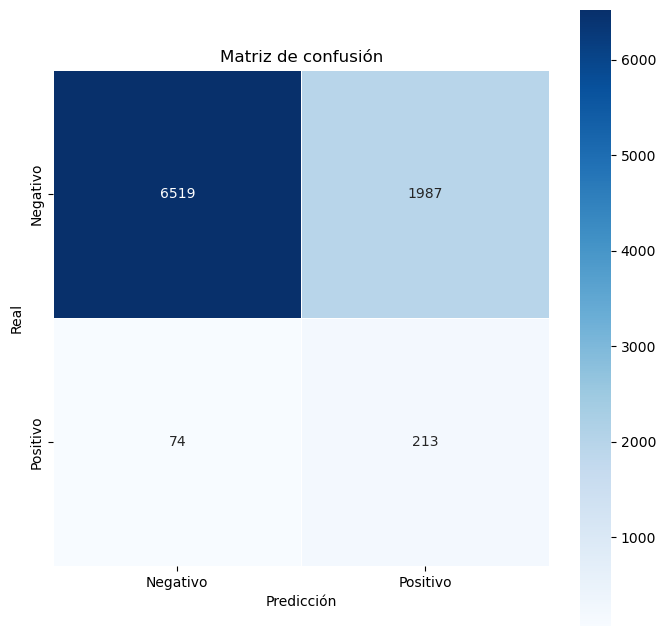

In [121]:
predicciones_test = modelo.predict(X_test)
modelo.evaluate(X_test, y_test)

Como podemos ver en las métricas obtenidas, son muy similares a las arrojadas por el modelo en el conjunto de datos de entrenamiento, lo que confirma que el modelo implementado es robusto, ya que al obtener un recall muy similar (0.7422 frente al 0.7504 obtenido para el conjunto de entrenamiento) podemos afirmar que el modelo ha aprendido patrones reales que le permiten realizar predicciones con prácticamente la misma capacidad de acierto (casi 3 de cada 4) respecto de datos que nunca había visto. Por otra parte, como el comportamiento del modelo en ambos conjuntos de datos es muy similar, podemos inferir que los coeficientes encontrados son consistentes y acordes con la realidad.

En conclusión, los resultados sugieren que la implementación de un **modelo de Regresión Logística robusto** para la detección de **positivos en alcoholemia** sería **viable**, a pesar del desequilibrio de clases existente en el dataset, con sólo un 2.93 % de los registros positivos. De los resultados obtenidos se deduce que la franja horaria es el factor más determinante en la positividad en alcohol, siendo la madrugada la de mayor riesgo de positividad al presentar todas las demás franjas coeficientes negativos respecto a ella. En segundo lugar en importancia nos encontramos con las categorías de **vehículos pesados/carga y turismos**, y los **choques y vuelcos** como tipos de accidente más relacionados con una alta positividad. Hemos podido confirmar también la relevancia de la variable 'sexo' en la positividad, resultando que ser **hombre aumenta la probabilidad de dar positivo** en un test de alcoholemia. Por último, cabe destacar la variable 'fin_de_semana' como una de las variables predictoras más relevantes para la positividad en alcohol: que el accidente se produzca durante el **fin de semana aumenta significativamente la probabilidad de que el conductor dé un resultado positivo** en el test de alcoholemia.

# _Anexo: transformaciones y exportaciones de datos para informe de Power BI_

Como complemento al EDA y modelado realizados, vamos a elaborar un informe en Power BI que muestre los resultados y conclusiones más relevantes encontrados en este notebook. Para ello, exportaremos los CSV con los dos datasets resultantes del trabajo realizado en el notebook y que se relacionarán entre sí en Power BI a través de la columna `num_expediente`: un dataset que contiene los accidentes como sucesos únicos (un accidente por fila, `powerbi_accidentes.csv`) y otro dataset que contiene los datos por persona implicada en cada accidente (una persona por fila, `powerbi_personas.csv`). Se mantienen los dos datasets en consonancia con el criterio seguido a lo largo del notebook. Como apuntábamos al comienzo del análisis univariante del EDA, en el dataset original existe un registro por cada persona implicada en cada accidente. Si no realizáramos ningún tipo de agrupación, estaríamos teniendo en cuenta personas implicadas y no accidentes, lo que introduciría un sesgo importante a la hora de analizar las variables que tienen que ver con los accidentes como sucesos únicos, como son el tipo de accidente, los distritos, la meteorología en el momento del accidente, etc. De igual manera, esta agregación por accidentes no describiría las características individuales de cada implicado (sexo, edad, tipo de vehículo o `positiva_alcohol`).

In [122]:
# Tabla de accidentes: una fila por accidente
db_accidentes.to_csv('powerbi_accidentes.csv', sep=';',
                            index=False, encoding='utf-8-sig', decimal=',')

# Tabla de personas implicadas: una fila por persona
db.to_csv('powerbi_personas.csv', sep=';',
          index=False, encoding='utf-8-sig')

print(f'Accidentes exportados: {len(db_accidentes)}')
print(f'Personas implicadas exportadas: {len(db)}')


Accidentes exportados: 20622
Personas implicadas exportadas: 48817
